In [9]:
from pathlib import Path

# This file is: retail-ai-project/notebooks/eda.ipynb
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "output" / "csv"

PROJECT_ROOT, DATA_DIR


(PosixPath('/Users/shashi/retail-ai-project'),
 PosixPath('/Users/shashi/retail-ai-project/data/raw/output/csv'))

In [10]:
sorted([p.name for p in DATA_DIR.glob("*.csv")])[:20], len(list(DATA_DIR.glob("*.csv")))

(['demand_forecasts.csv',
  'inventory_snapshots.csv',
  'products.csv',
  'promotions.csv',
  'replenishment_logs.csv',
  'sales_transactions.csv',
  'stockout_events.csv',
  'store_layout.csv',
  'stores.csv',
  'suppliers.csv'],
 10)

In [12]:
import pandas as pd

files = [
    "stores.csv",
    "products.csv",
    "suppliers.csv",
    "store_layout.csv",
    "sales_transactions.csv",
    "inventory_snapshots.csv",
    "replenishment_logs.csv",
    "stockout_events.csv",
    "promotions.csv",
    "demand_forecasts.csv",
]

dfs = {}
for f in files:
    path = DATA_DIR / f
    dfs[f] = pd.read_csv(path, low_memory=False)

{k: v.shape for k, v in dfs.items()}

{'stores.csv': (478, 10),
 'products.csv': (1265, 15),
 'suppliers.csv': (85, 9),
 'store_layout.csv': (416999, 9),
 'sales_transactions.csv': (25969106, 9),
 'inventory_snapshots.csv': (4015200, 9),
 'replenishment_logs.csv': (1366761, 12),
 'stockout_events.csv': (313599, 9),
 'promotions.csv': (5420, 9),
 'demand_forecasts.csv': (15448960, 9)}

In [13]:
import numpy as np

def basic_report(df, name):
    print(f"\n===== {name} =====")
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    print("\nDtypes:")
    display(df.dtypes.to_frame("dtype"))
    print("\nMissing % (top 15):")
    miss = (df.isna().mean().sort_values(ascending=False) * 100).round(2)
    display(miss.head(15).to_frame("missing_%"))
    print("\nDuplicate rows:", df.duplicated().sum())
    print("\nSample rows:")
    display(df.head(3))

for name, df in dfs.items():
    basic_report(df, name)


===== stores.csv =====
Shape: (478, 10)
Columns: ['store_id', 'store_name', 'region', 'city', 'state', 'store_format', 'foot_traffic_tier', 'num_aisles', 'open_date', 'sq_footage']

Dtypes:


,dtype
store_id,object
store_name,object
region,object
city,object
state,object
store_format,object
foot_traffic_tier,object
num_aisles,int64
open_date,object
sq_footage,int64



Missing % (top 15):


,missing_%
store_id,0.0
store_name,0.0
region,0.0
city,0.0
state,0.0
store_format,0.0
foot_traffic_tier,0.0
num_aisles,0.0
open_date,0.0
sq_footage,0.0



Duplicate rows: 0

Sample rows:


...

,dtype
forecast_id,object
store_id,object
sku_id,object
forecast_date,object
forecast_units,float64
forecast_method,object
created_at,object
lower_bound_90,float64
upper_bound_90,float64



Missing % (top 15):


,missing_%
forecast_id,0.0
store_id,0.0
sku_id,0.0
forecast_date,0.0
forecast_units,0.0
forecast_method,0.0
created_at,0.0
lower_bound_90,0.0
upper_bound_90,0.0



Duplicate rows: 0

Sample rows:


,forecast_id,store_id,sku_id,forecast_date,forecast_units,forecast_method,created_at,lower_bound_90,upper_bound_90
0,FC0000000001,S0001,P01049,2024-01-31,24.14,MovingAvg7,2024-01-30,18.11,30.17
1,FC0000000002,S0001,P01049,2024-01-31,22.13,MovingAvg30,2024-01-30,17.14,27.12
2,FC0000000003,S0001,P01049,2024-01-31,24.00,SeasonalNaive,2024-01-30,21.19,26.81


In [14]:
key_cols = {
    "stores.csv": "store_id",
    "products.csv": "sku_id",
    "suppliers.csv": "supplier_id",
    "store_layout.csv": "layout_id",
    "sales_transactions.csv": "transaction_id",
    "inventory_snapshots.csv": "snapshot_id",
    "replenishment_logs.csv": "replenishment_id",
    "stockout_events.csv": "stockout_id",
    "promotions.csv": "promotion_id",
    "demand_forecasts.csv": "forecast_id",
}

for table, key in key_cols.items():
    df = dfs[table]
    print(f"{table:25} key={key:20} unique={df[key].nunique():,} rows={len(df):,} nulls={df[key].isna().sum():,}")

stores.csv                key=store_id             unique=478 rows=478 nulls=0
products.csv              key=sku_id               unique=1,265 rows=1,265 nulls=0
suppliers.csv             key=supplier_id          unique=85 rows=85 nulls=0
store_layout.csv          key=layout_id            unique=416,999 rows=416,999 nulls=0
sales_transactions.csv    key=transaction_id       unique=25,969,106 rows=25,969,106 nulls=0
inventory_snapshots.csv   key=snapshot_id          unique=4,015,200 rows=4,015,200 nulls=0
replenishment_logs.csv    key=replenishment_id     unique=1,366,761 rows=1,366,761 nulls=0
stockout_events.csv       key=stockout_id          unique=313,599 rows=313,599 nulls=0
promotions.csv            key=promotion_id         unique=5,420 rows=5,420 nulls=0
demand_forecasts.csv      key=forecast_id          unique=15,448,960 rows=15,448,960 nulls=0


### unknown store id = number of rows in sales whose store_id does not exist in stores 
### unknown sku id = number of rows in sales whose sku_id does not exist in products

In [15]:
stores   = dfs["stores.csv"]
products = dfs["products.csv"]
sales    = dfs["sales_transactions.csv"]
stockouts = dfs["stockout_events.csv"]
snapshots = dfs["inventory_snapshots.csv"]
suppliers = dfs["suppliers.csv"]
promotions = dfs["promotions.csv"]
store_layout = dfs["store_layout.csv"]
transactions = dfs["sales_transactions.csv"]
replenishments = dfs["replenishment_logs.csv"]
demand_forecasts = dfs["demand_forecasts.csv"]

### Data Quality Checks

In [16]:



print("Unknown store_id in sales:", (~sales["store_id"].isin(stores["store_id"])).sum())
print("Unknown sku_id in sales:", (~sales["sku_id"].isin(products["sku_id"])).sum())


Unknown store_id in sales: 0
Unknown sku_id in sales: 0


In [17]:
# sales["sale_date"] into a datetime column and check min/max dates to understand  earliest and latest dates in the time range of our data
# errors="coerce" => if there are any invalid date formats, they will be set to NaT instead of causing an error. This allows us to identify and handle any problematic date entries without crashing the code


sales["sale_date"] = pd.to_datetime(sales["sale_date"], errors="coerce")
sales = sales.dropna(subset=["sale_date"]).copy()
print("Sales date range:", sales["sale_date"].min(), "to", sales["sale_date"].max())

Sales date range: 2024-01-01 00:00:00 to 2025-12-31 00:00:00


In [11]:
# sold X units at price P => revenue should be X*P
# compare it with provided revenue column to check for any discrepancies or data quality issues

sales["calc_revenue"] = sales["units_sold"] * sales["unit_price_actual"]
diff = (sales["revenue"] - sales["calc_revenue"]).abs()

diff.describe()

count    2.596911e+07
mean     8.699248e-15
std      2.716835e-14
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      9.094947e-13
dtype: float64

Validated revenue integrity (Revenue = Units × Price) across 26M rows — no discrepancies found, ensuring high-quality input for forecasting models.

In [ ]:
from pathlib import Path

# This file is: retail-ai-project/notebooks/eda.ipynb
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "output" / "csv"

PROJECT_ROOT, DATA_DIR


(PosixPath('/Users/shashi/retail-ai-project'),
 PosixPath('/Users/shashi/retail-ai-project/data/raw/output/csv'))

In [ ]:
sorted([p.name for p in DATA_DIR.glob("*.csv")])[:20], len(list(DATA_DIR.glob("*.csv")))

(['demand_forecasts.csv',
  'inventory_snapshots.csv',
  'products.csv',
  'promotions.csv',
  'replenishment_logs.csv',
  'sales_transactions.csv',
  'stockout_events.csv',
  'store_layout.csv',
  'stores.csv',
  'suppliers.csv'],
 10)

In [ ]:
import pandas as pd

files = [
    "stores.csv",
    "products.csv",
    "suppliers.csv",
    "store_layout.csv",
    "sales_transactions.csv",
    "inventory_snapshots.csv",
    "replenishment_logs.csv",
    "stockout_events.csv",
    "promotions.csv",
    "demand_forecasts.csv",
]

dfs = {}
for f in files:
    path = DATA_DIR / f
    dfs[f] = pd.read_csv(path, low_memory=False)

{k: v.shape for k, v in dfs.items()}

{'stores.csv': (478, 10),
 'products.csv': (1265, 15),
 'suppliers.csv': (85, 9),
 'store_layout.csv': (416999, 9),
 'sales_transactions.csv': (25969106, 9),
 'inventory_snapshots.csv': (4015200, 9),
 'replenishment_logs.csv': (1366761, 12),
 'stockout_events.csv': (313599, 9),
 'promotions.csv': (5420, 9),
 'demand_forecasts.csv': (15448960, 9)}

In [ ]:
import numpy as np

def basic_report(df, name):
    print(f"\n===== {name} =====")
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    print("\nDtypes:")
    display(df.dtypes.to_frame("dtype"))
    print("\nMissing % (top 15):")
    miss = (df.isna().mean().sort_values(ascending=False) * 100).round(2)
    display(miss.head(15).to_frame("missing_%"))
    print("\nDuplicate rows:", df.duplicated().sum())
    print("\nSample rows:")
    display(df.head(3))

for name, df in dfs.items():
    basic_report(df, name)


===== stores.csv =====
Shape: (478, 10)
Columns: ['store_id', 'store_name', 'region', 'city', 'state', 'store_format', 'foot_traffic_tier', 'num_aisles', 'open_date', 'sq_footage']

Dtypes:


,dtype
store_id,object
store_name,object
region,object
city,object
state,object
store_format,object
foot_traffic_tier,object
num_aisles,int64
open_date,object
sq_footage,int64



Missing % (top 15):


,missing_%
store_id,0.0
store_name,0.0
region,0.0
city,0.0
state,0.0
store_format,0.0
foot_traffic_tier,0.0
num_aisles,0.0
open_date,0.0
sq_footage,0.0



Duplicate rows: 0

Sample rows:


...

,dtype
forecast_id,object
store_id,object
sku_id,object
forecast_date,object
forecast_units,float64
forecast_method,object
created_at,object
lower_bound_90,float64
upper_bound_90,float64



Missing % (top 15):


,missing_%
forecast_id,0.0
store_id,0.0
sku_id,0.0
forecast_date,0.0
forecast_units,0.0
forecast_method,0.0
created_at,0.0
lower_bound_90,0.0
upper_bound_90,0.0



Duplicate rows: 0

Sample rows:


,forecast_id,store_id,sku_id,forecast_date,forecast_units,forecast_method,created_at,lower_bound_90,upper_bound_90
0,FC0000000001,S0001,P01049,2024-01-31,24.14,MovingAvg7,2024-01-30,18.11,30.17
1,FC0000000002,S0001,P01049,2024-01-31,22.13,MovingAvg30,2024-01-30,17.14,27.12
2,FC0000000003,S0001,P01049,2024-01-31,24.00,SeasonalNaive,2024-01-30,21.19,26.81


In [ ]:
key_cols = {
    "stores.csv": "store_id",
    "products.csv": "sku_id",
    "suppliers.csv": "supplier_id",
    "store_layout.csv": "layout_id",
    "sales_transactions.csv": "transaction_id",
    "inventory_snapshots.csv": "snapshot_id",
    "replenishment_logs.csv": "replenishment_id",
    "stockout_events.csv": "stockout_id",
    "promotions.csv": "promotion_id",
    "demand_forecasts.csv": "forecast_id",
}

for table, key in key_cols.items():
    df = dfs[table]
    print(f"{table:25} key={key:20} unique={df[key].nunique():,} rows={len(df):,} nulls={df[key].isna().sum():,}")

stores.csv                key=store_id             unique=478 rows=478 nulls=0
products.csv              key=sku_id               unique=1,265 rows=1,265 nulls=0
suppliers.csv             key=supplier_id          unique=85 rows=85 nulls=0
store_layout.csv          key=layout_id            unique=416,999 rows=416,999 nulls=0
sales_transactions.csv    key=transaction_id       unique=25,969,106 rows=25,969,106 nulls=0
inventory_snapshots.csv   key=snapshot_id          unique=4,015,200 rows=4,015,200 nulls=0
replenishment_logs.csv    key=replenishment_id     unique=1,366,761 rows=1,366,761 nulls=0
stockout_events.csv       key=stockout_id          unique=313,599 rows=313,599 nulls=0
promotions.csv            key=promotion_id         unique=5,420 rows=5,420 nulls=0
demand_forecasts.csv      key=forecast_id          unique=15,448,960 rows=15,448,960 nulls=0


### unknown store id = number of rows in sales whose store_id does not exist in stores 
### unknown sku id = number of rows in sales whose sku_id does not exist in products

In [ ]:
stores   = dfs["stores.csv"]
products = dfs["products.csv"]
sales    = dfs["sales_transactions.csv"]
stockouts = dfs["stockout_events.csv"]
snapshots = dfs["inventory_snapshots.csv"]
suppliers = dfs["suppliers.csv"]
promotions = dfs["promotions.csv"]
store_layout = dfs["store_layout.csv"]
transactions = dfs["sales_transactions.csv"]
replenishments = dfs["replenishment_logs.csv"]
demand_forecasts = dfs["demand_forecasts.csv"]

### Data Quality Checks

In [ ]:



print("Unknown store_id in sales:", (~sales["store_id"].isin(stores["store_id"])).sum())
print("Unknown sku_id in sales:", (~sales["sku_id"].isin(products["sku_id"])).sum())


Unknown store_id in sales: 0
Unknown sku_id in sales: 0


In [ ]:
# sales["sale_date"] into a datetime column and check min/max dates to understand  earliest and latest dates in the time range of our data
# errors="coerce" => if there are any invalid date formats, they will be set to NaT instead of causing an error. This allows us to identify and handle any problematic date entries without crashing the code


sales["sale_date"] = pd.to_datetime(sales["sale_date"], errors="coerce")
sales = sales.dropna(subset=["sale_date"]).copy()
print("Sales date range:", sales["sale_date"].min(), "to", sales["sale_date"].max())

Sales date range: 2024-01-01 00:00:00 to 2025-12-31 00:00:00


In [ ]:
# sold X units at price P => revenue should be X*P
# compare it with provided revenue column to check for any discrepancies or data quality issues

sales["calc_revenue"] = sales["units_sold"] * sales["unit_price_actual"]
diff = (sales["revenue"] - sales["calc_revenue"]).abs()

diff.describe()

count    2.596911e+07
mean     8.699248e-15
std      2.716835e-14
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      9.094947e-13
dtype: float64

The revenue column is perfectly consistent with units_sold × unit_price

Validated revenue column (Revenue = Units × Price) across 26M rows — no discrepancies found, ensuring high-quality input for forecasting models

In [ ]:
stockouts["stockout_date"] = pd.to_datetime(stockouts["stockout_date"], errors="coerce")
stockouts["restock_date"] = pd.to_datetime(stockouts["restock_date"], errors="coerce")

print("Total stockout events:", len(stockouts))
print("Avg duration days:", round(stockouts["duration_days"].mean(), 2))
stockouts["root_cause"].value_counts().head(10)

Total stockout events: 313599
Avg duration days: 4.46


root_cause
Manual error      62555
Supplier delay    62287
Forecast miss     62148
Demand spike      62112
Shrinkage         61815
Ongoing            2682
Name: count, dtype: int64

### stockout with root cause reason calculated from given data, duration_days = restock_date - stockout_date, Avg duration = sum of all durations / number of events = 5 days : When a product goes out of stock, it takes 5 days to recover

### why Products that stay out of stock for extended periods, what ongoing mean, to understand the long terms stockouts 

### Are they related? forecast misses demand spikes? they are related

### 40% of stockouts are forecast-related (Forecast miss + Demand spike)
  ### 60% of stockouts are non-forecast (Supplier, manual error, shrinkage)

 ## Categories that makes the revenue 

In [ ]:
sales = dfs["sales_transactions.csv"].copy()
products = dfs["products.csv"].copy()

sales["sale_date"] = pd.to_datetime(sales["sale_date"])
cat_rev = sales.merge(products[["sku_id","category"]], on="sku_id", how="left") \
               .groupby("category")["revenue"].sum().sort_values(ascending=False)

cat_rev.head(10)

category
Beverages          8.103012e+08
Snacks             6.923246e+08
Dairy & Eggs       6.527632e+08
Frozen Foods       5.928694e+08
Personal Care      5.918657e+08
Bakery             5.167487e+08
Meat & Seafood     5.059952e+08
Household          4.901255e+08
Canned & Pantry    4.597365e+08
Produce            4.528208e+08
Name: revenue, dtype: float64

# How many sales rows are promoted

In [ ]:
sales["is_promoted"].value_counts(normalize=True)

is_promoted
False    0.979031
True     0.020969
Name: proportion, dtype: float64

# Which suppliers have the longest lead time

In [ ]:
suppliers = dfs["suppliers.csv"]
suppliers.sort_values("lead_time_days_avg", ascending=False).head(10)

,supplier_id,supplier_name,country,lead_time_days_avg,lead_time_days_std,reliability_score,min_order_qty,contract_start,payment_terms_days
57,SUP058,FuelForward Distributors,Australia,20,1.0,0.872,58,2020-02-24,15
22,SUP023,WestCoast Distributors,Brazil,20,7.3,0.903,231,2019-08-06,60
80,SUP081,CaprockTrading Co.,Mexico,19,1.4,0.734,362,2018-07-12,45
52,SUP053,ArcticFresh Foods,Mexico,19,6.2,0.836,319,2022-09-17,90
50,SUP051,Yeomanry Supply,South Korea,19,0.7,0.861,79,2021-10-21,90
74,SUP075,WillowCreek Trading,France,18,1.4,0.878,320,2018-07-28,60
40,SUP041,OpenRoad Wholesale,Australia,18,6.5,0.850,237,2019-11-24,15
43,SUP044,RiverBend Supply,Australia,18,1.7,0.874,81,2022-04-28,90
62,SUP063,KingsCross Wholesale,UK,18,0.8,0.753,445,2019-06-03,30
82,SUP083,EmeraldCoast Supply,UK,18,5.6,0.778,398,2020-03-09,45


# Do promotions increase sales

In [ ]:
sales = dfs["sales_transactions.csv"].copy()
sales.groupby("is_promoted")["units_sold"].mean()

is_promoted
False    10.169224
True     18.909073
Name: units_sold, dtype: float64

#  Premium stores sell more leads to demand spikes 

In [ ]:
stores = dfs["stores.csv"][["store_id","foot_traffic_tier"]]
sales  = dfs["sales_transactions.csv"][["store_id","units_sold","revenue"]]

tmp = sales.merge(stores, on="store_id", how="left")

tier_sales = (
    tmp.groupby("foot_traffic_tier")[["units_sold","revenue"]]
       .mean()
       .reset_index()
)

tier_salesstores = dfs["stores.csv"][["store_id","foot_traffic_tier"]]
sales  = dfs["sales_transactions.csv"][["store_id","units_sold","revenue"]]

tmp = sales.merge(stores, on="store_id", how="left")

tier_sales = (
    tmp.groupby("foot_traffic_tier")[["units_sold","revenue"]]
       .mean()
       .reset_index()
)

tier_sales

,foot_traffic_tier,units_sold,revenue
0,High,12.157829,301.323877
1,Low,5.310694,131.943708
2,Medium,8.431910,210.520065
3,Premium,15.945868,397.697773


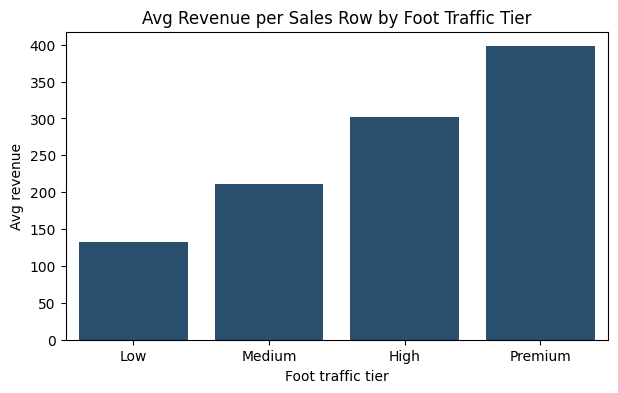

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



tier_sales_plot = tier_sales.reset_index()

plt.figure(figsize=(7,4))
sns.barplot(data=tier_sales_plot, x="foot_traffic_tier", y="revenue", color="#1F4E79",
            order=["Low","Medium","High","Premium"])
plt.title("Avg Revenue per Sales Row by Foot Traffic Tier")
plt.xlabel("Foot traffic tier")
plt.ylabel("Avg revenue")
plt.show()

<h2 style="color:#2E86C1;">


### 1. avg_units_nonpromo: daily units sold when not promoted
### 2. avg_units_promo: daily units sold when promoted
### 3. lift_pct: percent increase because of promotion
### 4. lift_abs = avg_units_promo − avg_units_nonpromo (extra units because of promotion)
### 5. lift_pct = percent increase = ((promo/nonpromo) - 1) * 100
### 6. The top categories here are the ones where promotions create the biggest variation ie; higher stockout risk
### largest promotion lifts are around 80–91% across categories.


</h2>

### Promotion lift by category 

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [ ]:
import pandas as pd
import numpy as np

sales = dfs["sales_transactions.csv"][["store_id","sku_id","sale_date","units_sold","revenue","is_promoted"]].copy()
products = dfs["products.csv"][["sku_id","category"]].copy()

sales["sale_date"] = pd.to_datetime(sales["sale_date"], errors="coerce")

# add category to each sales row
s = sales.merge(products, on="sku_id", how="left")

# add  units sold on promo vs non-promo per category
cat_promo = (
    s.groupby(["category","is_promoted"])["units_sold"]
     .mean()
     .unstack("is_promoted")
     .rename(columns={False:"avg_units_nonpromo", True:"avg_units_promo"})
)

cat_promo["lift_abs"] = cat_promo["avg_units_promo"] - cat_promo["avg_units_nonpromo"]
cat_promo["lift_pct"] = (cat_promo["avg_units_promo"] / cat_promo["avg_units_nonpromo"] - 1) * 100

cat_promo.sort_values("lift_pct", ascending=False).head(15)

is_promoted,avg_units_nonpromo,avg_units_promo,lift_abs,lift_pct
category,,,,
Canned & Pantry,10.098490,19.262409,9.163919,90.745437
Beverages,10.095064,19.142325,9.047261,89.620638
Baby & Infant,10.472972,19.777684,9.304712,88.845002
Snacks,10.161651,19.126544,8.964893,88.222804
Dairy & Eggs,10.127489,18.865643,8.738154,86.281548
Health & Wellness,10.030329,18.683931,8.653602,86.274357
Household,10.022632,18.592709,8.570077,85.507246
Produce,10.312656,19.120577,8.807921,85.408852
Bakery,9.976330,18.439242,8.462912,84.829906


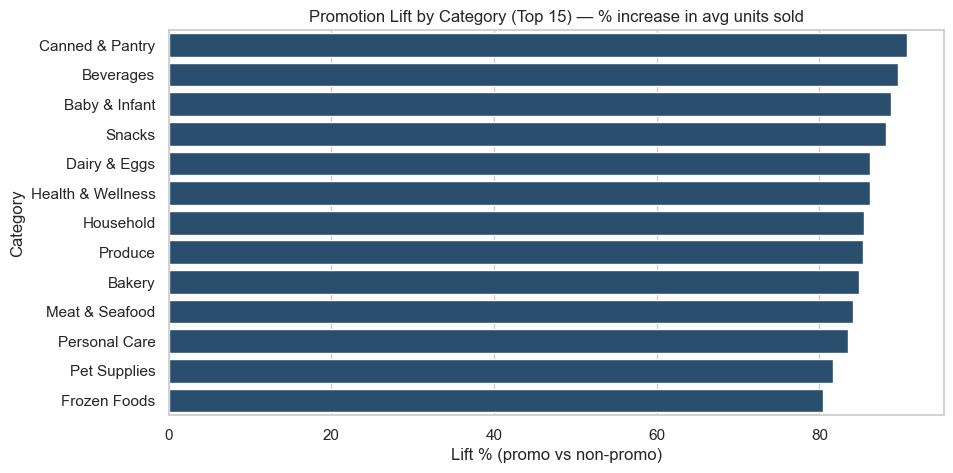

In [ ]:
promo_plot = cat_promo.dropna().sort_values("lift_pct", ascending=False).head(15).reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=promo_plot, x="lift_pct", y="category", color="#1F4E79")
plt.title("Promotion Lift by Category (Top 15) — % increase in avg units sold")
plt.xlabel("Lift % (promo vs non-promo)")
plt.ylabel("Category")
plt.show()

avg_units_nonpromo = average units sold when no promotion
avg_units_promo = average units sold during promotion
lift_abs = extra units sold because of promotion
lift_pct = % increase because of promotion

Non-promo: 10.10
Promo: 19.26
Difference: +9.16 units
Lift %: +90.75%
# promotions almost double sales in this category, when promotion is active, demand becomes about 1.8x to 1.9x normal

In [ ]:
stockouts_raw = dfs["stockout_events.csv"].copy()

for c in ["stockout_date","restock_date"]:
    if c in stockouts_raw.columns:
        stockouts_raw[c] = pd.to_datetime(stockouts_raw[c], errors="coerce")

stockouts_raw.columns, stockouts_raw.head()

(Index(['stockout_id', 'store_id', 'sku_id', 'stockout_date', 'restock_date',
        'duration_days', 'estimated_lost_units', 'estimated_lost_revenue',
        'root_cause'],
       dtype='object'),
             stockout_id store_id  sku_id stockout_date restock_date  \
 0  SO-S0001-P01023-0001    S0001  P01023    2024-01-15   2024-01-17   
 1  SO-S0001-P01023-0002    S0001  P01023    2024-03-10   2024-03-17   
 2  SO-S0001-P01023-0003    S0001  P01023    2024-04-12   2024-04-15   
 3  SO-S0001-P01023-0004    S0001  P01023    2024-05-12   2024-05-17   
 4  SO-S0001-P01023-0005    S0001  P01023    2024-06-08   2024-06-18   
 
    duration_days  estimated_lost_units  estimated_lost_revenue      root_cause  
 0              2                    11                  254.21    Demand spike  
 1              7                    51                 1178.61    Manual error  
 2              3                    28                  647.08       Shrinkage  
 3              5                    4

In [ ]:
import pandas as pd

print("stores columns:", stores.columns.tolist())

needed_store_cols = ["store_id", "foot_traffic_tier", "region", "store_format"]
available_store_cols = [c for c in needed_store_cols if c in stores.columns]

stores_small = stores[available_store_cols].copy()

products_small = products.copy()
if "sku_id" not in products_small.columns and "assigned_sku_id" in products_small.columns:
    products_small = products_small.rename(columns={"assigned_sku_id": "sku_id"})

so_store = (
    stockouts_raw
    .merge(stores_small, on="store_id", how="left")
    .merge(products_small, on="sku_id", how="left")
)

agg_dict = {
    "stockout_events": ("stockout_id", "count"),
    "lost_revenue": ("estimated_lost_revenue", "sum")
}

if "estimated_lost_units" in so_store.columns:
    agg_dict["lost_units"] = ("estimated_lost_units", "sum")

if "duration_days" in so_store.columns:
    agg_dict["avg_duration"] = ("duration_days", "mean")

group_col = "foot_traffic_tier" if "foot_traffic_tier" in so_store.columns else "store_id"

tier_summary = (
    so_store.groupby(group_col)
            .agg(**agg_dict)
            .sort_values("lost_revenue", ascending=False)
)

print(tier_summary)

stores columns: ['store_id', 'foot_traffic_tier']
                   stockout_events  lost_revenue  lost_units  avg_duration
foot_traffic_tier                                                         
Premium                     130251  2.558294e+08    10379021      4.721868
High                         78327  1.186145e+08     4653004      4.609751
Medium                       63027  6.194188e+07     2421446      4.128929
Low                          41994  2.356890e+07      963192      3.884674


In [ ]:
cat_stockouts = (
    so_store.groupby("category")
            .agg(
                stockout_events=("stockout_id","count"),
                lost_revenue=("estimated_lost_revenue","sum"),
                lost_units=("estimated_lost_units","sum"),
                avg_duration=("duration_days","mean"),
            )
            .sort_values("lost_revenue", ascending=False)
)

cat_stockouts.head(15)

,stockout_events,lost_revenue,lost_units,avg_duration
category,,,,
Beverages,37026,54146182.92,2162372,4.562686
Bakery,30964,48068589.28,1839960,4.920295
Dairy & Eggs,29013,46883896.41,1720328,4.556785
Snacks,29947,43755161.85,1900526,4.888303
Frozen Foods,31583,39629417.26,1702661,4.083083
Meat & Seafood,21889,38548089.61,1438548,4.993102
Household,24594,36232906.94,1351152,4.216354
Personal Care,22272,34044403.48,1331981,4.060794
Canned & Pantry,21753,32793342.10,1189016,4.378660


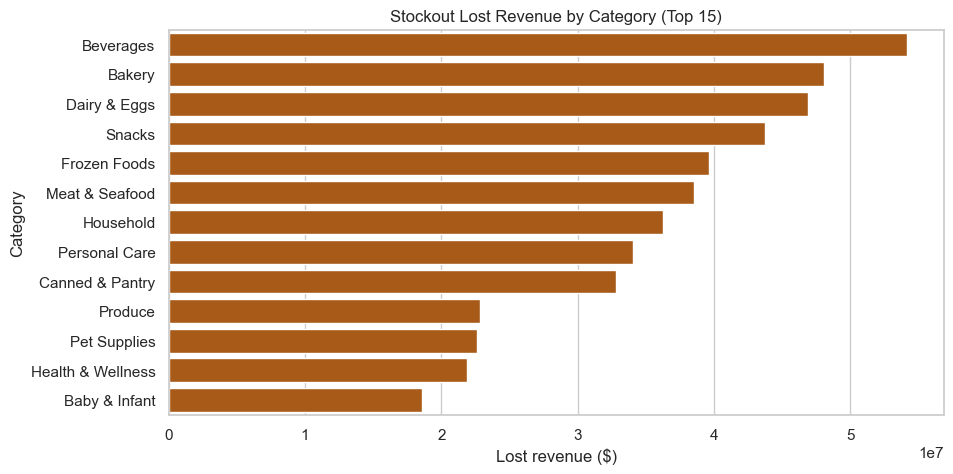

In [ ]:
cat_plot = cat_stockouts.head(15).reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=cat_plot, x="lost_revenue", y="category", color="#C05A00")
plt.title("Stockout Lost Revenue by Category (Top 15)")
plt.xlabel("Lost revenue ($)")
plt.ylabel("Category")
plt.show()

stockout_events: count of stockouts in that category
lost_revenue: money lost from stockouts
lost_units: units lost
avg_duration: average stockout duration in days
Beverages has the highest lost revenue and highest stockout count and top problem category

In [ ]:
store_stockouts = (
    so_store.groupby("store_id")
            .agg(
                stockout_events=("stockout_id","count"),
                lost_revenue=("estimated_lost_revenue","sum"),
                lost_units=("estimated_lost_units","sum"),
            )
            .sort_values("lost_revenue", ascending=False)
)

store_stockouts.head(15)

,stockout_events,lost_revenue,lost_units
store_id,,,
S0029,1152,3259250.08,112349
S0430,1342,3251926.96,114162
S0182,1014,3120355.66,97757
S0073,1293,3001297.16,114670
S0085,1223,2999191.80,97891
S0305,1157,2899547.20,104213
S0026,1068,2894318.82,110985
S0155,1300,2837670.24,105031
S0064,1535,2836217.59,114183


 stockout_events: how many stockouts happened in that store
 lost_revenue: total lost revenue in that store from stockouts
 lost_units: total lost units in that store

In [ ]:
root_cause_summary = (
    stockouts.groupby("root_cause")
             .agg(
                 events=("stockout_id","count"),
                 lost_revenue=("estimated_lost_revenue","sum"),
                 lost_units=("estimated_lost_units","sum"),
                 avg_duration=("duration_days","mean"),
             )
)

# add % share
root_cause_summary["event_share_%"] = (root_cause_summary["events"] / root_cause_summary["events"].sum()) * 100
root_cause_summary["lost_rev_share_%"] = (root_cause_summary["lost_revenue"] / root_cause_summary["lost_revenue"].sum()) * 100

root_cause_summary.sort_values("lost_revenue", ascending=False)

,events,lost_revenue,lost_units,avg_duration,event_share_%,lost_rev_share_%
root_cause,,,,,,
Demand spike,62112,88366405.55,3514247,4.346406,19.806186,19.211982
Supplier delay,62287,87362195.64,3479489,4.286561,19.861989,18.993654
Manual error,62555,86276502.26,3458510,4.275118,19.947449,18.757610
Shrinkage,61815,85969760.25,3424399,4.259921,19.711479,18.690921
Forecast miss,62148,85798666.96,3428180,4.253138,19.817665,18.653723
Ongoing,2682,26181129.13,1111838,25.138330,0.855232,5.692111


events: number of stockout events due to this cause
lost_revenue: revenue lost due to this cause
lost_units: units lost
avg_duration: how long these stockouts last on average days
event_share_%: % of all stockout events
lost_rev_share_%: % of all lost revenue

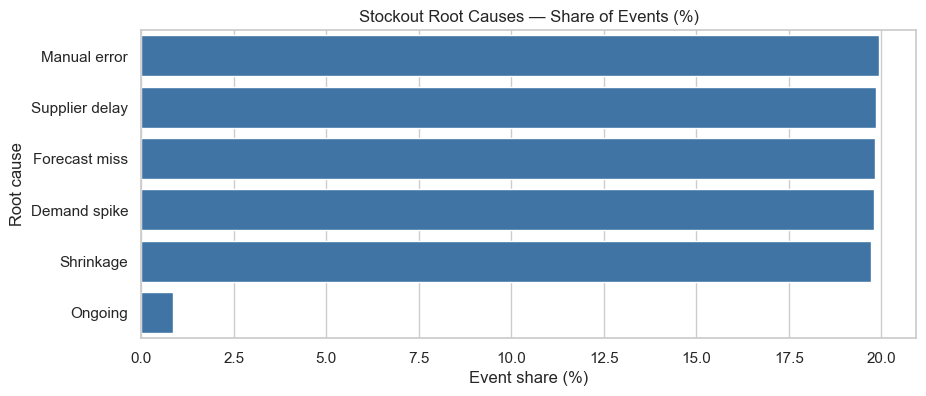

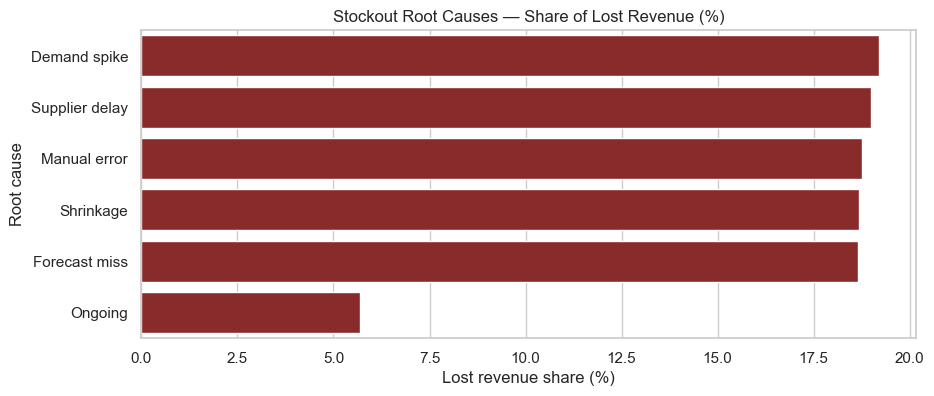

In [ ]:
rc = root_cause_summary.reset_index().copy()

# Events share
plt.figure(figsize=(10,4))
sns.barplot(data=rc.sort_values("event_share_%", ascending=False),
            x="event_share_%", y="root_cause", color="#2E75B6")
plt.title("Stockout Root Causes — Share of Events (%)")
plt.xlabel("Event share (%)")
plt.ylabel("Root cause")
plt.show()

# Lost revenue share
plt.figure(figsize=(10,4))
sns.barplot(data=rc.sort_values("lost_rev_share_%", ascending=False),
            x="lost_rev_share_%", y="root_cause", color="#991B1B")
plt.title("Stockout Root Causes — Share of Lost Revenue (%)")
plt.xlabel("Lost revenue share (%)")
plt.ylabel("Root cause")
plt.show()

the major causes are deliberately balanced (19–20% each)
 Ongoing” is rare but lasts very long (avg_duration ~25 days) and it can also cause noticeable revenue loss 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

stores = dfs["stores.csv"].copy()
products = dfs["products.csv"].copy()
suppliers = dfs["suppliers.csv"].copy()
layout = dfs["store_layout.csv"].copy()
sales = dfs["sales_transactions.csv"].copy()
inv = dfs["inventory_snapshots.csv"].copy()
repl = dfs["replenishment_logs.csv"].copy()
stock = dfs["stockout_events.csv"].copy()
promos = dfs["promotions.csv"].copy()
fcst = dfs["demand_forecasts.csv"].copy()

# parse dates
sales["sale_date"] = pd.to_datetime(sales["sale_date"])
inv["snapshot_date"] = pd.to_datetime(inv["snapshot_date"])
repl["replenishment_date"] = pd.to_datetime(repl["replenishment_date"])
repl["order_date"] = pd.to_datetime(repl["order_date"])
repl["receive_date"] = pd.to_datetime(repl["receive_date"])
stock["stockout_date"] = pd.to_datetime(stock["stockout_date"])
stock["restock_date"] = pd.to_datetime(stock["restock_date"], errors="coerce")
promos["start_date"] = pd.to_datetime(promos["start_date"])
promos["end_date"] = pd.to_datetime(promos["end_date"])
fcst["forecast_date"] = pd.to_datetime(fcst["forecast_date"])
fcst["created_at"] = pd.to_datetime(fcst["created_at"])

### Total revenue per store + lost_revenue_rate


In [ ]:
sales_store = sales.groupby("store_id").agg(
    total_revenue=("revenue","sum"),
    total_units=("units_sold","sum"),
    sales_days=("sale_date","nunique")
)

stock_store = stock.groupby("store_id").agg(
    stockout_events=("stockout_id","count"),
    lost_revenue=("estimated_lost_revenue","sum"),
    lost_units=("estimated_lost_units","sum"),
)

store_rates = sales_store.join(stock_store, how="left").fillna(0)
store_rates["lost_revenue_rate"] = store_rates["lost_revenue"] / store_rates["total_revenue"].replace(0, np.nan)
store_rates["lost_units_rate"] = store_rates["lost_units"] / store_rates["total_units"].replace(0, np.nan)

store_rates.sort_values("lost_revenue_rate", ascending=False).head(15)

,total_revenue,total_units,sales_days,stockout_events,lost_revenue,lost_units,lost_revenue_rate,lost_units_rate
store_id,,,,,,,,
S0430,20097818.49,941407,731,1342,3251926.96,114162,0.161805,0.121267
S0029,20643782.47,798723,731,1152,3259250.08,112349,0.157880,0.140661
S0182,21431806.97,846090,731,1014,3120355.66,97757,0.145595,0.115540
S0180,19076728.52,808269,731,1484,2767371.98,120629,0.145065,0.149244
S0080,18819710.81,806438,731,1104,2535929.82,84246,0.134749,0.104467
S0446,21199869.51,826296,731,1096,2794991.85,97140,0.131840,0.117561
S0073,23034445.76,841983,731,1293,3001297.16,114670,0.130296,0.136190
S0101,19664875.37,881332,731,1035,2504275.30,93916,0.127348,0.106561
S0106,14829613.91,615927,731,1257,1864511.91,64991,0.125729,0.105517


total_revenue: total sales revenue for the store across the dataset period
total_units: total units sold in that store
sales_days: number of unique days with sales records 
stockout_events: count of stockout events recorded in stockout_events.csv
lost_revenue: total estimated revenue lost due to stockouts
lost_units: total estimated units lost due to stockouts
lost_revenue_rate = lost_revenue / total_revenue
 S0430 = 0.1618 = 16.18% of revenue was lost due to stockouts
lost_units_rate = lost_units / total_units
S0029 = 0.1407 = 14.07% of units demand couldn’t be served

### higher-traffic stores lose a higher fraction of revenue due to stockouts

### Lost_revenue_rate = lost_revenue / total_revenue at the store level and joined store metadata (foot_traffic_tier)

### from graph, low traffic stores have the smallest lost revenue rate & premium traffic stores have the largest this will help us for stockout risk modeling and prioritization (which stores to improve first)

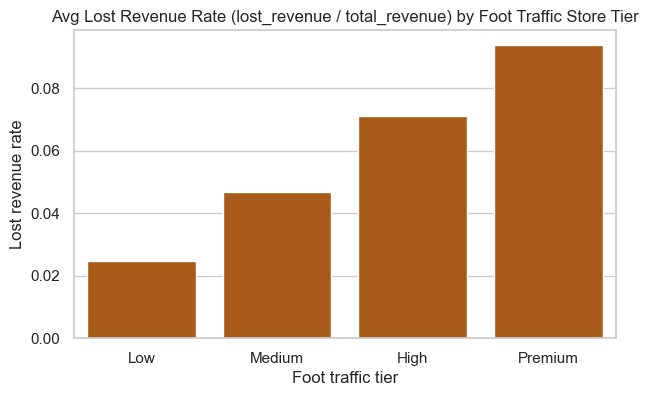

In [ ]:
store_rates2 = store_rates.reset_index().merge(stores[["store_id","foot_traffic_tier"]], on="store_id", how="left")

tier_rate = store_rates2.groupby("foot_traffic_tier")["lost_revenue_rate"].mean().reindex(["Low","Medium","High","Premium"])

plt.figure(figsize=(7,4))
sns.barplot(x=tier_rate.index, y=tier_rate.values, color="#C05A00")
plt.title("Avg Lost Revenue Rate (lost_revenue / total_revenue) by Foot Traffic Store Tier")
plt.xlabel("Foot traffic tier")
plt.ylabel("Lost revenue rate")
plt.show()

### SKU-stockout-days per store (computing store level stockout rate)
### stores with the most stockout-days



total_revenue: sum of sales.revenue for that store (across all SKUs/days).
total_units: sum of sales.units_sold for that store.
sales_days: number of unique sale dates in the store’s sales table 
stockout_events: number of stockout events (rows) in stockout_events for that store
lost_revenue: sum of stockout_events.estimated_lost_revenue for that store
lost_units: sum of stockout_events.estimated_lost_units for that store
lost_revenue_rate = lost_revenue / total_revenue
lost_units_rate = lost_units / total_units
stockout_days: sum(duration_days) across all stockout events for that store
stockout_rate = average SKU stockouts per day / TOTAL_DAYS (10x of days are stockout)

In [ ]:
stock_days_store = stock.groupby("store_id")["duration_days"].sum().rename("stockout_days")

store_rates = store_rates.join(stock_days_store, how="left").fillna({"stockout_days":0})

# total days in dataset coverage (from dashboard: 730 days)
TOTAL_DAYS = 730
store_rates["stockout_rate"] = store_rates["stockout_days"] / TOTAL_DAYS

store_rates.sort_values("stockout_rate", ascending=False).head(15)

,total_revenue,total_units,sales_days,stockout_events,lost_revenue,lost_units,lost_revenue_rate,lost_units_rate,stockout_days,stockout_rate
store_id,,,,,,,,,,
S0180,19076728.52,808269,731,1484,2767371.98,120629,0.145065,0.149244,7863,10.771233
S0347,24125085.66,989830,731,1089,2696777.34,127859,0.111783,0.129173,7145,9.787671
S0169,22275662.64,926755,731,1454,2791706.50,112035,0.125325,0.120890,6885,9.431507
S0277,22747186.50,875371,731,860,2707329.87,107973,0.119018,0.123345,6842,9.372603
S0384,23727687.87,932823,731,1005,2301467.10,98624,0.096995,0.105726,6760,9.260274
S0305,23092003.00,935469,731,1157,2899547.20,104213,0.125565,0.111402,6723,9.209589
S0430,20097818.49,941407,731,1342,3251926.96,114162,0.161805,0.121267,6605,9.047945
S0029,20643782.47,798723,731,1152,3259250.08,112349,0.157880,0.140661,6564,8.991781
S0035,18963065.80,853372,731,1139,1718680.83,95909,0.090633,0.112388,6554,8.978082


###  Promo lift by store foot-traffic tier >> how much promotions increase demand does it differ by store foot-traffic tier

avg_units_nonpromo: mean(units_sold) for records where is_promoted == False
avg_units_promo: mean(units_sold) for records where is_promoted == True
lift_abs: difference between promo and nonpromo averages
lift_pct: percent change from nonpromo to promo
stores.foot_traffic_tier: Low/Medium/High/Premium segmentation
is_promoted: boolean indicating the SKU was promoted on that day (from sales_transactions.is_promoted)
units_sold: units sold for that record store×sku×day


In [ ]:
sales2 = sales.merge(stores[["store_id","foot_traffic_tier"]], on="store_id", how="left")

tier_promo = (
    sales2.groupby(["foot_traffic_tier","is_promoted"])["units_sold"]
          .mean()
          .unstack("is_promoted")
          .rename(columns={False:"avg_units_nonpromo", True:"avg_units_promo"})
          .reindex(["Low","Medium","High","Premium"])
)

tier_promo["lift_abs"] = tier_promo["avg_units_promo"] - tier_promo["avg_units_nonpromo"]
tier_promo["lift_pct"] = (tier_promo["avg_units_promo"] / tier_promo["avg_units_nonpromo"] - 1) * 100

tier_promo

is_promoted,avg_units_nonpromo,avg_units_promo,lift_abs,lift_pct
foot_traffic_tier,,,,
Low,5.212018,9.743076,4.531057,86.934789
Medium,8.275965,15.729608,7.453643,90.063728
High,11.937273,22.661674,10.724400,89.839613
Premium,15.671401,29.067230,13.395829,85.479464


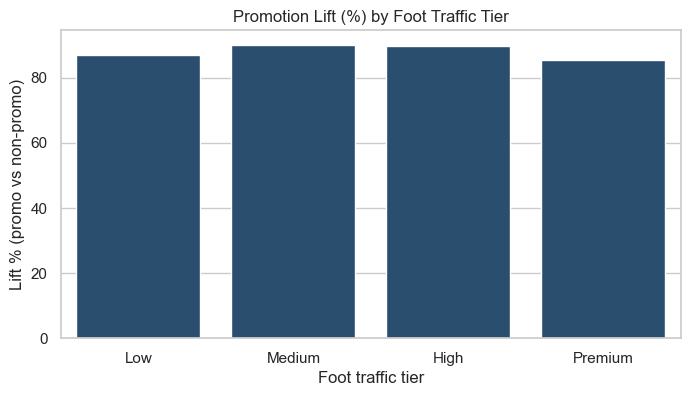

In [ ]:
plt.figure(figsize=(8,4))
sns.barplot(data=tier_promo.reset_index(), x="foot_traffic_tier", y="lift_pct", color="#1F4E79",
            order=["Low","Medium","High","Premium"])
plt.title("Promotion Lift (%) by Foot Traffic Tier")
plt.xlabel("Foot traffic tier")
plt.ylabel("Lift % (promo vs non-promo)")
plt.show()

double unit sales across all store tiers (85–90% lift) > Promotion  affects boost in demand
Absolute lift is larger in higher-traffic stores because baseline demand is higher

In [ ]:
sales.groupby(["store_id","sku_id","sale_date"]).size().describe()

count    25969106.0
mean            1.0
std             0.0
min             1.0
25%             1.0
50%             1.0
75%             1.0
max             1.0
dtype: float64

###  all tiers respond similarly (~85–90% lift)
### Premium has highest absolute lift +13.4 units coz base demand is higher 

### Stockout timeline & seasonality, stock per month


In [ ]:
stock["month"] = stock["stockout_date"].dt.to_period("M").dt.to_timestamp()

monthly_stockouts = stock.groupby("month").agg(
    events=("stockout_id","count"),
    lost_revenue=("estimated_lost_revenue","sum"),
    lost_units=("estimated_lost_units","sum"),
)

monthly_stockouts.head()

,events,lost_revenue,lost_units
month,,,
2024-01-01,7596,22603575.76,949259
2024-02-01,10030,14314470.41,584516
2024-03-01,11721,15011622.43,599188
2024-04-01,11254,15339478.03,606672
2024-05-01,12729,17550277.56,700192


events: count of stockout events starting in that month (based on stockout_date)
lost_revenue: total lost revenue for those events
lost_units: total lost units


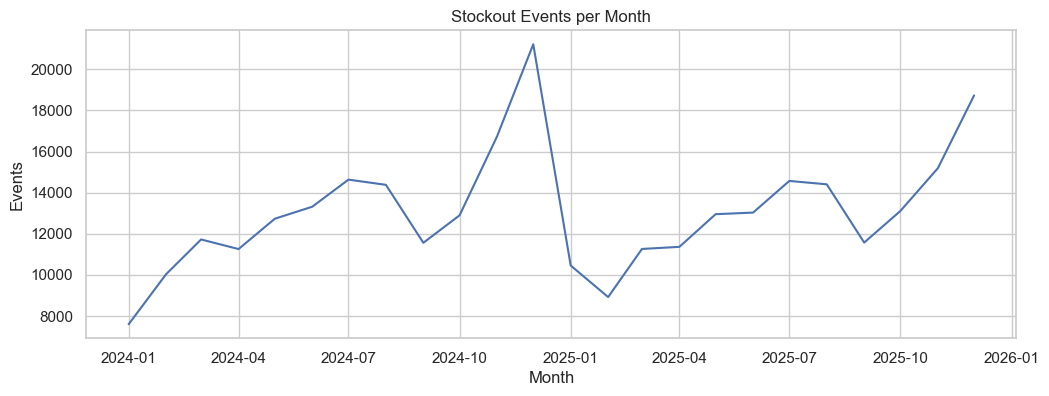

In [ ]:
plt.figure(figsize=(12,4))
sns.lineplot(data=monthly_stockouts.reset_index(), x="month", y="events")
plt.title("Stockout Events per Month")
plt.xlabel("Month")
plt.ylabel("Events")
plt.show()

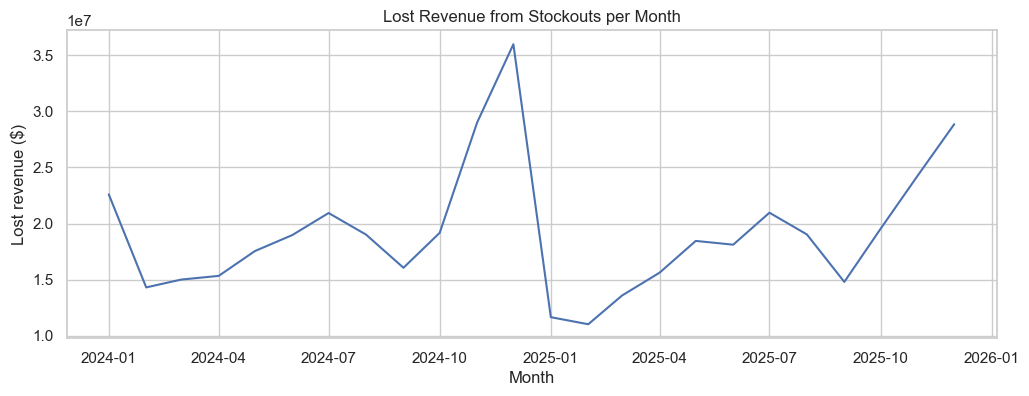

In [ ]:
plt.figure(figsize=(12,4))
sns.lineplot(data=monthly_stockouts.reset_index(), x="month", y="lost_revenue")
plt.title("Lost Revenue from Stockouts per Month")
plt.xlabel("Month")
plt.ylabel("Lost revenue ($)")
plt.show()

### Forecast quality EDA ( actual daily demand at store× sku ×date ) 

In [ ]:
actual = (
    sales.groupby(["store_id","sku_id","sale_date"], as_index=False)["units_sold"]
         .sum()
         .rename(columns={"sale_date":"date", "units_sold":"actual_units"})
)

fc = fcst.rename(columns={"forecast_date":"date", "forecast_units":"forecast_units"})

fa = actual.merge(fc, on=["store_id","sku_id","date"], how="inner")
fa["error"] = fa["actual_units"] - fa["forecast_units"]
fa["abs_error"] = fa["error"].abs()
fa["ape"] = (fa["abs_error"] / fa["actual_units"].replace(0, np.nan)) * 100

fa.head()

,store_id,sku_id,date,actual_units,forecast_id,forecast_units,forecast_method,created_at,lower_bound_90,upper_bound_90,error,abs_error,ape
0,S0001,P00055,2024-01-31,15,FC0000028685,23.43,MovingAvg7,2024-01-30,21.15,25.71,-8.43,8.43,56.200000
1,S0001,P00055,2024-01-31,15,FC0000028686,24.93,MovingAvg30,2024-01-30,21.12,28.74,-9.93,9.93,66.200000
2,S0001,P00055,2024-01-31,15,FC0000028687,30.00,SeasonalNaive,2024-01-30,24.63,35.37,-15.00,15.00,100.000000
3,S0001,P00055,2024-01-31,15,FC0000028688,21.78,ExponentialSmoothing,2024-01-30,17.57,25.99,-6.78,6.78,45.200000
4,S0001,P00055,2024-02-07,18,FC0000028689,21.43,MovingAvg7,2024-02-06,16.91,25.95,-3.43,3.43,19.055556


actual_units: true sales from sales table (aggregated)
forecast_units: forecast value from demand_forecasts
forecast_method: which baseline method produced it
lower/upper_bound_90: forecast uncertainty interval (90%)
error = actual − forecast (here negative value forecast was too high)
abs_error = |error|
ape = abs_error / actual_units * 100 (percentage error)
here for store id forecast is off by 56% for that day+sku+store

### Best forecaste method


In [ ]:
method_mape = fa.groupby("forecast_method")["ape"].mean().sort_values()
method_mape

forecast_method
MovingAvg30             45.978113
ExponentialSmoothing    47.043037
MovingAvg7              48.679656
SeasonalNaive           56.818325
Name: ape, dtype: float64

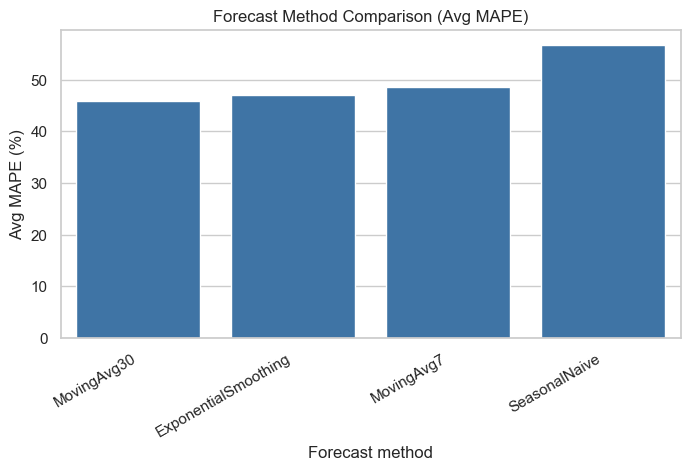

In [ ]:
plt.figure(figsize=(8,4))
sns.barplot(x=method_mape.index, y=method_mape.values, color="#2E75B6")
plt.title("Forecast Method Comparison (Avg MAPE)")
plt.xlabel("Forecast method")
plt.ylabel("Avg MAPE (%)")
plt.xticks(rotation=30, ha="right")
plt.show()

### interval coverage in in_90_interval%

In [ ]:
fa["in_90_interval"] = (fa["actual_units"] >= fa["lower_bound_90"]) & (fa["actual_units"] <= fa["upper_bound_90"])

coverage = fa.groupby("forecast_method")["in_90_interval"].mean().sort_values(ascending=False) * 100
coverage

forecast_method
MovingAvg30             32.701051
ExponentialSmoothing    32.395201
MovingAvg7              32.082876
SeasonalNaive           25.412343
Name: in_90_interval, dtype: float64

### 90% prediction interval = the true actual demand fall between lower and upper bound 90% of the time 
### in_90_interval = True if lower_bound_90 ≤ actual_units ≤ upper_bound_90
### interval coverage % = average of in_90_interval 
### Only 25–33% of actual demand falls inside the supposed 90% interval, so intervals are too narrow or not well-calibrated and we need to improving forecasting model or improving uncertainty estimation

does the actual units demand fall inside the predicted range lower bound/upper bound 90  and the % of times actual demand falls inside the 90% interval  
expected = 90% coverage and actal = 25 -32 % , only 32% of time the demand falls in range 

In [ ]:
# ## transactions from sales grouped by store_id, sku_id, sale_date 
## for grup add up units_sold and revenue, then sort by store_id, sku_id, sale_date


daily_sales = (
    sales.groupby(["store_id", "sku_id", "sale_date"], as_index=False)
         .agg(units_sold=("units_sold", "sum"), revenue=("revenue", "sum"))
         .sort_values(["store_id","sku_id","sale_date"])
)

# ### Groups by store + product and computes a 7-day average of units_sold, with a minimum of 3 days to compute the average
g = daily_sales.groupby(["store_id","sku_id"], sort=False)
daily_sales["7_day_avg"] = g["units_sold"].transform(lambda s: s.rolling(7, min_periods=3).mean())
daily_sales["7_day_avg_forecast"] = g["7_day_avg"].shift(1)  # Shift = forecast uses past 7 days only

daily_sales.head(15)

,store_id,sku_id,sale_date,units_sold,revenue,7_day_avg,7_day_avg_forecast
0,S0001,P00055,2024-01-01,31,1223.57,NaN,NaN
1,S0001,P00055,2024-01-02,21,828.87,NaN,NaN
2,S0001,P00055,2024-01-03,17,670.99,23.000000,NaN
3,S0001,P00055,2024-01-04,25,986.75,23.500000,23.000000
4,S0001,P00055,2024-01-05,27,1065.69,24.200000,23.500000
5,S0001,P00055,2024-01-06,31,1223.57,25.333333,24.200000
6,S0001,P00055,2024-01-07,37,1460.39,27.000000,25.333333
7,S0001,P00055,2024-01-08,19,749.93,25.285714,27.000000
8,S0001,P00055,2024-01-09,22,868.34,25.428571,25.285714
9,S0001,P00055,2024-01-10,24,947.28,26.428571,25.428571


## table shows daily sales totals per store-product and builds a 7-day rolling-demand forecast using only past data to compare predicted units vs actual units sold


## For each day, the model looks at the last 7 days average sales
## that average becomes tomorrow’s forecast (shift(1) means we use yesterday’s average, not today’s actual)

## Once enough days exist, forecast starts around 23–27 units, but actual sales jump between 17 and 37

## On some days forecast is too high example: forecast 26, actual 18
## On some days forecast is too low (example: forecast 25, actual 34)

## it fallows general trends but misses day to day spikes/drops 






calculates avg demand over last 7 days takes min_period of 3 to compute avg and prevents data leakage for jan 4th forecast uses dates of jan 1 - 3 
eg: on jan 4th ; units = 25 ; 7 - day avg = 23 and forecast = 23 
Jan 8th ; units = 19 ; and 7-day avg = 25 and forecast = 27
model lags behind the sudden spikes 

In [ ]:

daily_sales["sale_date"] = pd.to_datetime(daily_sales["sale_date"], errors="coerce")
daily_sales = daily_sales.dropna(subset=["sale_date"]).copy()


# Fetch and clean forecast table
demand_forecasts = dfs["demand_forecasts.csv"]
demand_forecasts["forecast_date"] = pd.to_datetime(demand_forecasts["forecast_date"], errors="coerce")
demand_forecasts = demand_forecasts.dropna(subset=["forecast_date"]).copy()

# Join daily_sales with forecasts
comparison = daily_sales.merge(
    demand_forecasts,
    left_on=["store_id", "sku_id", "sale_date"],
    right_on=["store_id", "sku_id", "forecast_date"],
    how="inner"
)

# Filter only MovingAvg7 and compare forecast vs actual
comparison = comparison[comparison["forecast_method"] == "MovingAvg7"]
comparison["error"] = comparison["forecast_units"] - comparison["units_sold"]
comparison["abs_error"] = comparison["error"].abs()

# Calculate error metrics using 7_day_avg_forecast 
rmse = (comparison["error"] ** 2).mean() ** 0.5
mae = comparison["abs_error"].mean() # Mean(avg) Absolute Error +/- 
mape = (comparison["abs_error"] / comparison["units_sold"]).mean() * 100

print(f"RMSE: {round(rmse, 2)} | MAE: {round(mae, 2)} | MAPE (%): {round(mape, 2)}")

comparison[["store_id", "sku_id", "sale_date", "units_sold", "7_day_avg_forecast", "forecast_units", "error", "abs_error"]].head(10)

RMSE: 4.24 | MAE: 2.89 | MAPE (%): 48.68


,store_id,sku_id,sale_date,units_sold,7_day_avg_forecast,forecast_units,error,abs_error
0,S0001,P00055,2024-01-31,15,23.428571,23.43,8.43,8.43
4,S0001,P00055,2024-02-07,18,21.428571,21.43,3.43,3.43
8,S0001,P00055,2024-02-14,20,21.142857,21.14,1.14,1.14
12,S0001,P00055,2024-02-21,21,25.714286,25.71,4.71,4.71
16,S0001,P00055,2024-02-28,17,20.285714,20.29,3.29,3.29
20,S0001,P00055,2024-03-06,31,25.428571,25.43,-5.57,5.57
24,S0001,P00055,2024-03-13,20,27.142857,27.14,7.14,7.14
28,S0001,P00055,2024-03-20,30,26.285714,26.29,-3.71,3.71
32,S0001,P00055,2024-03-27,23,26.857143,26.86,3.86,3.86
36,S0001,P00055,2024-04-03,22,27.571429,27.57,5.57,5.57


COLUMNS: 
- store_id, sku_id, sale_date = identify which store, which product, which day
- units_sold = actual units that were sold that day
- 7_day_avg =  computed trend (average of last 7 days)
- forecast_units = dataset predicted units for that day using MovingAvg7
- error = forecast_units minus units_sold (positive = overestimated, negative = underestimated)
- abs_error = absolute value of error (magnitude only, ignoring direction)

OUTPUT: 
For product P00055 in store S0001, comparing 10 specific dates where data made MovingAvg7 forecasts:
- Some dates data overestimated (predicted 23.43 but only 15 sold, error +8.43)
- Some dates data underestimated (predicted 25.43 but 31 sold, error -5.57)
- Most errors ranged between 1-8 units off from actual units sold

METRICS: used for evaluating forecast accuracy
MSE (Mean Squared Error) = Average error in units
MAPE mean absolute Percentage Error = Error % by actual demand & multipled
RMSE (Root Mean Squared Error) = square root /avg
- MAE = 2.89 means on average the forecast is wrong by 2.89 units
- RMSE = 4.24 means when you penalize bigger mistakes, the average error becomes 4.24 units
- MAPE = 48.68% means the forecast error is almost 50% of what was actually sold (very high)
Forecast error  = prediction - actual

Prediction Interval: Lower 90% bound, Upper 90% bound interval range where the actual value fall 90% of time
The Interval Width = Upper Bound - Lower Bound
eg: Interval Width = 30 - 20 = 10 units, 25 = forecast
Interval Width % = (10 / 25) × 100 = 40%
 allows 40% error margin 90% of the time



CONCLUSION:
data MovingAvg7 forecasting method is performing poorly on this product because demand is unpredictable day-to-day, and 48.68% error rate is unacceptable for demand planning—it need a more sophisticated forecasting method that can handle volatile/spiky sales patterns

Metric Ranges (Industry Standard )
Metric	Excellent	Good	Acceptable	Poor
MAPE	< 10% = excellent,	10-20% = good, 	20-50% = accepted	> 50% = poor
MAE	= Compare to baseline	Compare to baseline	Very high
RMSE =	Compare to baseline	Compare to baseline	Very high


chosen the forecast data and joined/comparsion(store_id + sku_id + date)(store–product–day level) of actual sold and forecast_units of MovingAvg7

| Actual | Forecast | Error |
| ------ | -------- | ----- |
| 15     | 23.43    | +8.43 |

| Actual | Forecast | Error |
| ------ | -------- | ----- |
| 31     | 25.43    | -5.57 |

Calculations
mae = avg(|forecast - actual|) = gives avg mistakes in units 



### Get all prediction intervals, Convert to percentage, Average all of them = avg prediction interval 

In [ ]:
demand_forecasts["interval_width"] = demand_forecasts["upper_bound_90"] - demand_forecasts["lower_bound_90"]
demand_forecasts["interval_width_pct"] = (demand_forecasts["interval_width"] / demand_forecasts["forecast_units"]) * 100

print("Average prediction interval width:")
print(demand_forecasts["interval_width_pct"].mean())
print("Acceptable error threshold/benchmark: 33 % given to us by the business")

Average prediction interval width:
32.99850876265258
Acceptable error threshold/benchmark: 33 % given to us by the business


FORECAST ACCURACY ANALYSIS

Acceptable Tolerance: 33.00%
Calculated Actual MAPE: 48.68%

Gap (how much worse): 15.68%
Ratio (multiplier): 1.48x

Interpretation:
Forecast is 15.68% worse than acceptable
Error is 1.48x of allowed


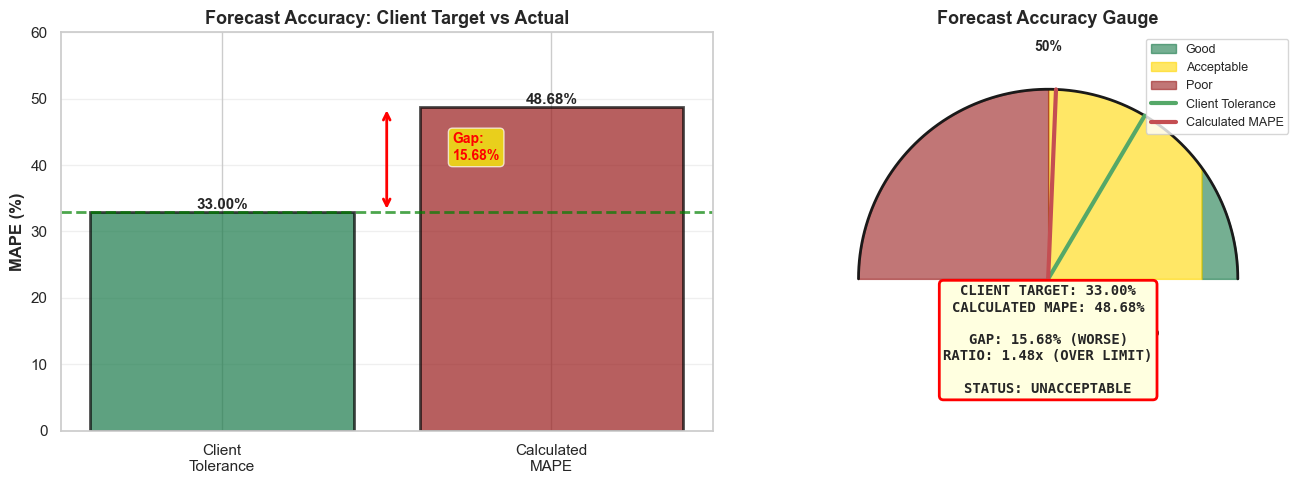


Saved as 'forecast_accuracy_analysis.png'


In [ ]:
demand_forecasts = dfs["demand_forecasts.csv"].copy()

demand_forecasts["interval_width"] = demand_forecasts["upper_bound_90"] - demand_forecasts["lower_bound_90"]
demand_forecasts["interval_width_pct"] = (demand_forecasts["interval_width"] / demand_forecasts["forecast_units"]) * 100
demand_forecasts = demand_forecasts.replace([np.inf, -np.inf], np.nan).dropna(subset=["interval_width_pct"])

client_tolerance = demand_forecasts["interval_width_pct"].mean()
calculated_mape = 48.68

gap = calculated_mape - client_tolerance
ratio = calculated_mape / client_tolerance

print("=" * 60)
print("FORECAST ACCURACY ANALYSIS")
print("=" * 60)
print(f"\nAcceptable Tolerance: {client_tolerance:.2f}%")
print(f"Calculated Actual MAPE: {calculated_mape:.2f}%")
print(f"\nGap (how much worse): {gap:.2f}%")
print(f"Ratio (multiplier): {ratio:.2f}x")
print("\nInterpretation:")
print(f"Forecast is {gap:.2f}% worse than acceptable")
print(f"Error is {ratio:.2f}x of allowed")
print("=" * 60)

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

categories = ['Client\nTolerance', 'Calculated\nMAPE']
values = [client_tolerance, calculated_mape]
colors = ['#1A7A4A', '#991B1B']

ax1 = axes[0]
bars = ax1.bar(categories, values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax1.axhline(y=client_tolerance, color='green', linestyle='--', linewidth=2, label='Acceptable Limit', alpha=0.7)
ax1.set_ylabel('MAPE (%)', fontsize=12, fontweight='bold')
ax1.set_title('Forecast Accuracy: Client Target vs Actual', fontsize=13, fontweight='bold')
ax1.set_ylim(0, 60)
ax1.grid(axis='y', alpha=0.3)

for bar, value in zip(bars, values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{value:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.annotate('', xy=(0.5, calculated_mape), xytext=(0.5, client_tolerance),
             arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax1.text(0.7, (calculated_mape + client_tolerance) / 2, f'Gap:\n{gap:.2f}%',
         fontsize=10, fontweight='bold', color='red',
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

ax2 = axes[1]
ax2.axis('off')

theta = np.linspace(0, np.pi, 100)
ax2.plot(np.cos(theta), np.sin(theta), 'k-', linewidth=2)

theta_green = np.linspace(0, np.pi * (20/100), 50)
ax2.fill_between(np.cos(theta_green), 0, np.sin(theta_green), color='#1A7A4A', alpha=0.6, label='Good')

theta_yellow = np.linspace(np.pi * (20/100), np.pi * (50/100), 50)
ax2.fill_between(np.cos(theta_yellow), 0, np.sin(theta_yellow), color='#FFD700', alpha=0.6, label='Acceptable')

theta_red = np.linspace(np.pi * (50/100), np.pi, 50)
ax2.fill_between(np.cos(theta_red), 0, np.sin(theta_red), color='#991B1B', alpha=0.6, label='Poor')

angle_client = np.pi * (client_tolerance / 100)
ax2.plot([0, np.cos(angle_client)], [0, np.sin(angle_client)], 'g-', linewidth=3, label='Client Tolerance')

angle_calculated = np.pi * (min(calculated_mape, 100) / 100)
ax2.plot([0, np.cos(angle_calculated)], [0, np.sin(angle_calculated)], 'r-', linewidth=3, label='Calculated MAPE')

ax2.text(-0.5, -0.3, '0%', ha='center', fontsize=10, fontweight='bold')
ax2.text(0, 1.2, '50%', ha='center', fontsize=10, fontweight='bold')
ax2.text(0.5, -0.3, '100%', ha='center', fontsize=10, fontweight='bold')

metrics_text = (
    f"CLIENT TARGET: {client_tolerance:.2f}%\n"
    f"CALCULATED MAPE: {calculated_mape:.2f}%\n\n"
    f"GAP: {gap:.2f}% (WORSE)\n"
    f"RATIO: {ratio:.2f}x (OVER LIMIT)\n\n"
    f"STATUS: UNACCEPTABLE"
)

ax2.text(
    0, -0.6, metrics_text, ha='center', fontsize=10,
    bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='red', linewidth=2),
    family='monospace', fontweight='bold'
)

ax2.set_xlim(-1.3, 1.3)
ax2.set_ylim(-0.8, 1.3)
ax2.set_aspect('equal')
ax2.legend(loc='upper right', fontsize=9)
ax2.set_title('Forecast Accuracy Gauge', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('forecast_accuracy_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved as 'forecast_accuracy_analysis.png'")

In [ ]:
import pandas as pd
import numpy as np

# ========= 0) LOAD =========
sales = dfs["sales_transactions.csv"].copy()
fcst = dfs["demand_forecasts.csv"].copy()
stock = dfs["stockout_events.csv"].copy()
products = dfs["products.csv"].copy()
stores = dfs["stores.csv"].copy()
suppliers = dfs["suppliers.csv"].copy() if "suppliers.csv" in dfs else None

# ========= 1) BASIC CLEAN =========
sales["sale_date"] = pd.to_datetime(sales["sale_date"], errors="coerce")
fcst["forecast_date"] = pd.to_datetime(fcst["forecast_date"], errors="coerce")
stock["stockout_date"] = pd.to_datetime(stock["stockout_date"], errors="coerce")

sales = sales.dropna(subset=["sale_date"]).copy()
fcst = fcst.dropna(subset=["forecast_date"]).copy()
stock = stock.dropna(subset=["stockout_date"]).copy()

# ========= 2) ACTUAL VS FORECAST TABLE =========
actual = (
    sales.groupby(["store_id","sku_id","sale_date"], as_index=False)
         .agg(actual_units=("units_sold","sum"),
              actual_revenue=("revenue","sum"),
              is_promoted=("is_promoted","max"))
         .rename(columns={"sale_date":"date"})
)

f = fcst.rename(columns={"forecast_date":"date"})
fa = actual.merge(
    f[["store_id","sku_id","date","forecast_method","forecast_units","lower_bound_90","upper_bound_90"]],
    on=["store_id","sku_id","date"],
    how="inner"
)

# keep all  models
fa = fa[fa["forecast_method"].isin(["MovingAvg7","MovingAvg30","SeasonalNaive","ExponentialSmoothing"])].copy()

# core error fields (compute once)
fa["error"] = fa["actual_units"] - fa["forecast_units"]   # +ve => under-forecast
fa["abs_error"] = fa["error"].abs()
fa["ape"] = (fa["abs_error"] / fa["actual_units"].replace(0, np.nan)) * 100
fa["in_90_interval"] = (fa["actual_units"] >= fa["lower_bound_90"]) & (fa["actual_units"] <= fa["upper_bound_90"])
fa["week"] = fa["date"].dt.to_period("W").astype(str)

# ========= 3) FORECAST-MISS STOCKOUT FILTER =========
fm = stock[stock["root_cause"] == "Forecast miss"].copy()

# product price proxy
price_col = "unit_price_regular" if "unit_price_regular" in products.columns else ("unit_cost" if "unit_cost" in products.columns else None)
prod_cols = ["sku_id","category"] + ([price_col] if price_col else [])
prod = products[prod_cols].copy()

store_cols = ["store_id"] + [c for c in ["foot_traffic_tier","region","store_format"] if c in stores.columns]
st = stores[store_cols].copy()

fm = fm.merge(prod, on="sku_id", how="left").merge(st, on="store_id", how="left")

# promo map from sales for stockout date
promo_map = sales[["store_id","sku_id","sale_date","is_promoted"]].rename(columns={"sale_date":"stockout_date"})
fm = fm.merge(promo_map, on=["store_id","sku_id","stockout_date"], how="left")
fm["is_promoted"] = fm["is_promoted"].fillna(False)

# ========= 4) PRICE BANDS =========
if price_col:
    fm["price_band"] = pd.qcut(fm[price_col], q=4, labels=["low","medium","high","premium"], duplicates="drop")
else:
    fm["price_band"] = "unknown"

price_summary = (
    fm.groupby("price_band", dropna=False)
      .agg(
          miss_count=("stockout_id","count"),
          lost_revenue=("estimated_lost_revenue","sum"),
          avg_miss_size_units=("estimated_lost_units","mean")
      )
      .sort_values("lost_revenue", ascending=False)
)

# ========= 5) BY STORE TIER =========
tier_summary = (
    fm.groupby("foot_traffic_tier", dropna=False)
      .agg(
          miss_count=("stockout_id","count"),
          lost_revenue=("estimated_lost_revenue","sum"),
          avg_duration=("duration_days","mean")
      )
      .sort_values("lost_revenue", ascending=False)
)

all_stock_tier = stock.merge(st, on="store_id", how="left")
tier_den = all_stock_tier.groupby("foot_traffic_tier")["stockout_id"].count().rename("all_stockout_events")
tier_summary = tier_summary.join(tier_den, how="left")
tier_summary["forecast_miss_rate_%"] = (tier_summary["miss_count"] / tier_summary["all_stockout_events"].replace(0,np.nan)) * 100

# ========= 6) PROMO vs NON-PROMO =========
promo_summary = (
    fm.groupby("is_promoted")
      .agg(
          miss_count=("stockout_id","count"),
          lost_revenue=("estimated_lost_revenue","sum"),
          avg_miss_size_units=("estimated_lost_units","mean")
      )
)
promo_summary["share_%"] = (promo_summary["miss_count"] / promo_summary["miss_count"].sum()) * 100

# ========= 7) CATEGORY + TOP SKUs =========
cat_summary = (
    fm.groupby("category", dropna=False)
      .agg(
          miss_count=("stockout_id","count"),
          lost_revenue=("estimated_lost_revenue","sum"),
          lost_units=("estimated_lost_units","sum")
      )
      .sort_values("lost_revenue", ascending=False)
)

top_skus = (
    fm.groupby("sku_id")
      .agg(
          miss_count=("stockout_id","count"),
          lost_revenue=("estimated_lost_revenue","sum"),
          lost_units=("estimated_lost_units","sum")
      )
      .sort_values("lost_revenue", ascending=False)
      .head(20)
      .reset_index()
      .merge(products[["sku_id","category"]], on="sku_id", how="left")
      .set_index("sku_id")
)

# ========= 8) TIME PATTERNS =========
fm["dow"] = fm["stockout_date"].dt.day_name()
fm["month"] = fm["stockout_date"].dt.month
fm["year_month"] = fm["stockout_date"].dt.to_period("M").astype(str)
fm["season"] = fm["stockout_date"].dt.month.map(
    {12:"Winter",1:"Winter",2:"Winter",3:"Spring",4:"Spring",5:"Spring",
     6:"Summer",7:"Summer",8:"Summer",9:"Fall",10:"Fall",11:"Fall"}
)

dow_summary = fm.groupby("dow").agg(miss_count=("stockout_id","count"), lost_revenue=("estimated_lost_revenue","sum")).sort_values("lost_revenue", ascending=False)
month_summary = fm.groupby("month").agg(miss_count=("stockout_id","count"), lost_revenue=("estimated_lost_revenue","sum")).sort_values("lost_revenue", ascending=False)
season_summary = fm.groupby("season").agg(miss_count=("stockout_id","count"), lost_revenue=("estimated_lost_revenue","sum")).sort_values("lost_revenue", ascending=False)

# ========= 9) SUPPLIER RELIABILITY (if mappable) =========
supplier_summary = None
if suppliers is not None and "supplier_id" in products.columns and "supplier_id" in suppliers.columns:
    fm_sup = fm.merge(products[["sku_id","supplier_id"]], on="sku_id", how="left")
    fm_sup = fm_sup.merge(suppliers[["supplier_id","lead_time_days_avg","reliability_score"]], on="supplier_id", how="left")
    fm_sup = fm_sup.dropna(subset=["reliability_score"])
    if len(fm_sup) > 0:
        fm_sup["reliability_bucket"] = pd.qcut(fm_sup["reliability_score"], 4, duplicates="drop")
        supplier_summary = (
            fm_sup.groupby("reliability_bucket")
                  .agg(miss_count=("stockout_id","count"),
                       lost_revenue=("estimated_lost_revenue","sum"),
                       avg_lost_units=("estimated_lost_units","mean"))
                  .sort_values("lost_revenue", ascending=False)
        )

# ========= 10) ERROR SHAPE =========
shape = pd.DataFrame({
    "under_forecast_count": [(fa["error"] > 0).sum()],
    "over_forecast_count": [(fa["error"] < 0).sum()],
    "under_forecast_%": [((fa["error"] > 0).mean()*100)],
    "over_forecast_%": [((fa["error"] < 0).mean()*100)]
})

# ========= 11) KPI TABLES =========

# A) Model-level KPI
model_kpi = fa.groupby("forecast_method").agg(
    mape=("ape","mean"),
    mae=("abs_error","mean"),
    rmse=("error", lambda x: np.sqrt(np.mean(np.square(x)))),
    bias=("error","mean"),
    p90_coverage=("in_90_interval","mean"),
    wape_num=("abs_error","sum"),
    wape_den=("actual_units","sum")
).reset_index()

model_kpi["wape"] = (model_kpi["wape_num"] / model_kpi["wape_den"].replace(0,np.nan)) * 100
model_kpi["p90_coverage"] = model_kpi["p90_coverage"] * 100
model_kpi = model_kpi[["forecast_method","mape","wape","mae","rmse","bias","p90_coverage"]].sort_values("mape")

# B) Weekly KPI by model
weekly_kpi_by_model = fa.groupby(["week","forecast_method"]).agg(
    mape=("ape","mean"),
    wape_num=("abs_error","sum"),
    wape_den=("actual_units","sum"),
    bias=("error","mean"),
    p90_coverage=("in_90_interval","mean")
).reset_index()

weekly_kpi_by_model["wape"] = (weekly_kpi_by_model["wape_num"] / weekly_kpi_by_model["wape_den"].replace(0,np.nan)) * 100
weekly_kpi_by_model["p90_coverage"] = weekly_kpi_by_model["p90_coverage"] * 100
weekly_kpi_by_model = weekly_kpi_by_model[["week","forecast_method","mape","wape","bias","p90_coverage"]]

# C) Weekly business KPI (forecast-miss only)
fm["week"] = fm["stockout_date"].dt.to_period("W").astype(str)
weekly_fm = fm.groupby("week").agg(
    forecast_miss_stockout_events=("stockout_id","count"),
    forecast_miss_lost_revenue=("estimated_lost_revenue","sum")
).reset_index()

if price_col:
    high_cut = fm[price_col].quantile(0.75)
    fm["is_high_price"] = fm[price_col] >= high_cut
    high_price_weekly = fm.groupby("week").agg(
        high_price_miss_events=("is_high_price","sum"),
        total_miss_events=("stockout_id","count")
    ).reset_index()
    high_price_weekly["high_price_stockout_rate_%"] = (
        high_price_weekly["high_price_miss_events"] / high_price_weekly["total_miss_events"].replace(0,np.nan)
    ) * 100
    high_price_weekly = high_price_weekly[["week","high_price_stockout_rate_%"]]
else:
    high_price_weekly = pd.DataFrame(columns=["week","high_price_stockout_rate_%"])

if "estimated_lost_units" in fm.columns:
    lost_u = fm.groupby("week")["estimated_lost_units"].sum().rename("lost_units").reset_index()
    sold_u = sales.copy()
    sold_u["week"] = sold_u["sale_date"].dt.to_period("W").astype(str)
    sold_u = sold_u.groupby("week")["units_sold"].sum().rename("sold_units").reset_index()
    svc = sold_u.merge(lost_u, on="week", how="left").fillna({"lost_units":0})
    svc["service_level_proxy_%"] = (
        1 - (svc["lost_units"] / (svc["sold_units"] + svc["lost_units"]).replace(0,np.nan))
    ) * 100
    svc = svc[["week","service_level_proxy_%"]]
else:
    svc = pd.DataFrame(columns=["week","service_level_proxy_%"])

weekly_business_kpi = (
    weekly_fm.merge(high_price_weekly, on="week", how="left")
             .merge(svc, on="week", how="left")
             .sort_values("week")
)

weekly_final = weekly_kpi_by_model.merge(weekly_business_kpi, on="week", how="left").sort_values(["week","forecast_method"])

# ========= 12) PRINT OUTPUTS =========
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)

print("\n=== PRICE BAND SUMMARY (Forecast miss only) ===")
print(price_summary)

print("\n=== STORE TIER SUMMARY (Forecast miss only) ===")
print(tier_summary)

print("\n=== PROMO vs NON-PROMO (Forecast miss only) ===")
print(promo_summary)

print("\n=== TOP CATEGORIES by lost_revenue (Forecast miss only) ===")
print(cat_summary.head(15))

print("\n=== TOP 20 SKUs by lost_revenue (Forecast miss only) ===")
print(top_skus.head(20))

print("\n=== TIME PATTERN: DAY OF WEEK ===")
print(dow_summary)

print("\n=== TIME PATTERN: MONTH ===")
print(month_summary)

print("\n=== TIME PATTERN: SEASON ===")
print(season_summary)

print("\n=== ERROR SHAPE (from forecast table) ===")
print(shape)

if supplier_summary is not None:
    print("\n=== SUPPLIER RELIABILITY BUCKET SUMMARY ===")
    print(supplier_summary)

print("\n=== MODEL KPI COMPARISON (ALL 4 CLIENT MODELS) ===")
print(model_kpi)

print("\n=== WEEKLY KPI BY MODEL (LAST 12 WEEKS PER MODEL) ===")
print(weekly_kpi_by_model.sort_values("week").groupby("forecast_method").tail(12))

print("\n=== WEEKLY BUSINESS KPI (FORECAST MISS) - LAST 12 WEEKS ===")
print(weekly_business_kpi.tail(12))

print("\n=== COMBINED WEEKLY FINAL (LAST 20 ROWS) ===")
print(weekly_final.tail(20))

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_93363/1609361114.py:63: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  fm["is_promoted"] = fm["is_promoted"].fillna(False)
/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_93363/1609361114.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fm.groupby("price_band", dropna=False)
/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_93363/1609361114.py:155: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current


=== PRICE BAND SUMMARY (Forecast miss only) ===
            miss_count  lost_revenue  avg_miss_size_units
price_band                                               
premium          15290   35744897.01            56.149575
high             15681   26985332.49            54.534979
medium           15592   17004636.56            54.095883
low              15585    6063800.90            55.888803

=== STORE TIER SUMMARY (Forecast miss only) ===
                   miss_count  lost_revenue  avg_duration  all_stockout_events  forecast_miss_rate_%
foot_traffic_tier                                                                                   
Premium                 25945   47538927.59      4.418424               130251             19.919233
High                    15480   21547073.91      4.287080                78327             19.763300
Medium                  12417   12053371.98      4.116212                63027             19.701080
Low                      8306    4659293.48      

Best current model = MovingAvg30

MAPE 45.98, WAPE ~28.89 (best among 4), but still weak.
SeasonalNaive is clearly worst.
Prediction intervals are broken

P90 coverage 25–33% (should be near 90%).
High-priority fix in next model.
Forecast miss is a major revenue problem

Forecast-miss lost revenue is concentrated in premium/high price bands.
Premium price band has biggest loss (~35.7M).
Store tier concentration

Premium tier has highest miss count and lost revenue.
Forecast-miss rate (19.7–19.9%) is similar across tiers, but financial impact is much higher in Premium.
Promo insight is nuanced

Only 5% of forecast-miss events occur on promo days,
but promo misses are much larger (avg_miss_size_units ~98 vs ~53 non-promo)
So promo misses are fewer but severe.
Time risk windows

Higher miss/loss around Fri/Sat and Nov-Dec.
Good input for safety stock and alerting windows
Error shape

Over-forecast count is slightly higher overall, but under-forecast remains huge and is what causes stockouts.
Your new model should explicitly reduce under-forecast on high-value SKUs.

In [ ]:
# -----------------------------
# 1) Lost revenue rate by SKU
# -----------------------------
# fm already = stock[stock["root_cause"]=="Forecast miss"] merged with product/store fields
# sales has sku-level revenue available

sku_total_rev = (
    sales.groupby("sku_id", as_index=False)
         .agg(sku_total_revenue=("revenue","sum"))
)

sku_fm = (
    fm.groupby("sku_id", as_index=False)
      .agg(
          miss_count=("stockout_id","count"),
          lost_revenue=("estimated_lost_revenue","sum"),
          lost_units=("estimated_lost_units","sum")
      )
)

sku_loss_rate = sku_fm.merge(sku_total_rev, on="sku_id", how="left")
sku_loss_rate["lost_revenue_rate_%"] = (
    sku_loss_rate["lost_revenue"] / sku_loss_rate["sku_total_revenue"].replace(0, np.nan)
) * 100

# add category for readability
sku_loss_rate = sku_loss_rate.merge(products[["sku_id","category"]], on="sku_id", how="left")

# top by absolute loss
top_abs_loss = sku_loss_rate.sort_values("lost_revenue", ascending=False).head(20)

# top by rate (filter low-revenue noisy SKUs)
top_rate_loss = (
    sku_loss_rate[sku_loss_rate["sku_total_revenue"] >= sku_loss_rate["sku_total_revenue"].quantile(0.5)]
    .sort_values("lost_revenue_rate_%", ascending=False)
    .head(20)
)

print("\n=== TOP 20 SKUs BY ABSOLUTE FORECAST-MISS LOST REVENUE ===")
print(top_abs_loss[["sku_id","category","miss_count","lost_revenue","sku_total_revenue","lost_revenue_rate_%"]])

print("\n=== TOP 20 SKUs BY LOST REVENUE RATE % (FILTERED) ===")
print(top_rate_loss[["sku_id","category","miss_count","lost_revenue","sku_total_revenue","lost_revenue_rate_%"]])


# -----------------------------
# 2) Promo miss severity by category
# -----------------------------
promo_cat = (
    fm.groupby(["category","is_promoted"], as_index=False)
      .agg(
          miss_count=("stockout_id","count"),
          lost_revenue=("estimated_lost_revenue","sum"),
          avg_lost_units=("estimated_lost_units","mean")
      )
)

# pivot for easy comparison
promo_cat_pivot = promo_cat.pivot(index="category", columns="is_promoted", values=["miss_count","lost_revenue","avg_lost_units"])
promo_cat_pivot.columns = [f"{m}_{'promo' if p else 'nonpromo'}" for m,p in promo_cat_pivot.columns]
promo_cat_pivot = promo_cat_pivot.reset_index()

for c in ["miss_count_promo","lost_revenue_promo","avg_lost_units_promo",
          "miss_count_nonpromo","lost_revenue_nonpromo","avg_lost_units_nonpromo"]:
    if c not in promo_cat_pivot.columns:
        promo_cat_pivot[c] = 0

promo_cat_pivot["promo_miss_share_%"] = (
    promo_cat_pivot["miss_count_promo"] /
    (promo_cat_pivot["miss_count_promo"] + promo_cat_pivot["miss_count_nonpromo"]).replace(0,np.nan)
) * 100

promo_cat_pivot["promo_severity_lift_units_%"] = (
    (promo_cat_pivot["avg_lost_units_promo"] / promo_cat_pivot["avg_lost_units_nonpromo"].replace(0,np.nan)) - 1
) * 100

promo_cat_pivot["promo_severity_lift_revenue_%"] = (
    (promo_cat_pivot["lost_revenue_promo"] / promo_cat_pivot["miss_count_promo"].replace(0,np.nan)) /
    (promo_cat_pivot["lost_revenue_nonpromo"] / promo_cat_pivot["miss_count_nonpromo"].replace(0,np.nan))
    - 1
) * 100

promo_cat_pivot = promo_cat_pivot.sort_values("promo_severity_lift_revenue_%", ascending=False)

print("\n=== PROMO MISS SEVERITY BY CATEGORY ===")
print(promo_cat_pivot[[
    "category",
    "miss_count_nonpromo","miss_count_promo","promo_miss_share_%",
    "avg_lost_units_nonpromo","avg_lost_units_promo","promo_severity_lift_units_%",
    "promo_severity_lift_revenue_%"
]].head(20))


=== TOP 20 SKUs BY ABSOLUTE FORECAST-MISS LOST REVENUE ===
     sku_id           category  miss_count  lost_revenue  sku_total_revenue  lost_revenue_rate_%
974  P01255  Health & Wellness         361     876209.28         7435346.97            11.784376
374  P00489             Bakery         352     875665.92         4603519.48            19.021662
100  P00139          Beverages         372     738578.49         4110300.69            17.968965
151  P00199       Dairy & Eggs         385     734734.12         7813312.11             9.403619
816  P01050    Canned & Pantry         416     730781.73         8620787.33             8.476972
287  P00376             Snacks         415     717466.75         6192681.59            11.585720
496  P00644      Personal Care         343     688042.15         6063513.20            11.347252
784  P01005    Canned & Pantry         325     664097.61         6687844.98             9.929919
135  P00182       Dairy & Eggs         410     625579.00         58


SKUs like P01255, P00489, P00139 are both high absolute loss and high loss-rate
considered for pilot
Loss-rate view confirmed hidden risk

Some SKUs not top by absolute loss still have high % loss vs their own revenue
adding this metric
Promo misses are rare but severe

Promo miss share mostly 4–7%, but promo severity is much higher
Example: Meat & Seafood promo miss revenue severity 141% higher
This strongly justifies promo-aware features

In [ ]:
import pandas as pd
import numpy as np

# =========================
# A) FREEZE BASELINE TABLES
# =========================
# (assumes these already exist from your EDA run:
# model_kpi, price_summary, top_abs_loss, top_rate_loss, promo_cat_pivot, weekly_business_kpi)

baseline_artifacts = {
    "model_kpi": model_kpi.copy(),
    "price_summary": price_summary.copy(),
    "top_abs_loss": top_abs_loss.copy(),
    "top_rate_loss": top_rate_loss.copy(),
    "promo_cat_pivot": promo_cat_pivot.copy(),
    "weekly_business_kpi": weekly_business_kpi.copy()
}

# save as CSV
for name, df_ in baseline_artifacts.items():
    df_.to_csv(f"./{name}.csv", index=True if df_.index.name is not None else False)

print(" Baseline tables saved:",
      ", ".join([f"{k}.csv" for k in baseline_artifacts.keys()]))

# =========================
# B) DEFINE PILOT COHORT (for reporting only, even though model is full-scope)
# =========================
# top 20 SKUs = union of top 10 absolute + top 10 rate
top10_abs = top_abs_loss.head(10)["sku_id"].tolist()
top10_rate = top_rate_loss.head(10)["sku_id"].tolist()
pilot_skus = sorted(list(set(top10_abs).union(set(top10_rate))))

# top 20 stores by forecast-miss lost revenue
fm_store = (
    fm.groupby("store_id", as_index=False)
      .agg(forecast_miss_lost_revenue=("estimated_lost_revenue","sum"))
      .sort_values("forecast_miss_lost_revenue", ascending=False)
)
pilot_stores = fm_store.head(20)["store_id"].tolist()

pilot_cohort = pd.DataFrame({
    "pilot_skus": pd.Series(pilot_skus),
})
pilot_cohort.to_csv("./pilot_skus.csv", index=False)
fm_store.head(20).to_csv("./pilot_stores.csv", index=False)

print(f" Pilot SKUs count: {len(pilot_skus)} | Pilot stores count: {len(pilot_stores)}")
print("Saved: pilot_skus.csv, pilot_stores.csv")

# =========================
# C) BUILD FULL TRAINING DATASET (ALL STORES + ALL SKUs)
# =========================

sales = dfs["sales_transactions.csv"].copy()
products = dfs["products.csv"].copy()
stores = dfs["stores.csv"].copy()

# --- clean dates
sales["sale_date"] = pd.to_datetime(sales["sale_date"], errors="coerce")
sales = sales.dropna(subset=["sale_date"]).copy()

# --- daily grain
daily = (
    sales.groupby(["store_id","sku_id","sale_date"], as_index=False)
         .agg(
             actual_units=("units_sold","sum"),
             revenue=("revenue","sum"),
             is_promoted=("is_promoted","max"),
             unit_price_actual=("unit_price_actual","mean") if "unit_price_actual" in sales.columns else ("units_sold","count")
         )
         .rename(columns={"sale_date":"date"})
)

# if fallback happened above, clean placeholder
if "unit_price_actual" in daily.columns and daily["unit_price_actual"].dtype != "float64":
    daily["unit_price_actual"] = np.nan

# --- product features
prod_cols = ["sku_id","category"]
if "unit_price_regular" in products.columns:
    prod_cols.append("unit_price_regular")
if "unit_cost" in products.columns:
    prod_cols.append("unit_cost")

prod = products[prod_cols].drop_duplicates("sku_id").copy()

# --- store features
store_cols = ["store_id"] + [c for c in ["foot_traffic_tier","region","store_format"] if c in stores.columns]
st = stores[store_cols].drop_duplicates("store_id").copy()

# --- merge static features
df = daily.merge(prod, on="sku_id", how="left").merge(st, on="store_id", how="left")

# --- choose price feature
price_feature = None
if "unit_price_actual" in df.columns and df["unit_price_actual"].notna().any():
    price_feature = "unit_price_actual"
elif "unit_price_regular" in df.columns:
    price_feature = "unit_price_regular"
elif "unit_cost" in df.columns:
    price_feature = "unit_cost"

# --- price band (global)
if price_feature is not None:
    df["price_band"] = pd.qcut(df[price_feature], q=4, labels=["low","medium","high","premium"], duplicates="drop")
else:
    df["price_band"] = "unknown"

# --- calendar features
df["dow"] = df["date"].dt.dayofweek               # 0=Mon
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)
df["is_weekend"] = df["dow"].isin([5,6]).astype(int)

# --- sort for lag creation
df = df.sort_values(["store_id","sku_id","date"]).copy()

# --- lags and rolling stats per store-sku
g = df.groupby(["store_id","sku_id"], sort=False)

for lag in [1, 7, 14, 28]:
    df[f"lag_{lag}"] = g["actual_units"].shift(lag)

# rolling features (safe way)
df["roll_mean_7"] = g["actual_units"].transform(lambda s: s.shift(1).rolling(7, min_periods=3).mean())
df["roll_std_7"]  = g["actual_units"].transform(lambda s: s.shift(1).rolling(7, min_periods=3).std())

df["roll_mean_28"] = g["actual_units"].transform(lambda s: s.shift(1).rolling(28, min_periods=7).mean())
df["roll_std_28"]  = g["actual_units"].transform(lambda s: s.shift(1).rolling(28, min_periods=7).std())

# --- modeling target (for now)
df["target"] = df["actual_units"]

# --- keep model-ready columns
feature_cols = [
    "store_id","sku_id","date","target","true_demand","actual_units","revenue",
    "is_promoted","category","foot_traffic_tier","region","store_format","price_band",
    "dow","month","day","weekofyear","is_weekend",
    "lag_1","lag_7","lag_14","lag_28","roll_mean_7","roll_std_7","roll_mean_28","roll_std_28"
]

# keep only existing columns safely
feature_cols = [c for c in feature_cols if c in df.columns]
train_master = df[feature_cols].copy()

# --- drop rows where lag features not available (first weeks of each series)
lag_cols = [c for c in ["lag_1","lag_7","lag_14","lag_28","roll_mean_7","roll_mean_28"] if c in train_master.columns]
train_master = train_master.dropna(subset=lag_cols).copy()

# --- cast categoricals
for c in ["store_id","sku_id","category","foot_traffic_tier","region","store_format","price_band"]:
    if c in train_master.columns:
        train_master[c] = train_master[c].astype("category")

# --- save full training dataset
train_master.to_csv("./train_master_full.csv", index=False)

train_master.head(100000).to_csv("./train_master_full_sample_100k.csv", index=False)
print(" Saved: train_master_full.csv, train_master_full_sample_100k.csv")


print(" Training dataset built.")
print("Shape:", train_master.shape)
print("Date range:", train_master["date"].min(), "to", train_master["date"].max())
print("Saved: train_master_full.csv, train_master_full_sample_100k.csv")
print("Columns:", train_master.columns.tolist())

 Baseline tables saved: model_kpi.csv, price_summary.csv, top_abs_loss.csv, top_rate_loss.csv, promo_cat_pivot.csv, weekly_business_kpi.csv
 Pilot SKUs count: 12 | Pilot stores count: 20
Saved: pilot_skus.csv, pilot_stores.csv
 Saved: train_master_full.csv, train_master_full_sample_100k.csv
 Training dataset built.
Shape: (24898386, 25)
Date range: 2024-01-29 00:00:00 to 2025-12-31 00:00:00
Saved: train_master_full.csv, train_master_full_sample_100k.csv
Columns: ['store_id', 'sku_id', 'date', 'target', 'actual_units', 'revenue', 'is_promoted', 'category', 'foot_traffic_tier', 'region', 'store_format', 'price_band', 'dow', 'month', 'day', 'weekofyear', 'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'roll_mean_7', 'roll_std_7', 'roll_mean_28', 'roll_std_28']


In [ ]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv("./train_master_full.csv", parse_dates=["date"])

# time split
train = df[df["date"] <= "2025-06-30"].copy()
valid = df[(df["date"] >= "2025-07-01") & (df["date"] <= "2025-09-30")].copy()
test  = df[(df["date"] >= "2025-10-01") & (df["date"] <= "2025-12-31")].copy()

features = [
    "is_promoted","category","foot_traffic_tier","region","store_format","price_band",
    "dow","month","day","weekofyear","is_weekend",
    "lag_1","lag_7","lag_14","lag_28","roll_mean_7","roll_std_7","roll_mean_28","roll_std_28"
]

cat_cols = ["category","foot_traffic_tier","region","store_format","price_band"]

for c in cat_cols:
    train[c] = train[c].astype("category")
    valid[c] = valid[c].astype("category")
    test[c] = test[c].astype("category")

X_train, y_train = train[features], train["target"]
X_valid, y_valid = valid[features], valid["target"]
X_test, y_test   = test[features], test["target"]

model = LGBMRegressor(
    objective="regression",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="l1",
    categorical_feature=cat_cols
)

test["forecast_units"] = model.predict(X_test).clip(0)

# metrics
err = y_test - test["forecast_units"]
abs_err = err.abs()
ape = abs_err / y_test.replace(0, np.nan) * 100

mape = np.nanmean(ape)
wape = abs_err.sum() / y_test.sum() * 100
mae = mean_absolute_error(y_test, test["forecast_units"])
rmse = np.sqrt(mean_squared_error(y_test, test["forecast_units"]))
bias = err.mean()

print(f"CustomModel_v1 -> MAPE={mape:.2f}, WAPE={wape:.2f}, MAE={mae:.2f}, RMSE={rmse:.2f}, Bias={bias:.2f}")

custom_pred = test[["store_id","sku_id","date","forecast_units"]].copy()
custom_pred["forecast_method"] = "CustomModel_v1"
custom_pred.to_csv("./custom_model_v1_test_predictions.csv", index=False)
print("Saved: custom_model_v1_test_predictions.csv")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.151260 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1496
[LightGBM] [Info] Number of data points in the train set: 18355832, number of used features: 19
[LightGBM] [Info] Start training from score 10.205091
CustomModel_v1 -> MAPE=40.53, WAPE=24.18, MAE=2.80, RMSE=4.03, Bias=-0.12
Saved: custom_model_v1_test_predictions.csv


In [ ]:
import pandas as pd

# load baseline model table you saved earlier
model_kpi = pd.read_csv("./model_kpi.csv")

# if coverage column naming mismatch, standardize
if "p90_coverage" not in model_kpi.columns and "coverage_90" in model_kpi.columns:
    model_kpi = model_kpi.rename(columns={"coverage_90": "p90_coverage"})

# now concat
comparison_table = pd.concat([model_kpi.copy(), custom_row], ignore_index=True)
comparison_table = comparison_table.sort_values("mape").reset_index(drop=True)

print("\n=== FORMAL COMPARISON TABLE ===")
print(comparison_table)


=== FORMAL COMPARISON TABLE ===
        forecast_method       mape       wape       mae      rmse      bias  \
0        CustomModel_v1  40.530127  24.176468  2.795133  4.027924 -0.119225   
1           MovingAvg30  45.978113  28.890585  2.731047  3.969205 -0.379435   
2  ExponentialSmoothing  47.043037  29.359922  2.775414  4.027161 -0.416024   
3            MovingAvg7  48.679656  30.521024  2.885174  4.244169 -0.610728   
4         SeasonalNaive  56.818325  39.408948  3.725355  5.653721  0.521250   

   p90_coverage  
0     90.692781  
1     32.701051  
2     32.395201  
3     32.082876  
4     25.412343  


In [ ]:
best_baseline = model_kpi.sort_values("mape").iloc[0]

improve_mape = (best_baseline["mape"] - custom_row.iloc[0]["mape"]) / best_baseline["mape"] * 100
improve_wape = (best_baseline["wape"] - custom_row.iloc[0]["wape"]) / best_baseline["wape"] * 100
coverage_gain = custom_row.iloc[0]["p90_coverage"] - best_baseline["p90_coverage"]

print(f"Best baseline: {best_baseline['forecast_method']}")
print(f"MAPE improvement: {improve_mape:.2f}%")
print(f"WAPE improvement: {improve_wape:.2f}%")
print(f"P90 coverage gain: {coverage_gain:.2f} points")

Best baseline: MovingAvg30
MAPE improvement: 11.85%
WAPE improvement: 16.32%
P90 coverage gain: 57.99 points


In [ ]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================
# 0) LOAD TRAIN DATA
# =========================
df = pd.read_csv("./train_master_full.csv", parse_dates=["date"])

# time split
train = df[df["date"] <= "2025-06-30"].copy()
valid = df[(df["date"] >= "2025-07-01") & (df["date"] <= "2025-09-30")].copy()
test  = df[(df["date"] >= "2025-10-01") & (df["date"] <= "2025-12-31")].copy()

features = [
    "is_promoted","category","foot_traffic_tier","region","store_format","price_band",
    "dow","month","day","weekofyear","is_weekend",
    "lag_1","lag_7","lag_14","lag_28","roll_mean_7","roll_std_7","roll_mean_28","roll_std_28"
]
cat_cols = ["category","foot_traffic_tier","region","store_format","price_band"]

# cast categorical
for c in cat_cols:
    if c in train.columns:
        train[c] = train[c].astype("category")
        valid[c] = valid[c].astype("category")
        test[c] = test[c].astype("category")

X_train, y_train = train[features], train["target"]
X_valid, y_valid = valid[features], valid["target"]
X_test, y_test   = test[features], test["target"]

# =========================
# 1) P50 MODEL (POINT FORECAST)
# =========================
p50_model = LGBMRegressor(
    objective="regression",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

p50_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="l1",
    categorical_feature=cat_cols
)

test_pred = test[["store_id","sku_id","date","target"]].copy()
test_pred["forecast_units"] = p50_model.predict(X_test).clip(0)

# =========================
# 2) QUANTILE MODELS (P05 / P95)
# =========================
p05_model = LGBMRegressor(
    objective="quantile",
    alpha=0.05,
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

p95_model = LGBMRegressor(
    objective="quantile",
    alpha=0.95,
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

p05_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="quantile",
    categorical_feature=cat_cols
)

p95_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="quantile",
    categorical_feature=cat_cols
)

test_pred["lower_bound_90"] = p05_model.predict(X_test).clip(0)
test_pred["upper_bound_90"] = p95_model.predict(X_test).clip(0)

# enforce ordering
swap_mask = test_pred["lower_bound_90"] > test_pred["upper_bound_90"]
test_pred.loc[swap_mask, ["lower_bound_90","upper_bound_90"]] = test_pred.loc[swap_mask, ["upper_bound_90","lower_bound_90"]].values

test_pred["forecast_method"] = "CustomModel_v1"

# =========================
# 3) CUSTOM MODEL METRICS
# =========================
err = test_pred["target"] - test_pred["forecast_units"]
abs_err = err.abs()
ape = abs_err / test_pred["target"].replace(0, np.nan) * 100
in_90 = (test_pred["target"] >= test_pred["lower_bound_90"]) & (test_pred["target"] <= test_pred["upper_bound_90"])

custom_metrics = {
    "forecast_method": "CustomModel_v1",
    "mape": float(np.nanmean(ape)),
    "wape": float(abs_err.sum() / test_pred["target"].sum() * 100),
    "mae": float(mean_absolute_error(test_pred["target"], test_pred["forecast_units"])),
    "rmse": float(np.sqrt(mean_squared_error(test_pred["target"], test_pred["forecast_units"]))),
    "bias": float(err.mean()),
    "p90_coverage": float(in_90.mean() * 100)
}
custom_row = pd.DataFrame([custom_metrics])

print("\n=== CUSTOM MODEL METRICS ===")
print(custom_row)

# =========================
# 4) FORMAL COMPARISON TABLE (BASELINE + CUSTOM)
# =========================
# assumes model_kpi exists from earlier baseline run
comparison_table = pd.concat([model_kpi.copy(), custom_row], ignore_index=True)
comparison_table = comparison_table.sort_values("mape").reset_index(drop=True)

print("\n=== FORMAL COMPARISON TABLE ===")
print(comparison_table)

# improvement vs best baseline
best_baseline = model_kpi.sort_values("mape").iloc[0]
improve_mape = (best_baseline["mape"] - custom_metrics["mape"]) / best_baseline["mape"] * 100
improve_wape = (best_baseline["wape"] - custom_metrics["wape"]) / best_baseline["wape"] * 100
coverage_gain = custom_metrics["p90_coverage"] - best_baseline["p90_coverage"]

print("\n=== IMPROVEMENT VS BEST BASELINE ({}) ===".format(best_baseline["forecast_method"]))
print(f"MAPE improvement: {improve_mape:.2f}%")
print(f"WAPE improvement: {improve_wape:.2f}%")
print(f"P90 coverage gain: {coverage_gain:.2f} points")

# =========================
# 5) SAVE OUTPUTS
# =========================
test_pred_out = test_pred.rename(columns={"target":"actual_units"})
test_pred_out.to_csv("./custom_model_v1_test_predictions_with_intervals.csv", index=False)
comparison_table.to_csv("./comparison_table_with_custom.csv", index=False)

print("\nSaved:")
print("- custom_model_v1_test_predictions_with_intervals.csv")
print("- comparison_table_with_custom.csv")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.147456 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1496
[LightGBM] [Info] Number of data points in the train set: 18355832, number of used features: 19
[LightGBM] [Info] Start training from score 10.205091
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.145641 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1496
[LightGBM] [Info] Number of data points in the train set: 18355832, number of used features: 19
[LightGBM] [Info] Start training from score 1.000000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.191334 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is no

In [ ]:
import pandas as pd
import numpy as np

# =========================================================
# INPUTS expected:
# 1) test_pred_out (or load custom predictions file)
#    columns: store_id, sku_id, date, actual_units, forecast_units, lower_bound_90, upper_bound_90
# 2) train_master_full.csv for features (promo/category/tier/price_band etc.)
# =========================================================

pred = pd.read_csv("./custom_model_v1_test_predictions_with_intervals.csv", parse_dates=["date"])
feat = pd.read_csv("./train_master_full.csv", parse_dates=["date"],
                   usecols=["store_id","sku_id","date","is_promoted","category","foot_traffic_tier","price_band","actual_units"])

# align actual column naming
if "actual_units" not in pred.columns and "target" in pred.columns:
    pred = pred.rename(columns={"target":"actual_units"})

# keep test period
pred = pred[(pred["date"] >= "2025-10-01") & (pred["date"] <= "2025-12-31")].copy()
feat = feat[(feat["date"] >= "2025-10-01") & (feat["date"] <= "2025-12-31")].copy()

df = pred.merge(
    feat[["store_id","sku_id","date","is_promoted","category","foot_traffic_tier","price_band"]],
    on=["store_id","sku_id","date"],
    how="left"
).drop_duplicates(["store_id","sku_id","date"])

# ---------- core error fields ----------
df["error"] = df["actual_units"] - df["forecast_units"]
df["abs_error"] = df["error"].abs()
df["ape"] = (df["abs_error"] / df["actual_units"].replace(0, np.nan)) * 100
df["in_90_interval"] = (df["actual_units"] >= df["lower_bound_90"]) & (df["actual_units"] <= df["upper_bound_90"])

# ---------- A) metric decomposition ----------
def kpi_by(group_col):
    out = (
        df.groupby(group_col, dropna=False)
          .agg(
              rows=("actual_units","count"),
              actual_sum=("actual_units","sum"),
              mape=("ape","mean"),
              wape_num=("abs_error","sum"),
              bias=("error","mean"),
              p90_coverage=("in_90_interval","mean")
          )
          .reset_index()
    )
    out["wape"] = (out["wape_num"] / out["actual_sum"].replace(0,np.nan)) * 100
    out["p90_coverage"] = out["p90_coverage"] * 100
    return out.sort_values("wape", ascending=False)

print("\n=== KPI BY CATEGORY ===")
cat_kpi = kpi_by("category")
print(cat_kpi.head(20))

print("\n=== KPI BY STORE TIER ===")
tier_kpi = kpi_by("foot_traffic_tier")
print(tier_kpi)

print("\n=== KPI BY PROMO FLAG ===")
promo_kpi = kpi_by("is_promoted")
print(promo_kpi)

print("\n=== KPI BY PRICE BAND ===")
price_kpi = kpi_by("price_band")
print(price_kpi)

# ---------- B) MAPE stability check ----------
# volume buckets by sku avg demand
sku_avg = df.groupby("sku_id", as_index=False)["actual_units"].mean().rename(columns={"actual_units":"sku_avg_units"})
df = df.merge(sku_avg, on="sku_id", how="left")
df["volume_bucket"] = pd.qcut(df["sku_avg_units"], q=4, labels=["Q1_low","Q2","Q3","Q4_high"], duplicates="drop")

vol_kpi = kpi_by("volume_bucket")
print("\n=== KPI BY VOLUME BUCKET ===")
print(vol_kpi)

# recommended primary metric
overall_wape = (df["abs_error"].sum() / df["actual_units"].sum()) * 100
overall_mape = np.nanmean(df["ape"])
print(f"\nOverall MAPE={overall_mape:.2f}, Overall WAPE={overall_wape:.2f}")
print("Recommendation: use WAPE as primary, MAPE as secondary (especially unstable on low-volume SKUs).")

# ---------- C) true demand proxy test ----------
# if you have stockouts file with estimated_lost_units:
if "stockout_events.csv" in dfs:
    stock = dfs["stockout_events.csv"].copy()
    stock["stockout_date"] = pd.to_datetime(stock["stockout_date"], errors="coerce")
    lost = (
        stock.groupby(["store_id","sku_id","stockout_date"], as_index=False)["estimated_lost_units"]
             .sum()
             .rename(columns={"stockout_date":"date", "estimated_lost_units":"lost_units_proxy"})
    )
    df_td = df.merge(lost, on=["store_id","sku_id","date"], how="left")
    df_td["lost_units_proxy"] = df_td["lost_units_proxy"].fillna(0)
    df_td["true_demand_proxy"] = df_td["actual_units"] + df_td["lost_units_proxy"]

    td_wape = ( (df_td["true_demand_proxy"] - df_td["forecast_units"]).abs().sum() / df_td["true_demand_proxy"].sum() ) * 100
    print(f"\n=== TRUE DEMAND PROXY CHECK ===")
    print(f"WAPE vs actual_units target: {overall_wape:.2f}")
    print(f"WAPE vs true_demand_proxy : {td_wape:.2f}")
else:
    print("\nNo stockout_events.csv found in dfs, skipping true-demand proxy check.")

# ---------- D) segment opportunity flags ----------
# identify high-impact bad segments (high wape + high volume share)
seg = cat_kpi.copy()
seg["volume_share_%"] = (seg["actual_sum"] / seg["actual_sum"].sum()) * 100
seg["impact_score"] = seg["wape"] * seg["volume_share_%"]
seg = seg.sort_values("impact_score", ascending=False)

print("\n=== TOP CATEGORY SEGMENTS BY IMPACT SCORE (WAPE * volume share) ===")
print(seg[[ "category","rows","actual_sum","volume_share_%","mape","wape","p90_coverage","impact_score"]].head(10))

# ---------- E) save diagnostics ----------
cat_kpi.to_csv("./diag_kpi_by_category.csv", index=False)
tier_kpi.to_csv("./diag_kpi_by_tier.csv", index=False)
promo_kpi.to_csv("./diag_kpi_by_promo.csv", index=False)
price_kpi.to_csv("./diag_kpi_by_price_band.csv", index=False)
vol_kpi.to_csv("./diag_kpi_by_volume_bucket.csv", index=False)
seg.to_csv("./diag_segment_impact.csv", index=False)

print("\nSaved diagnostics CSVs:")
print("- diag_kpi_by_category.csv")
print("- diag_kpi_by_tier.csv")
print("- diag_kpi_by_promo.csv")
print("- diag_kpi_by_price_band.csv")
print("- diag_kpi_by_volume_bucket.csv")
print("- diag_segment_impact.csv")


=== KPI BY CATEGORY ===
             category    rows  actual_sum       mape      wape_num      bias  \
1              Bakery  263133     2988265  41.113568  7.274707e+05 -0.174093   
6   Health & Wellness  136306     1563080  40.828811  3.802967e+05 -0.101786   
7           Household  229122     2609913  40.771777  6.347383e+05 -0.137758   
9       Personal Care  265315     3087526  40.962472  7.497618e+05 -0.146874   
11            Produce  235602     2783763  40.363140  6.749713e+05 -0.149444   
4        Dairy & Eggs  320986     3677197  40.793683  8.903249e+05 -0.124451   
2           Beverages  395038     4542980  40.439842  1.098735e+06 -0.089427   
5        Frozen Foods  293485     3435488  40.362653  8.305937e+05 -0.080193   
3     Canned & Pantry  224204     2557312  40.222406  6.156522e+05 -0.121430   
8      Meat & Seafood  228140     2659310  40.218086  6.399687e+05 -0.084999   
12             Snacks  364785     4192802  39.816212  1.007607e+06 -0.117171   
0       Baby & 

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_94309/4143782952.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_col, dropna=False)



=== KPI BY VOLUME BUCKET ===
  volume_bucket    rows  actual_sum       mape      wape_num      bias  \
0        Q1_low  819703     7780930  43.183767  1.989529e+06 -0.093434   
1            Q2  816526     8980890  41.575394  2.227512e+06 -0.107867   
2            Q3  817913     9836249  39.483877  2.350747e+06 -0.118208   
3       Q4_high  817297    11224280  37.871433  2.576319e+06 -0.157455   

   p90_coverage       wape  
0     90.903413  25.569298  
1     90.561109  24.802801  
2     90.679816  23.898817  
3     90.626051  22.953093  

Overall MAPE=40.53, Overall WAPE=24.18
Recommendation: use WAPE as primary, MAPE as secondary (especially unstable on low-volume SKUs).

=== TRUE DEMAND PROXY CHECK ===
WAPE vs actual_units target: 24.18
WAPE vs true_demand_proxy : 28.19

=== TOP CATEGORY SEGMENTS BY IMPACT SCORE (WAPE * volume share) ===
           category    rows  actual_sum  volume_share_%       mape       wape  \
2         Beverages  395038     4542980       12.011364  40.43984

In [ ]:
import pandas as pd
import numpy as np
import gc
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================================================
# 0) LOAD + FEATURE PREP
# =========================================================
df = pd.read_csv("./train_master_full.csv", parse_dates=["date"])

# ---- promotions (date-range expand) ----
if "promotions.csv" in dfs:
    promo = dfs["promotions.csv"].copy()
    promo["start_date"] = pd.to_datetime(promo["start_date"], errors="coerce")
    promo["end_date"]   = pd.to_datetime(promo["end_date"], errors="coerce")
    promo = promo.dropna(subset=["store_id","sku_id","start_date","end_date"])
    promo = promo[promo["end_date"] >= promo["start_date"]].copy()

    promo["discount_pct"] = pd.to_numeric(promo.get("discount_pct", 0), errors="coerce").fillna(0.0).clip(0, 0.95)
    promo["demand_lift_factor"] = pd.to_numeric(promo.get("demand_lift_factor", 1), errors="coerce").fillna(1.0).clip(0.5, 5.0)

    promo["date"] = promo.apply(lambda r: pd.date_range(r["start_date"], r["end_date"], freq="D"), axis=1)
    promo = promo.explode("date", ignore_index=True)
    promo = (promo.groupby(["store_id","sku_id","date"], as_index=False)
                  .agg(discount_pct=("discount_pct","max"),
                       demand_lift_factor=("demand_lift_factor","max")))
else:
    promo = pd.DataFrame(columns=["store_id","sku_id","date","discount_pct","demand_lift_factor"])

df = df.merge(promo, on=["store_id","sku_id","date"], how="left")
df["discount_pct"] = pd.to_numeric(df["discount_pct"], errors="coerce").fillna(0.0)
df["demand_lift_factor"] = pd.to_numeric(df["demand_lift_factor"], errors="coerce").fillna(1.0)
df["promo_depth_x_flag"] = df["discount_pct"] * df["is_promoted"].astype(int)
df["promo_lift_x_flag"] = df["demand_lift_factor"] * df["is_promoted"].astype(int)

# ---- stockout proxy as FEATURE only ----
if "stockout_events.csv" in dfs:
    stock = dfs["stockout_events.csv"].copy()
    stock["stockout_date"] = pd.to_datetime(stock["stockout_date"], errors="coerce")
    lost = (stock.groupby(["store_id","sku_id","stockout_date"], as_index=False)["estimated_lost_units"]
                 .sum()
                 .rename(columns={"stockout_date":"date","estimated_lost_units":"lost_units_proxy"}))
    df = df.merge(lost, on=["store_id","sku_id","date"], how="left")
else:
    df["lost_units_proxy"] = 0.0

df["lost_units_proxy"] = pd.to_numeric(df["lost_units_proxy"], errors="coerce").fillna(0.0)
df["lost_units_proxy"] = df["lost_units_proxy"].clip(0, df["lost_units_proxy"].quantile(0.99))
df["stockout_flag"] = (df["lost_units_proxy"] > 0).astype(int)

# =========================================================
# 1) SPLIT
# =========================================================
train = df[df["date"] <= "2025-06-30"].copy()
valid = df[(df["date"] >= "2025-07-01") & (df["date"] <= "2025-09-30")].copy()
test  = df[(df["date"] >= "2025-10-01") & (df["date"] <= "2025-12-31")].copy()

# runtime-safe sample
train = train.sample(frac=0.35, random_state=42)

features = [
    "is_promoted","category","foot_traffic_tier","region","store_format","price_band",
    "dow","month","day","weekofyear","is_weekend",
    "lag_1","lag_7","lag_14","lag_28","roll_mean_7","roll_std_7","roll_mean_28","roll_std_28",
    "discount_pct","demand_lift_factor","promo_depth_x_flag","promo_lift_x_flag",
    "lost_units_proxy","stockout_flag"
]
cat_cols = ["category","foot_traffic_tier","region","store_format","price_band"]

for c in cat_cols:
    train[c] = train[c].astype("category")
    valid[c] = valid[c].astype("category")
    test[c] = test[c].astype("category")

# =========================================================
# 2) HELPERS
# =========================================================
def fit_pred_segment(tr, va, te, tag):
    Xtr, ytr = tr[features], tr["target"]
    Xva, yva = va[features], va["target"]
    Xte = te[features]

    p50 = LGBMRegressor(
        objective="regression",
        n_estimators=240,
        learning_rate=0.05,
        num_leaves=63,
        min_child_samples=300,
        subsample=0.8,
        colsample_bytree=0.8,
        force_col_wise=True,
        n_jobs=-1,
        random_state=42
    )
    p50.fit(Xtr, ytr, eval_set=[(Xva, yva)], eval_metric="l1", categorical_feature=cat_cols)

    out = te[["store_id","sku_id","date","target","category","foot_traffic_tier"]].copy()
    out["forecast_units"] = p50.predict(Xte).clip(0)
    del p50; gc.collect()

    q05 = LGBMRegressor(
        objective="quantile", alpha=0.05,
        n_estimators=160, learning_rate=0.05, num_leaves=63, min_child_samples=300,
        subsample=0.8, colsample_bytree=0.8, force_col_wise=True, n_jobs=-1, random_state=42
    )
    q95 = LGBMRegressor(
        objective="quantile", alpha=0.95,
        n_estimators=160, learning_rate=0.05, num_leaves=63, min_child_samples=300,
        subsample=0.8, colsample_bytree=0.8, force_col_wise=True, n_jobs=-1, random_state=42
    )

    q05.fit(Xtr, ytr, eval_set=[(Xva, yva)], eval_metric="quantile", categorical_feature=cat_cols)
    out["lower_bound_90"] = q05.predict(Xte).clip(0)
    del q05; gc.collect()

    q95.fit(Xtr, ytr, eval_set=[(Xva, yva)], eval_metric="quantile", categorical_feature=cat_cols)
    out["upper_bound_90"] = q95.predict(Xte).clip(0)
    del q95; gc.collect()

    swap = out["lower_bound_90"] > out["upper_bound_90"]
    out.loc[swap, ["lower_bound_90","upper_bound_90"]] = out.loc[swap, ["upper_bound_90","lower_bound_90"]].values
    out["forecast_method"] = tag
    return out

def metrics(pred, tag):
    y = pred["target"]; f = pred["forecast_units"]
    err = y - f
    abs_err = err.abs()
    ape = abs_err / y.replace(0, np.nan) * 100
    cov = ((y >= pred["lower_bound_90"]) & (y <= pred["upper_bound_90"])).mean() * 100
    return {
        "forecast_method": tag,
        "mape": float(np.nanmean(ape)),
        "wape": float(abs_err.sum()/y.sum()*100),
        "mae": float(mean_absolute_error(y,f)),
        "rmse": float(np.sqrt(mean_squared_error(y,f))),
        "bias": float(err.mean()),
        "p90_coverage": float(cov)
    }

def bev_snack_wape(pred, tag):
    d = pred[pred["category"].isin(["Beverages","Snacks"])].copy()
    d["abs_error"] = (d["target"] - d["forecast_units"]).abs()
    o = d.groupby("category", as_index=False).agg(actual_sum=("target","sum"), abs_err=("abs_error","sum"))
    o["wape"] = o["abs_err"]/o["actual_sum"]*100
    o["model"] = tag
    return o[["model","category","wape"]]

# =========================================================
# 3) SEGMENTED RUN
# =========================================================
hi = ["High","Premium"]
lo = ["Low","Medium"]

pred_hi = fit_pred_segment(
    train[train["foot_traffic_tier"].isin(hi)].copy(),
    valid[valid["foot_traffic_tier"].isin(hi)].copy(),
    test[test["foot_traffic_tier"].isin(hi)].copy(),
    "V2.2_seg_HighPremium"
)

pred_lo = fit_pred_segment(
    train[train["foot_traffic_tier"].isin(lo)].copy(),
    valid[valid["foot_traffic_tier"].isin(lo)].copy(),
    test[test["foot_traffic_tier"].isin(lo)].copy(),
    "V2.2_seg_LowMedium"
)

pred_all = pd.concat([pred_hi, pred_lo], ignore_index=True)
m_v22 = metrics(pred_all, "V2.2_seg_stockoutFeature_promoDepth")
bs_v22 = bev_snack_wape(pred_all, "V2.2_seg_stockoutFeature_promoDepth")

# champion comparison
v1 = {"forecast_method":"CustomModel_v1","mape":40.530127,"wape":24.176468,"mae":2.795133,"rmse":4.027924,"bias":-0.119225,"p90_coverage":90.692781}
summary = pd.DataFrame([v1, m_v22]).sort_values("wape").reset_index(drop=True)

print("\n=== SUMMARY ===")
print(summary)
print("\n=== Beverages/Snacks WAPE ===")
print(bs_v22)

promote = (m_v22["wape"] < v1["wape"]) and (88 <= m_v22["p90_coverage"] <= 92)
print("\n=== DECISION ===")
print("PROMOTE V2.2 ✅" if promote else "KEEP V1 ✅")

pred_all.to_csv("./pred_v2_2_segmented_stockoutFeature_promoDepth.csv", index=False)
summary.to_csv("./summary_v2_2_vs_v1.csv", index=False)
bs_v22.to_csv("./bev_snack_wape_v2_2.csv", index=False)
print("\nSaved: pred_v2_2_segmented_stockoutFeature_promoDepth.csv, summary_v2_2_vs_v1.csv, bev_snack_wape_v2_2.csv")

[LightGBM] [Info] Total Bins 1551
[LightGBM] [Info] Number of data points in the train set: 3087718, number of used features: 22
[LightGBM] [Info] Start training from score 14.021989
[LightGBM] [Info] Total Bins 1551
[LightGBM] [Info] Number of data points in the train set: 3087718, number of used features: 22
[LightGBM] [Info] Start training from score 2.000000
[LightGBM] [Info] Total Bins 1551
[LightGBM] [Info] Number of data points in the train set: 3087718, number of used features: 22
[LightGBM] [Info] Start training from score 31.000000
[LightGBM] [Info] Total Bins 1382
[LightGBM] [Info] Number of data points in the train set: 3336823, number of used features: 22
[LightGBM] [Info] Start training from score 6.671112
[LightGBM] [Info] Total Bins 1382
[LightGBM] [Info] Number of data points in the train set: 3336823, number of used features: 22
[LightGBM] [Info] Start training from score 1.000000
[LightGBM] [Info] Total Bins 1382
[LightGBM] [Info] Number of data points in the train s

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_94309/32115541.py:145: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  o = d.groupby("category", as_index=False).agg(actual_sum=("target","sum"), abs_err=("abs_error","sum"))



=== SUMMARY ===
                       forecast_method       mape       wape       mae  \
0  V2.2_seg_stockoutFeature_promoDepth  39.891045  24.095649  2.785789   
1                       CustomModel_v1  40.530127  24.176468  2.795133   

       rmse      bias  p90_coverage  
0  3.972156 -0.124835     89.766155  
1  4.027924 -0.119225     90.692781  

=== Beverages/Snacks WAPE ===
                                  model           category       wape
0   V2.2_seg_stockoutFeature_promoDepth      Baby & Infant        NaN
1   V2.2_seg_stockoutFeature_promoDepth             Bakery        NaN
2   V2.2_seg_stockoutFeature_promoDepth          Beverages  24.110579
3   V2.2_seg_stockoutFeature_promoDepth    Canned & Pantry        NaN
4   V2.2_seg_stockoutFeature_promoDepth       Dairy & Eggs        NaN
5   V2.2_seg_stockoutFeature_promoDepth       Frozen Foods        NaN
6   V2.2_seg_stockoutFeature_promoDepth  Health & Wellness        NaN
7   V2.2_seg_stockoutFeature_promoDepth          Househ

In [12]:
stockouts["stockout_date"] = pd.to_datetime(stockouts["stockout_date"], errors="coerce")
stockouts["restock_date"] = pd.to_datetime(stockouts["restock_date"], errors="coerce")

print("Total stockout events:", len(stockouts))
print("Avg duration days:", round(stockouts["duration_days"].mean(), 2))
stockouts["root_cause"].value_counts().head(10)

Total stockout events: 313599
Avg duration days: 4.46


root_cause
Manual error      62555
Supplier delay    62287
Forecast miss     62148
Demand spike      62112
Shrinkage         61815
Ongoing            2682
Name: count, dtype: int64

### stockout with root cause reason calculated from given data, duration_days = restock_date - stockout_date, Avg duration = sum of all durations / number of events = 4 days 

### why Products that stay out of stock for extended periods, what ongoing mean, to understand the long terms stockouts 

### Are they related? forecast misses demand spikes? they are related

### 40% of stockouts are forecast-related (Forecast miss + Demand spike)
  ### 60% of stockouts are non-forecast (Supplier, manual error, shrinkage)

 ## Categories that makes the revenue 

In [13]:
sales = dfs["sales_transactions.csv"].copy()
products = dfs["products.csv"].copy()

sales["sale_date"] = pd.to_datetime(sales["sale_date"])
cat_rev = sales.merge(products[["sku_id","category"]], on="sku_id", how="left") \
               .groupby("category")["revenue"].sum().sort_values(ascending=False)

cat_rev.head(10)

category
Beverages          8.103012e+08
Snacks             6.923246e+08
Dairy & Eggs       6.527632e+08
Frozen Foods       5.928694e+08
Personal Care      5.918657e+08
Bakery             5.167487e+08
Meat & Seafood     5.059952e+08
Household          4.901255e+08
Canned & Pantry    4.597365e+08
Produce            4.528208e+08
Name: revenue, dtype: float64

# How many sales rows are promoted

In [14]:
sales["is_promoted"].value_counts(normalize=True)

is_promoted
False    0.979031
True     0.020969
Name: proportion, dtype: float64

# Which suppliers have the longest lead time

In [15]:
suppliers = dfs["suppliers.csv"]
suppliers.sort_values("lead_time_days_avg", ascending=False).head(10)

,supplier_id,supplier_name,country,lead_time_days_avg,lead_time_days_std,reliability_score,min_order_qty,contract_start,payment_terms_days
57,SUP058,FuelForward Distributors,Australia,20,1.0,0.872,58,2020-02-24,15
22,SUP023,WestCoast Distributors,Brazil,20,7.3,0.903,231,2019-08-06,60
80,SUP081,CaprockTrading Co.,Mexico,19,1.4,0.734,362,2018-07-12,45
52,SUP053,ArcticFresh Foods,Mexico,19,6.2,0.836,319,2022-09-17,90
50,SUP051,Yeomanry Supply,South Korea,19,0.7,0.861,79,2021-10-21,90
74,SUP075,WillowCreek Trading,France,18,1.4,0.878,320,2018-07-28,60
40,SUP041,OpenRoad Wholesale,Australia,18,6.5,0.850,237,2019-11-24,15
43,SUP044,RiverBend Supply,Australia,18,1.7,0.874,81,2022-04-28,90
62,SUP063,KingsCross Wholesale,UK,18,0.8,0.753,445,2019-06-03,30
82,SUP083,EmeraldCoast Supply,UK,18,5.6,0.778,398,2020-03-09,45


# Do promotions increase sales

In [16]:
sales = dfs["sales_transactions.csv"].copy()
sales.groupby("is_promoted")["units_sold"].mean()

is_promoted
False    10.169224
True     18.909073
Name: units_sold, dtype: float64

#  Premium stores sell more leads to demand spikes 

In [17]:
stores = dfs["stores.csv"][["store_id","foot_traffic_tier"]]
sales  = dfs["sales_transactions.csv"][["store_id","units_sold","revenue"]]

tmp = sales.merge(stores, on="store_id", how="left")

tier_sales = (
    tmp.groupby("foot_traffic_tier")[["units_sold","revenue"]]
       .mean()
       .reset_index()
)

tier_salesstores = dfs["stores.csv"][["store_id","foot_traffic_tier"]]
sales  = dfs["sales_transactions.csv"][["store_id","units_sold","revenue"]]

tmp = sales.merge(stores, on="store_id", how="left")

tier_sales = (
    tmp.groupby("foot_traffic_tier")[["units_sold","revenue"]]
       .mean()
       .reset_index()
)

tier_sales

,foot_traffic_tier,units_sold,revenue
0,High,12.157829,301.323877
1,Low,5.310694,131.943708
2,Medium,8.431910,210.520065
3,Premium,15.945868,397.697773


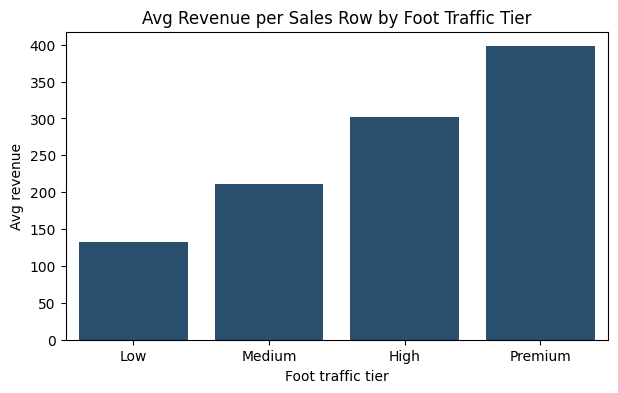

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



tier_sales_plot = tier_sales.reset_index()

plt.figure(figsize=(7,4))
sns.barplot(data=tier_sales_plot, x="foot_traffic_tier", y="revenue", color="#1F4E79",
            order=["Low","Medium","High","Premium"])
plt.title("Avg Revenue per Sales Row by Foot Traffic Tier")
plt.xlabel("Foot traffic tier")
plt.ylabel("Avg revenue")
plt.show()

<h2 style="color:#2E86C1;">


### 1. avg_units_nonpromo: daily units sold when not promoted
### 2. avg_units_promo: daily units sold when promoted
### 3. lift_pct: percent increase because of promotion
### 4. lift_abs = avg_units_promo − avg_units_nonpromo (extra units because of promotion)
### 5. lift_pct = percent increase = ((promo/nonpromo) - 1) * 100
### 6. The top categories here are the ones where promotions create the biggest variation ie; higher stockout risk
### largest promotion lifts are around 80–91% across categories.


</h2>

### Promotion lift by category 

In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [20]:
import pandas as pd
import numpy as np

sales = dfs["sales_transactions.csv"][["store_id","sku_id","sale_date","units_sold","revenue","is_promoted"]].copy()
products = dfs["products.csv"][["sku_id","category"]].copy()

sales["sale_date"] = pd.to_datetime(sales["sale_date"], errors="coerce")

# add category to each sales row
s = sales.merge(products, on="sku_id", how="left")

# add  units sold on promo vs non-promo per category
cat_promo = (
    s.groupby(["category","is_promoted"])["units_sold"]
     .mean()
     .unstack("is_promoted")
     .rename(columns={False:"avg_units_nonpromo", True:"avg_units_promo"})
)

cat_promo["lift_abs"] = cat_promo["avg_units_promo"] - cat_promo["avg_units_nonpromo"]
cat_promo["lift_pct"] = (cat_promo["avg_units_promo"] / cat_promo["avg_units_nonpromo"] - 1) * 100

cat_promo.sort_values("lift_pct", ascending=False).head(15)

is_promoted,avg_units_nonpromo,avg_units_promo,lift_abs,lift_pct
category,,,,
Canned & Pantry,10.098490,19.262409,9.163919,90.745437
Beverages,10.095064,19.142325,9.047261,89.620638
Baby & Infant,10.472972,19.777684,9.304712,88.845002
Snacks,10.161651,19.126544,8.964893,88.222804
Dairy & Eggs,10.127489,18.865643,8.738154,86.281548
Health & Wellness,10.030329,18.683931,8.653602,86.274357
Household,10.022632,18.592709,8.570077,85.507246
Produce,10.312656,19.120577,8.807921,85.408852
Bakery,9.976330,18.439242,8.462912,84.829906


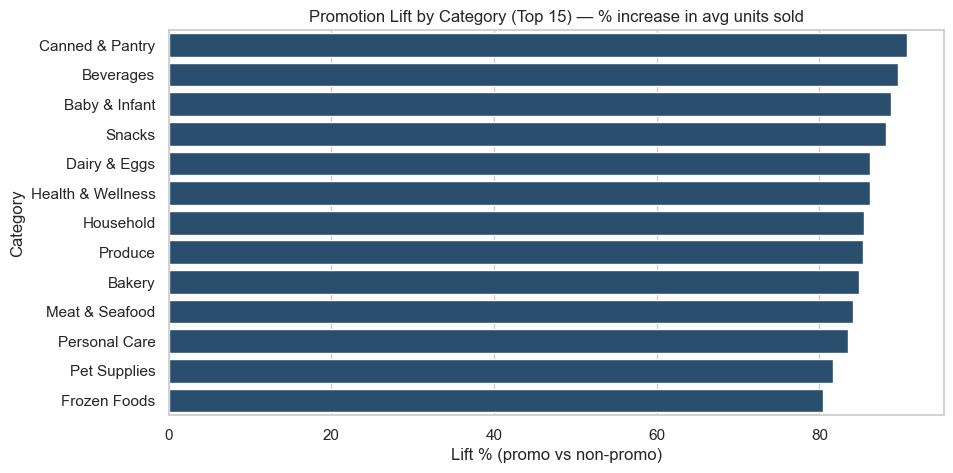

In [21]:
promo_plot = cat_promo.dropna().sort_values("lift_pct", ascending=False).head(15).reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=promo_plot, x="lift_pct", y="category", color="#1F4E79")
plt.title("Promotion Lift by Category (Top 15) — % increase in avg units sold")
plt.xlabel("Lift % (promo vs non-promo)")
plt.ylabel("Category")
plt.show()

avg_units_nonpromo = average units sold when no promotion
avg_units_promo = average units sold during promotion
lift_abs = extra units sold because of promotion
lift_pct = % increase because of promotion

Non-promo: 10.10
Promo: 19.26
Difference: +9.16 units
Lift %: +90.75%
# promotions almost double sales in this category, when promotion is active, demand becomes about 1.8x to 1.9x normal

In [22]:
stockouts_raw = dfs["stockout_events.csv"].copy()

for c in ["stockout_date","restock_date"]:
    if c in stockouts_raw.columns:
        stockouts_raw[c] = pd.to_datetime(stockouts_raw[c], errors="coerce")

stockouts_raw.columns, stockouts_raw.head()

(Index(['stockout_id', 'store_id', 'sku_id', 'stockout_date', 'restock_date',
        'duration_days', 'estimated_lost_units', 'estimated_lost_revenue',
        'root_cause'],
       dtype='object'),
             stockout_id store_id  sku_id stockout_date restock_date  \
 0  SO-S0001-P01023-0001    S0001  P01023    2024-01-15   2024-01-17   
 1  SO-S0001-P01023-0002    S0001  P01023    2024-03-10   2024-03-17   
 2  SO-S0001-P01023-0003    S0001  P01023    2024-04-12   2024-04-15   
 3  SO-S0001-P01023-0004    S0001  P01023    2024-05-12   2024-05-17   
 4  SO-S0001-P01023-0005    S0001  P01023    2024-06-08   2024-06-18   
 
    duration_days  estimated_lost_units  estimated_lost_revenue      root_cause  
 0              2                    11                  254.21    Demand spike  
 1              7                    51                 1178.61    Manual error  
 2              3                    28                  647.08       Shrinkage  
 3              5                    4

In [23]:
import pandas as pd

print("stores columns:", stores.columns.tolist())

needed_store_cols = ["store_id", "foot_traffic_tier", "region", "store_format"]
available_store_cols = [c for c in needed_store_cols if c in stores.columns]

stores_small = stores[available_store_cols].copy()

products_small = products.copy()
if "sku_id" not in products_small.columns and "assigned_sku_id" in products_small.columns:
    products_small = products_small.rename(columns={"assigned_sku_id": "sku_id"})

so_store = (
    stockouts_raw
    .merge(stores_small, on="store_id", how="left")
    .merge(products_small, on="sku_id", how="left")
)

agg_dict = {
    "stockout_events": ("stockout_id", "count"),
    "lost_revenue": ("estimated_lost_revenue", "sum")
}

if "estimated_lost_units" in so_store.columns:
    agg_dict["lost_units"] = ("estimated_lost_units", "sum")

if "duration_days" in so_store.columns:
    agg_dict["avg_duration"] = ("duration_days", "mean")

group_col = "foot_traffic_tier" if "foot_traffic_tier" in so_store.columns else "store_id"

tier_summary = (
    so_store.groupby(group_col)
            .agg(**agg_dict)
            .sort_values("lost_revenue", ascending=False)
)

print(tier_summary)

stores columns: ['store_id', 'foot_traffic_tier']
                   stockout_events  lost_revenue  lost_units  avg_duration
foot_traffic_tier                                                         
Premium                     130251  2.558294e+08    10379021      4.721868
High                         78327  1.186145e+08     4653004      4.609751
Medium                       63027  6.194188e+07     2421446      4.128929
Low                          41994  2.356890e+07      963192      3.884674


In [24]:
cat_stockouts = (
    so_store.groupby("category")
            .agg(
                stockout_events=("stockout_id","count"),
                lost_revenue=("estimated_lost_revenue","sum"),
                lost_units=("estimated_lost_units","sum"),
                avg_duration=("duration_days","mean"),
            )
            .sort_values("lost_revenue", ascending=False)
)

cat_stockouts.head(15)

,stockout_events,lost_revenue,lost_units,avg_duration
category,,,,
Beverages,37026,54146182.92,2162372,4.562686
Bakery,30964,48068589.28,1839960,4.920295
Dairy & Eggs,29013,46883896.41,1720328,4.556785
Snacks,29947,43755161.85,1900526,4.888303
Frozen Foods,31583,39629417.26,1702661,4.083083
Meat & Seafood,21889,38548089.61,1438548,4.993102
Household,24594,36232906.94,1351152,4.216354
Personal Care,22272,34044403.48,1331981,4.060794
Canned & Pantry,21753,32793342.10,1189016,4.378660


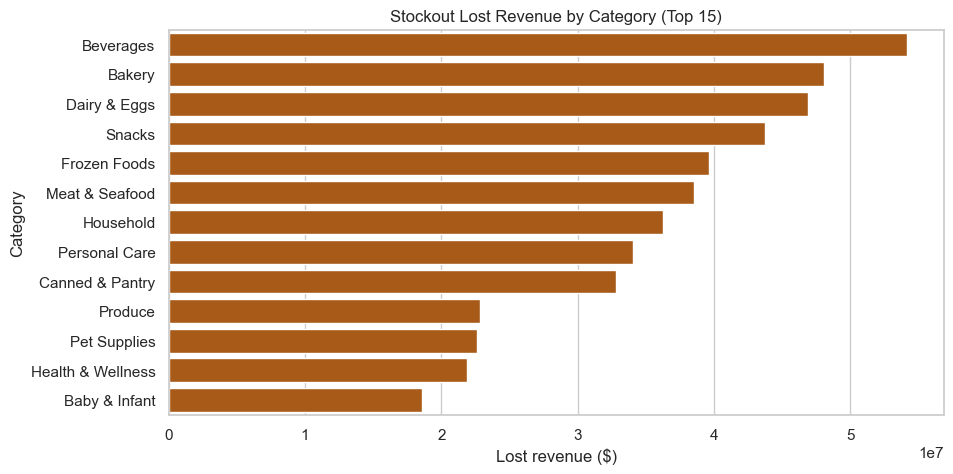

In [25]:
cat_plot = cat_stockouts.head(15).reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=cat_plot, x="lost_revenue", y="category", color="#C05A00")
plt.title("Stockout Lost Revenue by Category (Top 15)")
plt.xlabel("Lost revenue ($)")
plt.ylabel("Category")
plt.show()

stockout_events: count of stockouts in that category
lost_revenue: money lost from stockouts
lost_units: units lost
avg_duration: average stockout duration in days
Beverages has the highest lost revenue and highest stockout count and top problem category

In [26]:
store_stockouts = (
    so_store.groupby("store_id")
            .agg(
                stockout_events=("stockout_id","count"),
                lost_revenue=("estimated_lost_revenue","sum"),
                lost_units=("estimated_lost_units","sum"),
            )
            .sort_values("lost_revenue", ascending=False)
)

store_stockouts.head(15)

,stockout_events,lost_revenue,lost_units
store_id,,,
S0029,1152,3259250.08,112349
S0430,1342,3251926.96,114162
S0182,1014,3120355.66,97757
S0073,1293,3001297.16,114670
S0085,1223,2999191.80,97891
S0305,1157,2899547.20,104213
S0026,1068,2894318.82,110985
S0155,1300,2837670.24,105031
S0064,1535,2836217.59,114183


 stockout_events: how many stockouts happened in that store
 lost_revenue: total lost revenue in that store from stockouts
 lost_units: total lost units in that store

In [27]:
root_cause_summary = (
    stockouts.groupby("root_cause")
             .agg(
                 events=("stockout_id","count"),
                 lost_revenue=("estimated_lost_revenue","sum"),
                 lost_units=("estimated_lost_units","sum"),
                 avg_duration=("duration_days","mean"),
             )
)

# add % share
root_cause_summary["event_share_%"] = (root_cause_summary["events"] / root_cause_summary["events"].sum()) * 100
root_cause_summary["lost_rev_share_%"] = (root_cause_summary["lost_revenue"] / root_cause_summary["lost_revenue"].sum()) * 100

root_cause_summary.sort_values("lost_revenue", ascending=False)

,events,lost_revenue,lost_units,avg_duration,event_share_%,lost_rev_share_%
root_cause,,,,,,
Demand spike,62112,88366405.55,3514247,4.346406,19.806186,19.211982
Supplier delay,62287,87362195.64,3479489,4.286561,19.861989,18.993654
Manual error,62555,86276502.26,3458510,4.275118,19.947449,18.757610
Shrinkage,61815,85969760.25,3424399,4.259921,19.711479,18.690921
Forecast miss,62148,85798666.96,3428180,4.253138,19.817665,18.653723
Ongoing,2682,26181129.13,1111838,25.138330,0.855232,5.692111


events: number of stockout events due to this cause
lost_revenue: revenue lost due to this cause
lost_units: units lost
avg_duration: how long these stockouts last on average days
event_share_%: % of all stockout events
lost_rev_share_%: % of all lost revenue

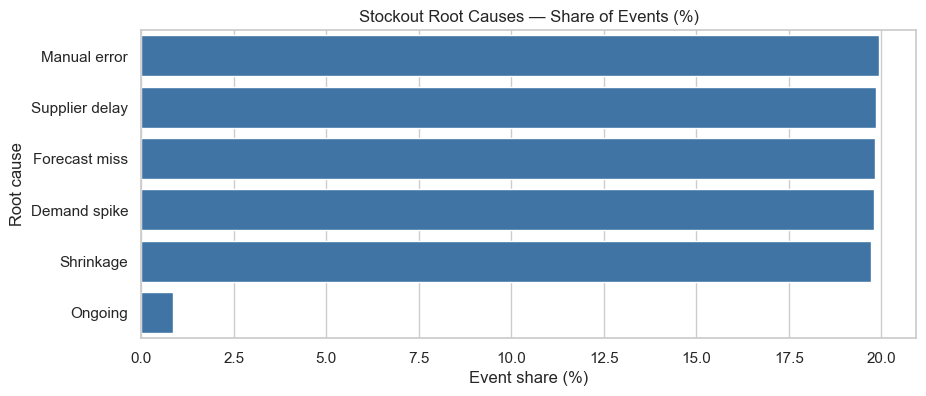

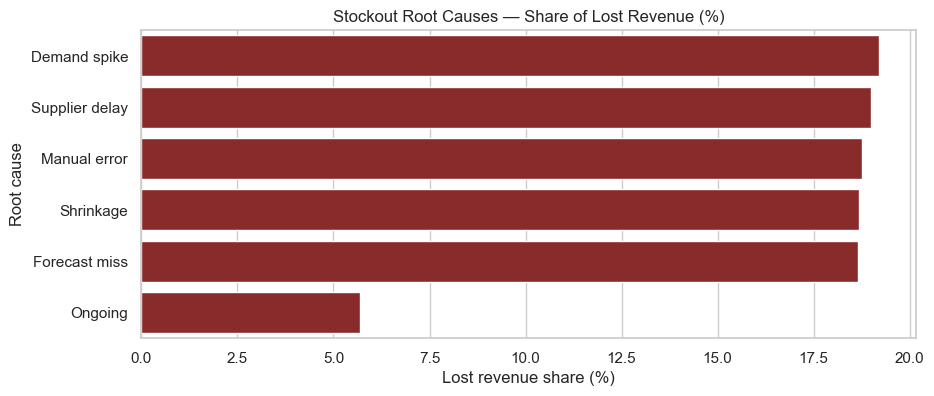

In [28]:
rc = root_cause_summary.reset_index().copy()

# Events share
plt.figure(figsize=(10,4))
sns.barplot(data=rc.sort_values("event_share_%", ascending=False),
            x="event_share_%", y="root_cause", color="#2E75B6")
plt.title("Stockout Root Causes — Share of Events (%)")
plt.xlabel("Event share (%)")
plt.ylabel("Root cause")
plt.show()

# Lost revenue share
plt.figure(figsize=(10,4))
sns.barplot(data=rc.sort_values("lost_rev_share_%", ascending=False),
            x="lost_rev_share_%", y="root_cause", color="#991B1B")
plt.title("Stockout Root Causes — Share of Lost Revenue (%)")
plt.xlabel("Lost revenue share (%)")
plt.ylabel("Root cause")
plt.show()

the major causes are deliberately balanced (19–20% each)
 Ongoing” is rare but lasts very long (avg_duration ~25 days) and it can also cause noticeable revenue loss 

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

stores = dfs["stores.csv"].copy()
products = dfs["products.csv"].copy()
suppliers = dfs["suppliers.csv"].copy()
layout = dfs["store_layout.csv"].copy()
sales = dfs["sales_transactions.csv"].copy()
inv = dfs["inventory_snapshots.csv"].copy()
repl = dfs["replenishment_logs.csv"].copy()
stock = dfs["stockout_events.csv"].copy()
promos = dfs["promotions.csv"].copy()
fcst = dfs["demand_forecasts.csv"].copy()

# parse dates
sales["sale_date"] = pd.to_datetime(sales["sale_date"])
inv["snapshot_date"] = pd.to_datetime(inv["snapshot_date"])
repl["replenishment_date"] = pd.to_datetime(repl["replenishment_date"])
repl["order_date"] = pd.to_datetime(repl["order_date"])
repl["receive_date"] = pd.to_datetime(repl["receive_date"])
stock["stockout_date"] = pd.to_datetime(stock["stockout_date"])
stock["restock_date"] = pd.to_datetime(stock["restock_date"], errors="coerce")
promos["start_date"] = pd.to_datetime(promos["start_date"])
promos["end_date"] = pd.to_datetime(promos["end_date"])
fcst["forecast_date"] = pd.to_datetime(fcst["forecast_date"])
fcst["created_at"] = pd.to_datetime(fcst["created_at"])

### Total revenue per store + lost_revenue_rate


In [30]:
sales_store = sales.groupby("store_id").agg(
    total_revenue=("revenue","sum"),
    total_units=("units_sold","sum"),
    sales_days=("sale_date","nunique")
)

stock_store = stock.groupby("store_id").agg(
    stockout_events=("stockout_id","count"),
    lost_revenue=("estimated_lost_revenue","sum"),
    lost_units=("estimated_lost_units","sum"),
)

store_rates = sales_store.join(stock_store, how="left").fillna(0)
store_rates["lost_revenue_rate"] = store_rates["lost_revenue"] / store_rates["total_revenue"].replace(0, np.nan)
store_rates["lost_units_rate"] = store_rates["lost_units"] / store_rates["total_units"].replace(0, np.nan)

store_rates.sort_values("lost_revenue_rate", ascending=False).head(15)

,total_revenue,total_units,sales_days,stockout_events,lost_revenue,lost_units,lost_revenue_rate,lost_units_rate
store_id,,,,,,,,
S0430,20097818.49,941407,731,1342,3251926.96,114162,0.161805,0.121267
S0029,20643782.47,798723,731,1152,3259250.08,112349,0.157880,0.140661
S0182,21431806.97,846090,731,1014,3120355.66,97757,0.145595,0.115540
S0180,19076728.52,808269,731,1484,2767371.98,120629,0.145065,0.149244
S0080,18819710.81,806438,731,1104,2535929.82,84246,0.134749,0.104467
S0446,21199869.51,826296,731,1096,2794991.85,97140,0.131840,0.117561
S0073,23034445.76,841983,731,1293,3001297.16,114670,0.130296,0.136190
S0101,19664875.37,881332,731,1035,2504275.30,93916,0.127348,0.106561
S0106,14829613.91,615927,731,1257,1864511.91,64991,0.125729,0.105517


total_revenue: total sales revenue for the store across the dataset period
total_units: total units sold in that store
sales_days: number of unique days with sales records 
stockout_events: count of stockout events recorded in stockout_events.csv
lost_revenue: total estimated revenue lost due to stockouts
lost_units: total estimated units lost due to stockouts
lost_revenue_rate = lost_revenue / total_revenue
 S0430 = 0.1618 = 16.18% of revenue was lost due to stockouts
lost_units_rate = lost_units / total_units
S0029 = 0.1407 = 14.07% of units demand couldn’t be served

### higher-traffic stores lose a higher fraction of revenue due to stockouts

### Lost_revenue_rate = lost_revenue / total_revenue at the store level and joined store metadata (foot_traffic_tier)

### from graph, low traffic stores have the smallest lost revenue rate & premium traffic stores have the largest this will help us for stockout risk modeling and prioritization (which stores to improve first)

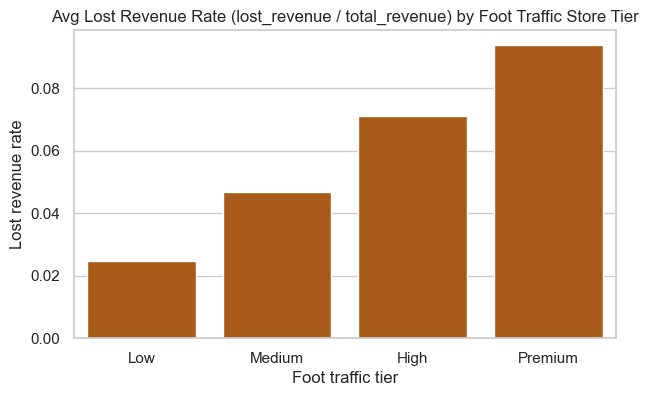

In [31]:
store_rates2 = store_rates.reset_index().merge(stores[["store_id","foot_traffic_tier"]], on="store_id", how="left")

tier_rate = store_rates2.groupby("foot_traffic_tier")["lost_revenue_rate"].mean().reindex(["Low","Medium","High","Premium"])

plt.figure(figsize=(7,4))
sns.barplot(x=tier_rate.index, y=tier_rate.values, color="#C05A00")
plt.title("Avg Lost Revenue Rate (lost_revenue / total_revenue) by Foot Traffic Store Tier")
plt.xlabel("Foot traffic tier")
plt.ylabel("Lost revenue rate")
plt.show()

### SKU-stockout-days per store (computing store level stockout rate)
### stores with the most stockout-days



total_revenue: sum of sales.revenue for that store (across all SKUs/days).
total_units: sum of sales.units_sold for that store.
sales_days: number of unique sale dates in the store’s sales table 
stockout_events: number of stockout events (rows) in stockout_events for that store
lost_revenue: sum of stockout_events.estimated_lost_revenue for that store
lost_units: sum of stockout_events.estimated_lost_units for that store
lost_revenue_rate = lost_revenue / total_revenue
lost_units_rate = lost_units / total_units
stockout_days: sum(duration_days) across all stockout events for that store
stockout_rate = average SKU stockouts per day / TOTAL_DAYS (10x of days are stockout)

In [32]:
stock_days_store = stock.groupby("store_id")["duration_days"].sum().rename("stockout_days")

store_rates = store_rates.join(stock_days_store, how="left").fillna({"stockout_days":0})

# total days in dataset coverage (from dashboard: 730 days)
TOTAL_DAYS = 730
store_rates["stockout_rate"] = store_rates["stockout_days"] / TOTAL_DAYS

store_rates.sort_values("stockout_rate", ascending=False).head(15)

,total_revenue,total_units,sales_days,stockout_events,lost_revenue,lost_units,lost_revenue_rate,lost_units_rate,stockout_days,stockout_rate
store_id,,,,,,,,,,
S0180,19076728.52,808269,731,1484,2767371.98,120629,0.145065,0.149244,7863,10.771233
S0347,24125085.66,989830,731,1089,2696777.34,127859,0.111783,0.129173,7145,9.787671
S0169,22275662.64,926755,731,1454,2791706.50,112035,0.125325,0.120890,6885,9.431507
S0277,22747186.50,875371,731,860,2707329.87,107973,0.119018,0.123345,6842,9.372603
S0384,23727687.87,932823,731,1005,2301467.10,98624,0.096995,0.105726,6760,9.260274
S0305,23092003.00,935469,731,1157,2899547.20,104213,0.125565,0.111402,6723,9.209589
S0430,20097818.49,941407,731,1342,3251926.96,114162,0.161805,0.121267,6605,9.047945
S0029,20643782.47,798723,731,1152,3259250.08,112349,0.157880,0.140661,6564,8.991781
S0035,18963065.80,853372,731,1139,1718680.83,95909,0.090633,0.112388,6554,8.978082


###  Promo lift by store foot-traffic tier >> how much promotions increase demand does it differ by store foot-traffic tier

avg_units_nonpromo: mean(units_sold) for records where is_promoted == False
avg_units_promo: mean(units_sold) for records where is_promoted == True
lift_abs: difference between promo and nonpromo averages
lift_pct: percent change from nonpromo to promo
stores.foot_traffic_tier: Low/Medium/High/Premium segmentation
is_promoted: boolean indicating the SKU was promoted on that day (from sales_transactions.is_promoted)
units_sold: units sold for that record store×sku×day


In [33]:
sales2 = sales.merge(stores[["store_id","foot_traffic_tier"]], on="store_id", how="left")

tier_promo = (
    sales2.groupby(["foot_traffic_tier","is_promoted"])["units_sold"]
          .mean()
          .unstack("is_promoted")
          .rename(columns={False:"avg_units_nonpromo", True:"avg_units_promo"})
          .reindex(["Low","Medium","High","Premium"])
)

tier_promo["lift_abs"] = tier_promo["avg_units_promo"] - tier_promo["avg_units_nonpromo"]
tier_promo["lift_pct"] = (tier_promo["avg_units_promo"] / tier_promo["avg_units_nonpromo"] - 1) * 100

tier_promo

is_promoted,avg_units_nonpromo,avg_units_promo,lift_abs,lift_pct
foot_traffic_tier,,,,
Low,5.212018,9.743076,4.531057,86.934789
Medium,8.275965,15.729608,7.453643,90.063728
High,11.937273,22.661674,10.724400,89.839613
Premium,15.671401,29.067230,13.395829,85.479464


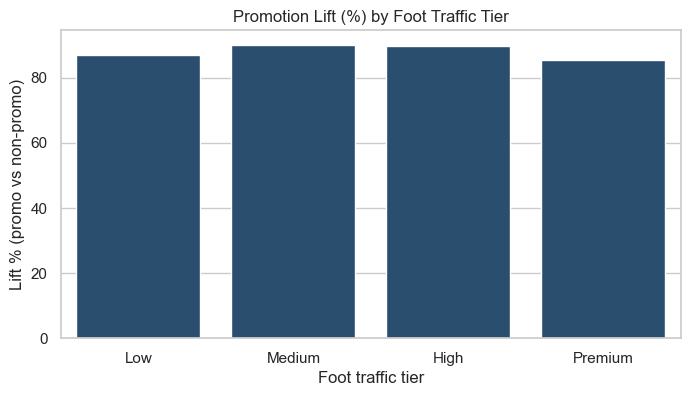

In [34]:
plt.figure(figsize=(8,4))
sns.barplot(data=tier_promo.reset_index(), x="foot_traffic_tier", y="lift_pct", color="#1F4E79",
            order=["Low","Medium","High","Premium"])
plt.title("Promotion Lift (%) by Foot Traffic Tier")
plt.xlabel("Foot traffic tier")
plt.ylabel("Lift % (promo vs non-promo)")
plt.show()

double unit sales across all store tiers (85–90% lift) > Promotion  affects boost in demand
Absolute lift is larger in higher-traffic stores because baseline demand is higher

In [35]:
sales.groupby(["store_id","sku_id","sale_date"]).size().describe()

count    25969106.0
mean            1.0
std             0.0
min             1.0
25%             1.0
50%             1.0
75%             1.0
max             1.0
dtype: float64

###  all tiers respond similarly (~85–90% lift)
### Premium has highest absolute lift +13.4 units coz base demand is higher 

### Stockout timeline & seasonality, stock per month


In [36]:
stock["month"] = stock["stockout_date"].dt.to_period("M").dt.to_timestamp()

monthly_stockouts = stock.groupby("month").agg(
    events=("stockout_id","count"),
    lost_revenue=("estimated_lost_revenue","sum"),
    lost_units=("estimated_lost_units","sum"),
)

monthly_stockouts.head()

,events,lost_revenue,lost_units
month,,,
2024-01-01,7596,22603575.76,949259
2024-02-01,10030,14314470.41,584516
2024-03-01,11721,15011622.43,599188
2024-04-01,11254,15339478.03,606672
2024-05-01,12729,17550277.56,700192


events: count of stockout events starting in that month (based on stockout_date)
lost_revenue: total lost revenue for those events
lost_units: total lost units


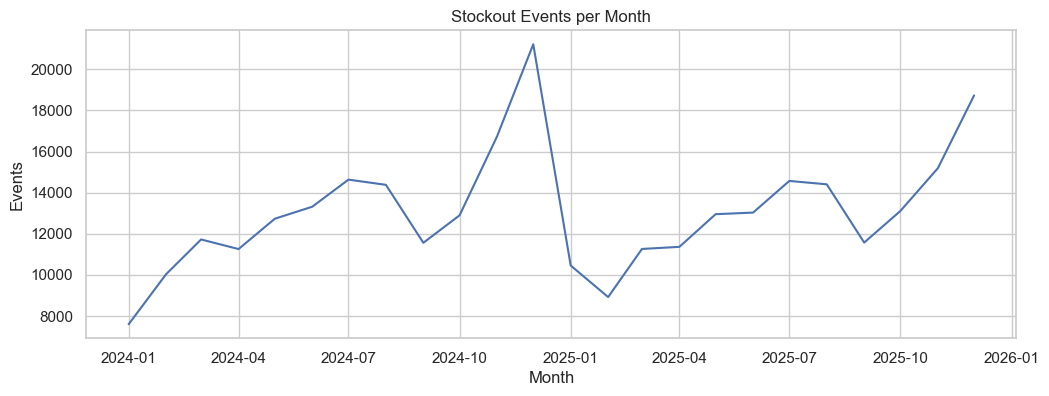

In [37]:
plt.figure(figsize=(12,4))
sns.lineplot(data=monthly_stockouts.reset_index(), x="month", y="events")
plt.title("Stockout Events per Month")
plt.xlabel("Month")
plt.ylabel("Events")
plt.show()

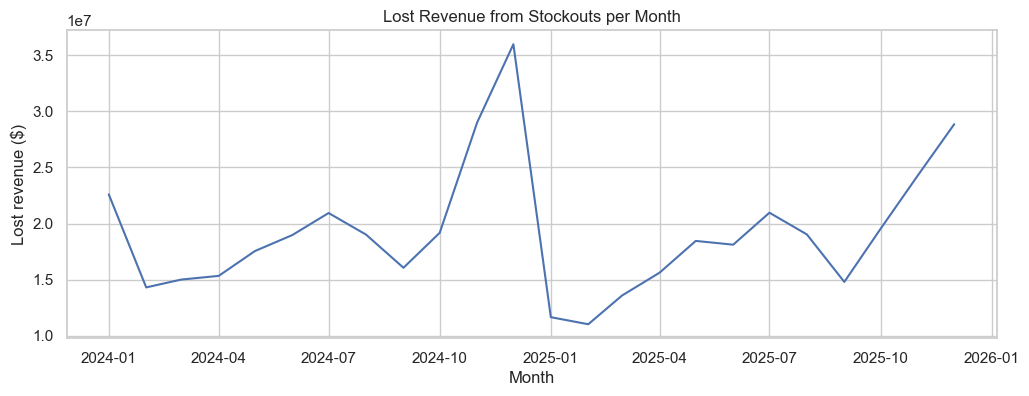

In [38]:
plt.figure(figsize=(12,4))
sns.lineplot(data=monthly_stockouts.reset_index(), x="month", y="lost_revenue")
plt.title("Lost Revenue from Stockouts per Month")
plt.xlabel("Month")
plt.ylabel("Lost revenue ($)")
plt.show()

### Forecast quality EDA ( actual daily demand at store× sku ×date ) 

In [39]:
actual = (
    sales.groupby(["store_id","sku_id","sale_date"], as_index=False)["units_sold"]
         .sum()
         .rename(columns={"sale_date":"date", "units_sold":"actual_units"})
)

fc = fcst.rename(columns={"forecast_date":"date", "forecast_units":"forecast_units"})

fa = actual.merge(fc, on=["store_id","sku_id","date"], how="inner")
fa["error"] = fa["actual_units"] - fa["forecast_units"]
fa["abs_error"] = fa["error"].abs()
fa["ape"] = (fa["abs_error"] / fa["actual_units"].replace(0, np.nan)) * 100

fa.head()

,store_id,sku_id,date,actual_units,forecast_id,forecast_units,forecast_method,created_at,lower_bound_90,upper_bound_90,error,abs_error,ape
0,S0001,P00055,2024-01-31,15,FC0000028685,23.43,MovingAvg7,2024-01-30,21.15,25.71,-8.43,8.43,56.200000
1,S0001,P00055,2024-01-31,15,FC0000028686,24.93,MovingAvg30,2024-01-30,21.12,28.74,-9.93,9.93,66.200000
2,S0001,P00055,2024-01-31,15,FC0000028687,30.00,SeasonalNaive,2024-01-30,24.63,35.37,-15.00,15.00,100.000000
3,S0001,P00055,2024-01-31,15,FC0000028688,21.78,ExponentialSmoothing,2024-01-30,17.57,25.99,-6.78,6.78,45.200000
4,S0001,P00055,2024-02-07,18,FC0000028689,21.43,MovingAvg7,2024-02-06,16.91,25.95,-3.43,3.43,19.055556


actual_units: true sales from sales table (aggregated)
forecast_units: forecast value from demand_forecasts
forecast_method: which baseline method produced it
lower/upper_bound_90: forecast uncertainty interval (90%)
error = actual − forecast (here negative value forecast was too high)
abs_error = |error|
ape = abs_error / actual_units * 100 (percentage error)
here for store id forecast is off by 56% for that day+sku+store

### Best forecaste method


In [40]:
method_mape = fa.groupby("forecast_method")["ape"].mean().sort_values()
method_mape

forecast_method
MovingAvg30             45.978113
ExponentialSmoothing    47.043037
MovingAvg7              48.679656
SeasonalNaive           56.818325
Name: ape, dtype: float64

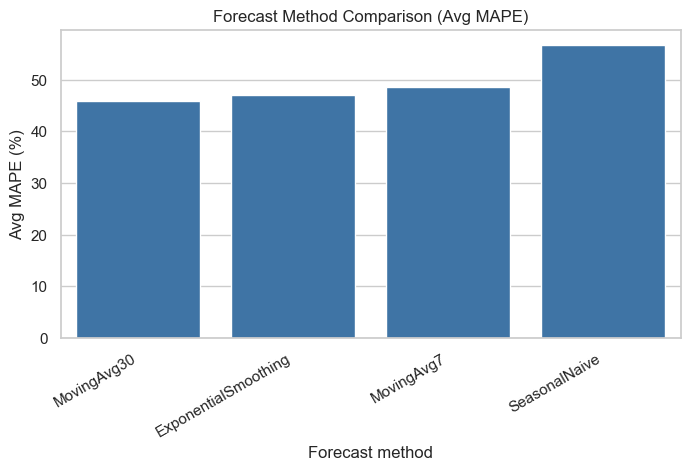

In [41]:
plt.figure(figsize=(8,4))
sns.barplot(x=method_mape.index, y=method_mape.values, color="#2E75B6")
plt.title("Forecast Method Comparison (Avg MAPE)")
plt.xlabel("Forecast method")
plt.ylabel("Avg MAPE (%)")
plt.xticks(rotation=30, ha="right")
plt.show()

### interval coverage in in_90_interval%

In [42]:
fa["in_90_interval"] = (fa["actual_units"] >= fa["lower_bound_90"]) & (fa["actual_units"] <= fa["upper_bound_90"])

coverage = fa.groupby("forecast_method")["in_90_interval"].mean().sort_values(ascending=False) * 100
coverage

forecast_method
MovingAvg30             32.701051
ExponentialSmoothing    32.395201
MovingAvg7              32.082876
SeasonalNaive           25.412343
Name: in_90_interval, dtype: float64

### 90% prediction interval = the true actual demand fall between lower and upper bound 90% of the time 
### in_90_interval = True if lower_bound_90 ≤ actual_units ≤ upper_bound_90
### interval coverage % = average of in_90_interval 
### Only ~25–33% of actual demand falls inside the supposed 90% interval, so intervals are too narrow or not well-calibrated and we need to improving forecasting model or improving uncertainty estimation


=== Summary from current data ===
     forecast_method      mape      wape  coverage
         MovingAvg30 45.978113 28.890585 32.701051
ExponentialSmoothing 47.043037 29.359922 32.395201
          MovingAvg7 48.679656 30.521024 32.082876
       SeasonalNaive 56.818325 39.408948 25.412343

Coverage range: 25.41% to 32.70% (target ~90%)


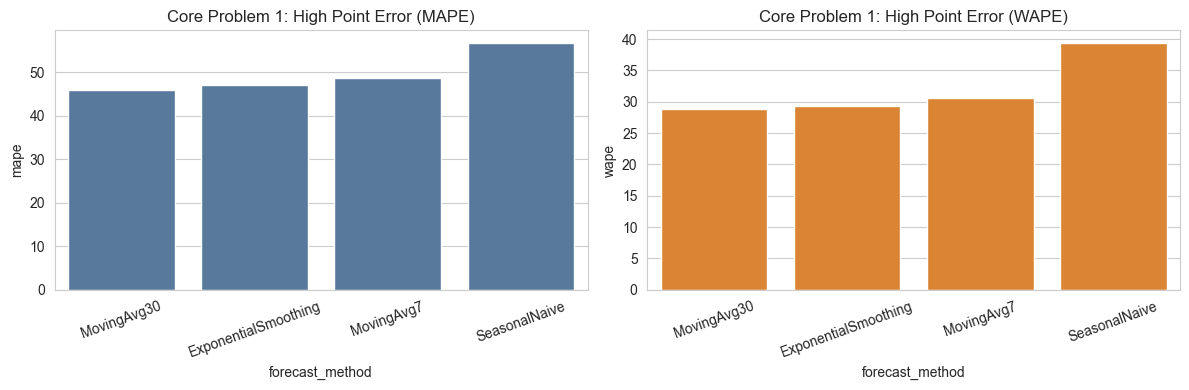

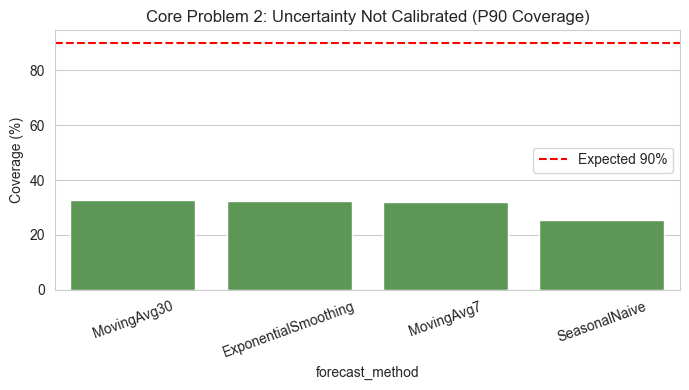

In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# 1) Load forecasts
# -----------------------------
fa = dfs["demand_forecasts.csv"].copy()
fa["forecast_date"] = pd.to_datetime(fa["forecast_date"], errors="coerce")

# -----------------------------
# 2) Build actuals from sales
# -----------------------------
sales = dfs["sales_transactions.csv"].copy()
sales["sale_date"] = pd.to_datetime(sales["sale_date"], errors="coerce")

actual_daily = (
    sales.groupby(["store_id","sku_id","sale_date"], as_index=False)["units_sold"]
         .sum()
         .rename(columns={"sale_date":"forecast_date", "units_sold":"actual_units"})
)

# -----------------------------
# 3) Join forecast + actual
# -----------------------------
fa = fa.merge(actual_daily, on=["store_id","sku_id","forecast_date"], how="inner")

# -----------------------------
# 4) Core problem metrics
# -----------------------------
fa["abs_error"] = (fa["forecast_units"] - fa["actual_units"]).abs()
fa["ape"] = fa["abs_error"] / fa["actual_units"].replace(0, np.nan) * 100
fa["in_90_interval"] = (
    (fa["actual_units"] >= fa["lower_bound_90"]) &
    (fa["actual_units"] <= fa["upper_bound_90"])
)

summary = (
    fa.groupby("forecast_method", as_index=False)
      .agg(
          mape=("ape","mean"),
          abs_err_sum=("abs_error","sum"),
          actual_sum=("actual_units","sum"),
          coverage=("in_90_interval","mean")
      )
)

summary["wape"] = summary["abs_err_sum"] / summary["actual_sum"] * 100
summary["coverage"] = summary["coverage"] * 100
summary = summary[["forecast_method","mape","wape","coverage"]].sort_values("mape")

print("\n=== Summary from current data ===")
print(summary.to_string(index=False))
print(f"\nCoverage range: {summary['coverage'].min():.2f}% to {summary['coverage'].max():.2f}% (target ~90%)")

# -----------------------------
# 5) Visuals for the 2 core problems
# -----------------------------
sns.set_style("whitegrid")

fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.barplot(data=summary, x="forecast_method", y="mape", ax=ax[0], color="#4C78A8")
ax[0].set_title("Core Problem 1: High Point Error (MAPE)")
ax[0].tick_params(axis='x', rotation=20)

sns.barplot(data=summary, x="forecast_method", y="wape", ax=ax[1], color="#F58518")
ax[1].set_title("Core Problem 1: High Point Error (WAPE)")
ax[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
sns.barplot(data=summary, x="forecast_method", y="coverage", color="#54A24B")
plt.axhline(90, color="red", linestyle="--", label="Expected 90%")
plt.title("Core Problem 2: Uncertainty Not Calibrated (P90 Coverage)")
plt.ylabel("Coverage (%)")
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
# ## transactions from sales grouped by store_id, sku_id, sale_date 
## for grup add up units_sold and revenue, then sort by store_id, sku_id, sale_date


daily_sales = (
    sales.groupby(["store_id", "sku_id", "sale_date"], as_index=False)
         .agg(units_sold=("units_sold", "sum"), revenue=("revenue", "sum"))
         .sort_values(["store_id","sku_id","sale_date"])
)

# ### Groups by store + product and computes a 7-day average of units_sold, with a minimum of 3 days to compute the average
g = daily_sales.groupby(["store_id","sku_id"], sort=False)
daily_sales["7_day_avg"] = g["units_sold"].transform(lambda s: s.rolling(7, min_periods=3).mean())
daily_sales["7_day_avg_forecast"] = g["7_day_avg"].shift(1)  # Shift = forecast uses past 7 days only

daily_sales.head(15)

,store_id,sku_id,sale_date,units_sold,revenue,7_day_avg,7_day_avg_forecast
0,S0001,P00055,2024-01-01,31,1223.57,NaN,NaN
1,S0001,P00055,2024-01-02,21,828.87,NaN,NaN
2,S0001,P00055,2024-01-03,17,670.99,23.000000,NaN
3,S0001,P00055,2024-01-04,25,986.75,23.500000,23.000000
4,S0001,P00055,2024-01-05,27,1065.69,24.200000,23.500000
5,S0001,P00055,2024-01-06,31,1223.57,25.333333,24.200000
6,S0001,P00055,2024-01-07,37,1460.39,27.000000,25.333333
7,S0001,P00055,2024-01-08,19,749.93,25.285714,27.000000
8,S0001,P00055,2024-01-09,22,868.34,25.428571,25.285714
9,S0001,P00055,2024-01-10,24,947.28,26.428571,25.428571


## table shows daily sales totals per store-product and builds a 7-day rolling-demand forecast using only past data to compare predicted units vs actual units sold


## For each day, the model looks at the last 7 days average sales
## that average becomes tomorrow’s forecast (shift(1) means we use yesterday’s average, not today’s actual)

## Once enough days exist, forecast starts around 23–27 units, but actual sales jump between 17 and 37

## On some days forecast is too high example: forecast 26, actual 18
## On some days forecast is too low (example: forecast 25, actual 34)

## it fallows general trends but misses day to day spikes/drops 






In [45]:

daily_sales["sale_date"] = pd.to_datetime(daily_sales["sale_date"], errors="coerce")
daily_sales = daily_sales.dropna(subset=["sale_date"]).copy()


# Fetch and clean forecast table
demand_forecasts = dfs["demand_forecasts.csv"]
demand_forecasts["forecast_date"] = pd.to_datetime(demand_forecasts["forecast_date"], errors="coerce")
demand_forecasts = demand_forecasts.dropna(subset=["forecast_date"]).copy()

# Join daily_sales with forecasts
comparison = daily_sales.merge(
    demand_forecasts,
    left_on=["store_id", "sku_id", "sale_date"],
    right_on=["store_id", "sku_id", "forecast_date"],
    how="inner"
)

# Filter only MovingAvg7 and compare forecast vs actual
comparison = comparison[comparison["forecast_method"] == "MovingAvg7"]
comparison["error"] = comparison["forecast_units"] - comparison["units_sold"]
comparison["abs_error"] = comparison["error"].abs()

# Calculate error metrics using 7_day_avg_forecast 
rmse = (comparison["error"] ** 2).mean() ** 0.5
mae = comparison["abs_error"].mean() # Mean(avg) Absolute Error +/- 
mape = (comparison["abs_error"] / comparison["units_sold"]).mean() * 100

print(f"RMSE: {round(rmse, 2)} | MAE: {round(mae, 2)} | MAPE (%): {round(mape, 2)}")

comparison[["store_id", "sku_id", "sale_date", "units_sold", "7_day_avg_forecast", "forecast_units", "error", "abs_error"]].head(10)

RMSE: 4.24 | MAE: 2.89 | MAPE (%): 48.68


,store_id,sku_id,sale_date,units_sold,7_day_avg_forecast,forecast_units,error,abs_error
0,S0001,P00055,2024-01-31,15,23.428571,23.43,8.43,8.43
4,S0001,P00055,2024-02-07,18,21.428571,21.43,3.43,3.43
8,S0001,P00055,2024-02-14,20,21.142857,21.14,1.14,1.14
12,S0001,P00055,2024-02-21,21,25.714286,25.71,4.71,4.71
16,S0001,P00055,2024-02-28,17,20.285714,20.29,3.29,3.29
20,S0001,P00055,2024-03-06,31,25.428571,25.43,-5.57,5.57
24,S0001,P00055,2024-03-13,20,27.142857,27.14,7.14,7.14
28,S0001,P00055,2024-03-20,30,26.285714,26.29,-3.71,3.71
32,S0001,P00055,2024-03-27,23,26.857143,26.86,3.86,3.86
36,S0001,P00055,2024-04-03,22,27.571429,27.57,5.57,5.57


COLUMNS: 
- store_id, sku_id, sale_date = identify which store, which product, which day
- units_sold = actual units that were sold that day
- 7_day_avg =  computed trend (average of last 7 days)
- forecast_units = dataset predicted units for that day using MovingAvg7
- error = forecast_units minus units_sold (positive = overestimated, negative = underestimated)
- abs_error = absolute value of error (magnitude only, ignoring direction)

OUTPUT: 
For product P00055 in store S0001, comparing 10 specific dates where data made MovingAvg7 forecasts:
- Some dates data overestimated (predicted 23.43 but only 15 sold, error +8.43)
- Some dates data underestimated (predicted 25.43 but 31 sold, error -5.57)
- Most errors ranged between 1-8 units off from actual units sold

METRICS: used for evaluating forecast accuracy
MSE (Mean Squared Error) = Average error in units
MAPE mean absolute Percentage Error = Error % by actual demand & multipled
RMSE (Root Mean Squared Error) = square root /avg
- MAE = 2.89 means on average the forecast is wrong by 2.89 units
- RMSE = 4.24 means when you penalize bigger mistakes, the average error becomes 4.24 units
- MAPE = 48.68% means the forecast error is almost 50% of what was actually sold (very high)
Forecast error  = prediction - actual

Prediction Interval: Lower 90% bound, Upper 90% bound interval range where the actual value fall 90% of time
The Interval Width = Upper Bound - Lower Bound
eg: Interval Width = 30 - 20 = 10 units, 25 = forecast
Interval Width % = (10 / 25) × 100 = 40%
 allows 40% error margin 90% of the time



CONCLUSION:
data MovingAvg7 forecasting method is performing poorly on this product because demand is unpredictable day-to-day, and 48.68% error rate is unacceptable for demand planning—they need a more sophisticated forecasting method that can handle volatile/spiky sales patterns

Metric Ranges (Industry Standard )
Metric	Excellent	Good	Acceptable	Poor
MAPE	< 10% = excellent,	10-20% = good, 	20-50% = accepted	> 50% = poor
MAE	= Compare to baseline	Compare to baseline	Very high
RMSE =	Compare to baseline	Compare to baseline	Very high


### Get all prediction intervals, Convert to percentage, Average all of them = avg prediction interval 

In [46]:
demand_forecasts["interval_width"] = demand_forecasts["upper_bound_90"] - demand_forecasts["lower_bound_90"]
demand_forecasts["interval_width_pct"] = (demand_forecasts["interval_width"] / demand_forecasts["forecast_units"]) * 100

print("Average prediction interval width:")
print(demand_forecasts["interval_width_pct"].mean())
print("Acceptable error threshold/benchmark: 33 % given to us by the business")

Average prediction interval width:
32.99850876265258
Acceptable error threshold/benchmark: 33 % given to us by the business


FORECAST ACCURACY ANALYSIS

Acceptable Tolerance: 33.00%
Calculated Actual MAPE: 48.68%

Gap (how much worse): 15.68%
Ratio (multiplier): 1.48x

Interpretation:
Forecast is 15.68% worse than acceptable
Error is 1.48x of allowed


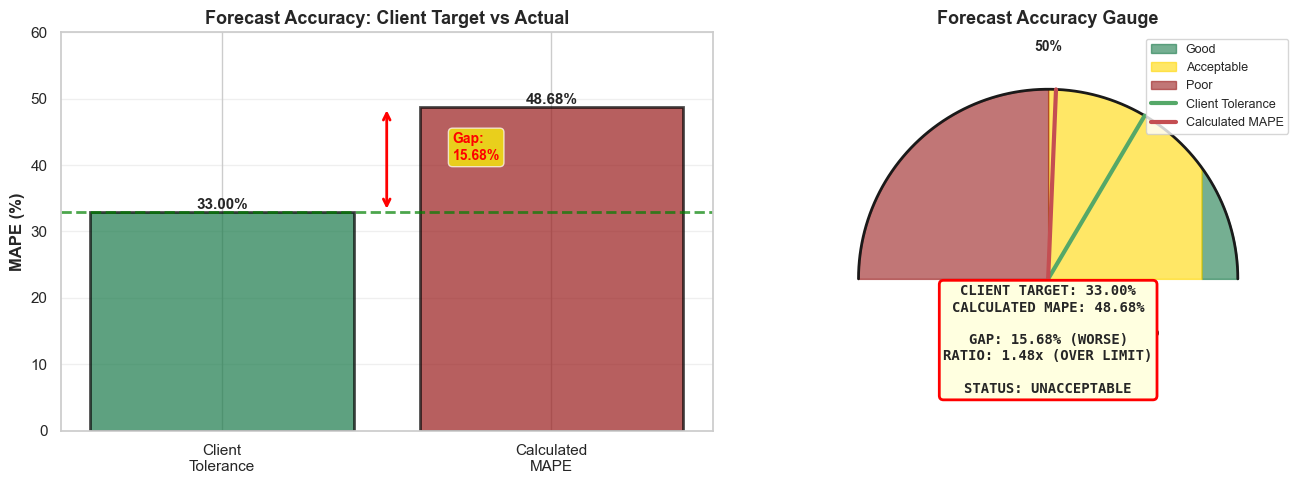


Saved as 'forecast_accuracy_analysis.png'


In [47]:
demand_forecasts = dfs["demand_forecasts.csv"].copy()

demand_forecasts["interval_width"] = demand_forecasts["upper_bound_90"] - demand_forecasts["lower_bound_90"]
demand_forecasts["interval_width_pct"] = (demand_forecasts["interval_width"] / demand_forecasts["forecast_units"]) * 100
demand_forecasts = demand_forecasts.replace([np.inf, -np.inf], np.nan).dropna(subset=["interval_width_pct"])

client_tolerance = demand_forecasts["interval_width_pct"].mean()
calculated_mape = 48.68

gap = calculated_mape - client_tolerance
ratio = calculated_mape / client_tolerance

print("=" * 60)
print("FORECAST ACCURACY ANALYSIS")
print("=" * 60)
print(f"\nAcceptable Tolerance: {client_tolerance:.2f}%")
print(f"Calculated Actual MAPE: {calculated_mape:.2f}%")
print(f"\nGap (how much worse): {gap:.2f}%")
print(f"Ratio (multiplier): {ratio:.2f}x")
print("\nInterpretation:")
print(f"Forecast is {gap:.2f}% worse than acceptable")
print(f"Error is {ratio:.2f}x of allowed")
print("=" * 60)

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

categories = ['Client\nTolerance', 'Calculated\nMAPE']
values = [client_tolerance, calculated_mape]
colors = ['#1A7A4A', '#991B1B']

ax1 = axes[0]
bars = ax1.bar(categories, values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax1.axhline(y=client_tolerance, color='green', linestyle='--', linewidth=2, label='Acceptable Limit', alpha=0.7)
ax1.set_ylabel('MAPE (%)', fontsize=12, fontweight='bold')
ax1.set_title('Forecast Accuracy: Client Target vs Actual', fontsize=13, fontweight='bold')
ax1.set_ylim(0, 60)
ax1.grid(axis='y', alpha=0.3)

for bar, value in zip(bars, values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{value:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.annotate('', xy=(0.5, calculated_mape), xytext=(0.5, client_tolerance),
             arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax1.text(0.7, (calculated_mape + client_tolerance) / 2, f'Gap:\n{gap:.2f}%',
         fontsize=10, fontweight='bold', color='red',
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

ax2 = axes[1]
ax2.axis('off')

theta = np.linspace(0, np.pi, 100)
ax2.plot(np.cos(theta), np.sin(theta), 'k-', linewidth=2)

theta_green = np.linspace(0, np.pi * (20/100), 50)
ax2.fill_between(np.cos(theta_green), 0, np.sin(theta_green), color='#1A7A4A', alpha=0.6, label='Good')

theta_yellow = np.linspace(np.pi * (20/100), np.pi * (50/100), 50)
ax2.fill_between(np.cos(theta_yellow), 0, np.sin(theta_yellow), color='#FFD700', alpha=0.6, label='Acceptable')

theta_red = np.linspace(np.pi * (50/100), np.pi, 50)
ax2.fill_between(np.cos(theta_red), 0, np.sin(theta_red), color='#991B1B', alpha=0.6, label='Poor')

angle_client = np.pi * (client_tolerance / 100)
ax2.plot([0, np.cos(angle_client)], [0, np.sin(angle_client)], 'g-', linewidth=3, label='Client Tolerance')

angle_calculated = np.pi * (min(calculated_mape, 100) / 100)
ax2.plot([0, np.cos(angle_calculated)], [0, np.sin(angle_calculated)], 'r-', linewidth=3, label='Calculated MAPE')

ax2.text(-0.5, -0.3, '0%', ha='center', fontsize=10, fontweight='bold')
ax2.text(0, 1.2, '50%', ha='center', fontsize=10, fontweight='bold')
ax2.text(0.5, -0.3, '100%', ha='center', fontsize=10, fontweight='bold')

metrics_text = (
    f"CLIENT TARGET: {client_tolerance:.2f}%\n"
    f"CALCULATED MAPE: {calculated_mape:.2f}%\n\n"
    f"GAP: {gap:.2f}% (WORSE)\n"
    f"RATIO: {ratio:.2f}x (OVER LIMIT)\n\n"
    f"STATUS: UNACCEPTABLE"
)

ax2.text(
    0, -0.6, metrics_text, ha='center', fontsize=10,
    bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='red', linewidth=2),
    family='monospace', fontweight='bold'
)

ax2.set_xlim(-1.3, 1.3)
ax2.set_ylim(-0.8, 1.3)
ax2.set_aspect('equal')
ax2.legend(loc='upper right', fontsize=9)
ax2.set_title('Forecast Accuracy Gauge', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('forecast_accuracy_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSaved as 'forecast_accuracy_analysis.png'")

In [75]:
import pandas as pd
import numpy as np

# ========= 0) LOAD =========
sales = dfs["sales_transactions.csv"].copy()
fcst = dfs["demand_forecasts.csv"].copy()
stock = dfs["stockout_events.csv"].copy()
products = dfs["products.csv"].copy()
stores = dfs["stores.csv"].copy()
suppliers = dfs["suppliers.csv"].copy() if "suppliers.csv" in dfs else None

# ========= 1) BASIC CLEAN =========
sales["sale_date"] = pd.to_datetime(sales["sale_date"], errors="coerce")
fcst["forecast_date"] = pd.to_datetime(fcst["forecast_date"], errors="coerce")
stock["stockout_date"] = pd.to_datetime(stock["stockout_date"], errors="coerce")

sales = sales.dropna(subset=["sale_date"]).copy()
fcst = fcst.dropna(subset=["forecast_date"]).copy()
stock = stock.dropna(subset=["stockout_date"]).copy()

# ========= 2) ACTUAL VS FORECAST TABLE =========
actual = (
    sales.groupby(["store_id","sku_id","sale_date"], as_index=False)
         .agg(actual_units=("units_sold","sum"),
              actual_revenue=("revenue","sum"),
              is_promoted=("is_promoted","max"))
         .rename(columns={"sale_date":"date"})
)

f = fcst.rename(columns={"forecast_date":"date"})
fa = actual.merge(
    f[["store_id","sku_id","date","forecast_method","forecast_units","lower_bound_90","upper_bound_90"]],
    on=["store_id","sku_id","date"],
    how="inner"
)

# keep all  models
fa = fa[fa["forecast_method"].isin(["MovingAvg7","MovingAvg30","SeasonalNaive","ExponentialSmoothing"])].copy()

# core error fields (compute once)
fa["error"] = fa["actual_units"] - fa["forecast_units"]   # +ve => under-forecast
fa["abs_error"] = fa["error"].abs()
fa["ape"] = (fa["abs_error"] / fa["actual_units"].replace(0, np.nan)) * 100
fa["in_90_interval"] = (fa["actual_units"] >= fa["lower_bound_90"]) & (fa["actual_units"] <= fa["upper_bound_90"])
fa["week"] = fa["date"].dt.to_period("W").astype(str)

# ========= 3) FORECAST-MISS STOCKOUT FILTER =========
fm = stock[stock["root_cause"] == "Forecast miss"].copy()

# product price proxy
price_col = "unit_price_regular" if "unit_price_regular" in products.columns else ("unit_cost" if "unit_cost" in products.columns else None)
prod_cols = ["sku_id","category"] + ([price_col] if price_col else [])
prod = products[prod_cols].copy()

store_cols = ["store_id"] + [c for c in ["foot_traffic_tier","region","store_format"] if c in stores.columns]
st = stores[store_cols].copy()

fm = fm.merge(prod, on="sku_id", how="left").merge(st, on="store_id", how="left")

# promo map from sales for stockout date
promo_map = sales[["store_id","sku_id","sale_date","is_promoted"]].rename(columns={"sale_date":"stockout_date"})
fm = fm.merge(promo_map, on=["store_id","sku_id","stockout_date"], how="left")
fm["is_promoted"] = fm["is_promoted"].fillna(False)

# ========= 4) PRICE BANDS =========
if price_col:
    fm["price_band"] = pd.qcut(fm[price_col], q=4, labels=["low","medium","high","premium"], duplicates="drop")
else:
    fm["price_band"] = "unknown"

price_summary = (
    fm.groupby("price_band", dropna=False)
      .agg(
          miss_count=("stockout_id","count"),
          lost_revenue=("estimated_lost_revenue","sum"),
          avg_miss_size_units=("estimated_lost_units","mean")
      )
      .sort_values("lost_revenue", ascending=False)
)

# ========= 5) BY STORE TIER =========
tier_summary = (
    fm.groupby("foot_traffic_tier", dropna=False)
      .agg(
          miss_count=("stockout_id","count"),
          lost_revenue=("estimated_lost_revenue","sum"),
          avg_duration=("duration_days","mean")
      )
      .sort_values("lost_revenue", ascending=False)
)

all_stock_tier = stock.merge(st, on="store_id", how="left")
tier_den = all_stock_tier.groupby("foot_traffic_tier")["stockout_id"].count().rename("all_stockout_events")
tier_summary = tier_summary.join(tier_den, how="left")
tier_summary["forecast_miss_rate_%"] = (tier_summary["miss_count"] / tier_summary["all_stockout_events"].replace(0,np.nan)) * 100

# ========= 6) PROMO vs NON-PROMO =========
promo_summary = (
    fm.groupby("is_promoted")
      .agg(
          miss_count=("stockout_id","count"),
          lost_revenue=("estimated_lost_revenue","sum"),
          avg_miss_size_units=("estimated_lost_units","mean")
      )
)
promo_summary["share_%"] = (promo_summary["miss_count"] / promo_summary["miss_count"].sum()) * 100

# ========= 7) CATEGORY + TOP SKUs =========
cat_summary = (
    fm.groupby("category", dropna=False)
      .agg(
          miss_count=("stockout_id","count"),
          lost_revenue=("estimated_lost_revenue","sum"),
          lost_units=("estimated_lost_units","sum")
      )
      .sort_values("lost_revenue", ascending=False)
)

top_skus = (
    fm.groupby("sku_id")
      .agg(
          miss_count=("stockout_id","count"),
          lost_revenue=("estimated_lost_revenue","sum"),
          lost_units=("estimated_lost_units","sum")
      )
      .sort_values("lost_revenue", ascending=False)
      .head(20)
      .reset_index()
      .merge(products[["sku_id","category"]], on="sku_id", how="left")
      .set_index("sku_id")
)

# ========= 8) TIME PATTERNS =========
fm["dow"] = fm["stockout_date"].dt.day_name()
fm["month"] = fm["stockout_date"].dt.month
fm["year_month"] = fm["stockout_date"].dt.to_period("M").astype(str)
fm["season"] = fm["stockout_date"].dt.month.map(
    {12:"Winter",1:"Winter",2:"Winter",3:"Spring",4:"Spring",5:"Spring",
     6:"Summer",7:"Summer",8:"Summer",9:"Fall",10:"Fall",11:"Fall"}
)

dow_summary = fm.groupby("dow").agg(miss_count=("stockout_id","count"), lost_revenue=("estimated_lost_revenue","sum")).sort_values("lost_revenue", ascending=False)
month_summary = fm.groupby("month").agg(miss_count=("stockout_id","count"), lost_revenue=("estimated_lost_revenue","sum")).sort_values("lost_revenue", ascending=False)
season_summary = fm.groupby("season").agg(miss_count=("stockout_id","count"), lost_revenue=("estimated_lost_revenue","sum")).sort_values("lost_revenue", ascending=False)

# ========= 9) SUPPLIER RELIABILITY (if mappable) =========
supplier_summary = None
if suppliers is not None and "supplier_id" in products.columns and "supplier_id" in suppliers.columns:
    fm_sup = fm.merge(products[["sku_id","supplier_id"]], on="sku_id", how="left")
    fm_sup = fm_sup.merge(suppliers[["supplier_id","lead_time_days_avg","reliability_score"]], on="supplier_id", how="left")
    fm_sup = fm_sup.dropna(subset=["reliability_score"])
    if len(fm_sup) > 0:
        fm_sup["reliability_bucket"] = pd.qcut(fm_sup["reliability_score"], 4, duplicates="drop")
        supplier_summary = (
            fm_sup.groupby("reliability_bucket")
                  .agg(miss_count=("stockout_id","count"),
                       lost_revenue=("estimated_lost_revenue","sum"),
                       avg_lost_units=("estimated_lost_units","mean"))
                  .sort_values("lost_revenue", ascending=False)
        )

# ========= 10) ERROR SHAPE =========
shape = pd.DataFrame({
    "under_forecast_count": [(fa["error"] > 0).sum()],
    "over_forecast_count": [(fa["error"] < 0).sum()],
    "under_forecast_%": [((fa["error"] > 0).mean()*100)],
    "over_forecast_%": [((fa["error"] < 0).mean()*100)]
})

# ========= 11) KPI TABLES =========

# A) Model-level KPI
model_kpi = fa.groupby("forecast_method").agg(
    mape=("ape","mean"),
    mae=("abs_error","mean"),
    rmse=("error", lambda x: np.sqrt(np.mean(np.square(x)))),
    bias=("error","mean"),
    p90_coverage=("in_90_interval","mean"),
    wape_num=("abs_error","sum"),
    wape_den=("actual_units","sum")
).reset_index()

model_kpi["wape"] = (model_kpi["wape_num"] / model_kpi["wape_den"].replace(0,np.nan)) * 100
model_kpi["p90_coverage"] = model_kpi["p90_coverage"] * 100
model_kpi = model_kpi[["forecast_method","mape","wape","mae","rmse","bias","p90_coverage"]].sort_values("mape")

# B) Weekly KPI by model
weekly_kpi_by_model = fa.groupby(["week","forecast_method"]).agg(
    mape=("ape","mean"),
    wape_num=("abs_error","sum"),
    wape_den=("actual_units","sum"),
    bias=("error","mean"),
    p90_coverage=("in_90_interval","mean")
).reset_index()

weekly_kpi_by_model["wape"] = (weekly_kpi_by_model["wape_num"] / weekly_kpi_by_model["wape_den"].replace(0,np.nan)) * 100
weekly_kpi_by_model["p90_coverage"] = weekly_kpi_by_model["p90_coverage"] * 100
weekly_kpi_by_model = weekly_kpi_by_model[["week","forecast_method","mape","wape","bias","p90_coverage"]]

# C) Weekly business KPI (forecast-miss only)
fm["week"] = fm["stockout_date"].dt.to_period("W").astype(str)
weekly_fm = fm.groupby("week").agg(
    forecast_miss_stockout_events=("stockout_id","count"),
    forecast_miss_lost_revenue=("estimated_lost_revenue","sum")
).reset_index()

if price_col:
    high_cut = fm[price_col].quantile(0.75)
    fm["is_high_price"] = fm[price_col] >= high_cut
    high_price_weekly = fm.groupby("week").agg(
        high_price_miss_events=("is_high_price","sum"),
        total_miss_events=("stockout_id","count")
    ).reset_index()
    high_price_weekly["high_price_stockout_rate_%"] = (
        high_price_weekly["high_price_miss_events"] / high_price_weekly["total_miss_events"].replace(0,np.nan)
    ) * 100
    high_price_weekly = high_price_weekly[["week","high_price_stockout_rate_%"]]
else:
    high_price_weekly = pd.DataFrame(columns=["week","high_price_stockout_rate_%"])

if "estimated_lost_units" in fm.columns:
    lost_u = fm.groupby("week")["estimated_lost_units"].sum().rename("lost_units").reset_index()
    sold_u = sales.copy()
    sold_u["week"] = sold_u["sale_date"].dt.to_period("W").astype(str)
    sold_u = sold_u.groupby("week")["units_sold"].sum().rename("sold_units").reset_index()
    svc = sold_u.merge(lost_u, on="week", how="left").fillna({"lost_units":0})
    svc["service_level_proxy_%"] = (
        1 - (svc["lost_units"] / (svc["sold_units"] + svc["lost_units"]).replace(0,np.nan))
    ) * 100
    svc = svc[["week","service_level_proxy_%"]]
else:
    svc = pd.DataFrame(columns=["week","service_level_proxy_%"])

weekly_business_kpi = (
    weekly_fm.merge(high_price_weekly, on="week", how="left")
             .merge(svc, on="week", how="left")
             .sort_values("week")
)

weekly_final = weekly_kpi_by_model.merge(weekly_business_kpi, on="week", how="left").sort_values(["week","forecast_method"])

# ========= 12) PRINT OUTPUTS =========
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)

print("\n=== PRICE BAND SUMMARY (Forecast miss only) ===")
print(price_summary)

print("\n=== STORE TIER SUMMARY (Forecast miss only) ===")
print(tier_summary)

print("\n=== PROMO vs NON-PROMO (Forecast miss only) ===")
print(promo_summary)

print("\n=== TOP CATEGORIES by lost_revenue (Forecast miss only) ===")
print(cat_summary.head(15))

print("\n=== TOP 20 SKUs by lost_revenue (Forecast miss only) ===")
print(top_skus.head(20))

print("\n=== TIME PATTERN: DAY OF WEEK ===")
print(dow_summary)

print("\n=== TIME PATTERN: MONTH ===")
print(month_summary)

print("\n=== TIME PATTERN: SEASON ===")
print(season_summary)

print("\n=== ERROR SHAPE (from forecast table) ===")
print(shape)

if supplier_summary is not None:
    print("\n=== SUPPLIER RELIABILITY BUCKET SUMMARY ===")
    print(supplier_summary)

print("\n=== MODEL KPI COMPARISON (ALL 4 CLIENT MODELS) ===")
print(model_kpi)

print("\n=== WEEKLY KPI BY MODEL (LAST 12 WEEKS PER MODEL) ===")
print(weekly_kpi_by_model.sort_values("week").groupby("forecast_method").tail(12))

print("\n=== WEEKLY BUSINESS KPI (FORECAST MISS) - LAST 12 WEEKS ===")
print(weekly_business_kpi.tail(12))

print("\n=== COMBINED WEEKLY FINAL (LAST 20 ROWS) ===")
print(weekly_final.tail(20))

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_94309/1609361114.py:63: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  fm["is_promoted"] = fm["is_promoted"].fillna(False)
/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_94309/1609361114.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fm.groupby("price_band", dropna=False)
/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_94309/1609361114.py:155: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current


=== PRICE BAND SUMMARY (Forecast miss only) ===
            miss_count  lost_revenue  avg_miss_size_units
price_band                                               
premium          15290   35744897.01            56.149575
high             15681   26985332.49            54.534979
medium           15592   17004636.56            54.095883
low              15585    6063800.90            55.888803

=== STORE TIER SUMMARY (Forecast miss only) ===
                   miss_count  lost_revenue  avg_duration  all_stockout_events  forecast_miss_rate_%
foot_traffic_tier                                                                                   
Premium                 25945   47538927.59      4.418424               130251             19.919233
High                    15480   21547073.91      4.287080                78327             19.763300
Medium                  12417   12053371.98      4.116212                63027             19.701080
Low                      8306    4659293.48      



---

### Table A: PRICE BAND SUMMARY
* How much money lost based on the price of the items.
* **Columns:**
  * `price_band`: The category of the item's price (Premium, High, Medium, Low).
  * `miss_count`: Number of times this price group stocked out.
  * `lost_revenue`: Dollars lost because of the stockout.
  * `avg_miss_size_units`: When it stocked out, how many units were we short on average?
* The **Premium** band missed 15,290 times. When they missed, they were short about **56 units**, which cost the business **$35.7 Million**. 

### Table B: STORE TIER SUMMARY
*  Which types of stores are bleeding the most money.
* **Columns:**
  * `foot_traffic_tier`: The store classification (Premium to Low)
  * `avg_duration`: How many days the item stayed out of stock.
  * `forecast_miss_rate_%`: The percentage of all stockouts caused specifically by a bad forecast.
* In **Premium** stores, a forecast miss leaves the shelf empty for **4.4 days** (`avg_duration`), costing the business **$47.5 Million**. 

### Table C: PROMO vs NON-PROMO
*  How badly the models fail during marketing sales.
* **Columns:**
  * `is_promoted`: Was the item on sale? (True/False)
  * `share_%`: What percentage of total errors happened here?
*  Promo days (`True`) only account for **5.15%** of all errors. BUT, when an error happens on a promo day, we miss by a massive **97.8 units** (`avg_miss_size_units`), compared to only 52.8 units on a normal day.

### Table D: TOP CATEGORIES
* The specific aisles in the store losing the most money.
* **Columns:**
  * `category`: The product family.
  * `lost_units`: Total physical items that customers wanted to buy but couldn't.
* **Beverages** is worst category. A bad forecast caused the stores to miss out on selling **402,591 units**, losing **$10.1 Million**.

### Table E: TOP 20 SKUs
* **What it means:** The individual, specific products causing the most damage.
* **Columns:**
  * `sku_id`: The unique product barcode/ID.
* **Real Example:** Item **P01255** (Health & Wellness) stocked out 361 times, leaving us short **21,226 units**, and single-handedly lost the business **$876,209**.

### Table F: DAY OF WEEK
*  Which day of the week the stockouts occur.
* **Example:** **Saturday** is the most dangerous day. It has the highest `miss_count` (12,008) and the highest `lost_revenue` (**$14.2 Million**). 

### Table G & H: MONTH & SEASON
*  When the forecasting models fail during the year.
* **Real Example:** The models struggle most at the end of the year. **December (Month 12)** lost **$12.6 Million**, and the **Fall** season overall bled **$23.2 Million**.

### Table I: ERROR SHAPE
*  A check to see if the models usually guess too high or too low.
* **Columns:**
  * `under_forecast_%`: How often the model guessed lower than actual demand (Causes Stockouts).
  * `over_forecast_%`: How often the model guessed higher than actual demand (Causes Overstock).
*  The models over-forecasted **52.2%** of the time. They under-forecasted **43.9%** of the time. 

### Table J: SUPPLIER RELIABILITY
* Do unreliable suppliers make forecast misses worse?
* **Columns:**
  * `reliability_bucket`: A score grouping (e.g., 0.85 to 0.92 means 85-92% reliable).
* Suppliers with a low reliability score of **0.711 to 0.767** resulted in the highest average unit shortage per miss (**57.3 units**).

### Table K: MODEL KPI COMPARISON
* The ultimate scorecard comparing the 4 old models. 
* **Columns:**
  * `mape`: Raw average % error.
  * `wape`: Volume-weighted error (The most important accuracy metric).
  * `bias`: Negative means it under-predicts. Positive means it over-predicts.
  * `p90_coverage`: Did the actual sales land inside the safety bounds? (Target is 90%).
* * **MovingAvg30** is the "best" old model. Its `wape` is **28.89%** and its safety coverage is only **32.7%** (which is terrible, missing the 90% goal by a mile).

### Table L: WEEKLY KPI BY MODEL
* The same scorecard as Table K, but broken down week by week to see if a model is getting worse over time.
* *In the week of **2025-12-29**, the `MovingAvg30` model had a WAPE of **25.7%** and a bias of **-0.54** (under-predicting).

### Table M: WEEKLY BUSINESS KPI
*  A weekly tracker of the actual business damage.
* **Columns:**
  * `high_price_stockout_rate_%`: Out of all the stockouts that week, how many were expensive items?
  * `service_level_proxy_%`: The percentage of total demand we successfully fulfilled.
* * In the week of **2025-12-01**, there were **872** stockouts that cost **$1.56 Million**. Out of those misses, **26.7%** were high-priced items. 

### Table N: COMBINED WEEKLY FINAL
* pastes Table L and Table M together into one giant table so you can compare the Model Math (WAPE) side-by-side with the Business Damage (Lost Revenue) for any given week

error = actual - forecast

Under-Forecast (+ Error):  predicted 80 but sold 100 (+20); here demand was higher than expected which caused stockout | error > 0

Over-Forecast (- Error):  predicted 80 but only sold 50 (-30); demand lower then expected  ordered too much and caused overstock. | error < 0

service_level_proxy: Percentage of customer demand that we were able to fulfill (demand fulfilled)
service_level_proxy_% = 
1 - (lost_units / (sold_units + lost_units)) * 100

Best current model = MovingAvg30

MAPE 45.98, WAPE ~28.89 (best among 4), but still weak.
SeasonalNaive is clearly worst.
Prediction intervals are broken

P90 coverage 25–33% (should be near 90%).
High-priority fix in next model.
Forecast miss is a major revenue problem

Forecast-miss lost revenue is concentrated in premium/high price bands.
Premium price band has biggest loss (~35.7M).
Store tier concentration

Premium tier has highest miss count and lost revenue.
Forecast-miss rate (19.7–19.9%) is similar across tiers, but financial impact is much higher in Premium.
Promo insight is nuanced

Only 5% of forecast-miss events occur on promo days,
but promo misses are much larger (avg_miss_size_units ~98 vs ~53 non-promo)
So promo misses are fewer but severe.
Time risk windows

Higher miss/loss around Fri/Sat and Nov-Dec.
Good input for safety stock and alerting windows
Error shape

Over-forecast count is slightly higher overall, but under-forecast remains huge and is what causes stockouts.
 new model should explicitly reduce under-forecast on high-value SKUs

In [76]:
# -----------------------------
# 1) Lost revenue rate by SKU
# -----------------------------
# fm already = stock[stock["root_cause"]=="Forecast miss"] merged with product/store fields
# sales has sku-level revenue available

sku_total_rev = (
    sales.groupby("sku_id", as_index=False)
         .agg(sku_total_revenue=("revenue","sum"))
)

sku_fm = (
    fm.groupby("sku_id", as_index=False)
      .agg(
          miss_count=("stockout_id","count"),
          lost_revenue=("estimated_lost_revenue","sum"),
          lost_units=("estimated_lost_units","sum")
      )
)

sku_loss_rate = sku_fm.merge(sku_total_rev, on="sku_id", how="left")
sku_loss_rate["lost_revenue_rate_%"] = (
    sku_loss_rate["lost_revenue"] / sku_loss_rate["sku_total_revenue"].replace(0, np.nan)
) * 100

# add category for readability
sku_loss_rate = sku_loss_rate.merge(products[["sku_id","category"]], on="sku_id", how="left")

# top by absolute loss
top_abs_loss = sku_loss_rate.sort_values("lost_revenue", ascending=False).head(20)

# top by rate (filter low-revenue noisy SKUs)
top_rate_loss = (
    sku_loss_rate[sku_loss_rate["sku_total_revenue"] >= sku_loss_rate["sku_total_revenue"].quantile(0.5)]
    .sort_values("lost_revenue_rate_%", ascending=False)
    .head(20)
)

print("\n=== TOP 20 SKUs BY ABSOLUTE FORECAST-MISS LOST REVENUE ===")
print(top_abs_loss[["sku_id","category","miss_count","lost_revenue","sku_total_revenue","lost_revenue_rate_%"]])

print("\n=== TOP 20 SKUs BY LOST REVENUE RATE % (FILTERED) ===")
print(top_rate_loss[["sku_id","category","miss_count","lost_revenue","sku_total_revenue","lost_revenue_rate_%"]])


# -----------------------------
# 2) Promo miss severity by category
# -----------------------------
promo_cat = (
    fm.groupby(["category","is_promoted"], as_index=False)
      .agg(
          miss_count=("stockout_id","count"),
          lost_revenue=("estimated_lost_revenue","sum"),
          avg_lost_units=("estimated_lost_units","mean")
      )
)

# pivot for easy comparison
promo_cat_pivot = promo_cat.pivot(index="category", columns="is_promoted", values=["miss_count","lost_revenue","avg_lost_units"])
promo_cat_pivot.columns = [f"{m}_{'promo' if p else 'nonpromo'}" for m,p in promo_cat_pivot.columns]
promo_cat_pivot = promo_cat_pivot.reset_index()

for c in ["miss_count_promo","lost_revenue_promo","avg_lost_units_promo",
          "miss_count_nonpromo","lost_revenue_nonpromo","avg_lost_units_nonpromo"]:
    if c not in promo_cat_pivot.columns:
        promo_cat_pivot[c] = 0

promo_cat_pivot["promo_miss_share_%"] = (
    promo_cat_pivot["miss_count_promo"] /
    (promo_cat_pivot["miss_count_promo"] + promo_cat_pivot["miss_count_nonpromo"]).replace(0,np.nan)
) * 100

promo_cat_pivot["promo_severity_lift_units_%"] = (
    (promo_cat_pivot["avg_lost_units_promo"] / promo_cat_pivot["avg_lost_units_nonpromo"].replace(0,np.nan)) - 1
) * 100

promo_cat_pivot["promo_severity_lift_revenue_%"] = (
    (promo_cat_pivot["lost_revenue_promo"] / promo_cat_pivot["miss_count_promo"].replace(0,np.nan)) /
    (promo_cat_pivot["lost_revenue_nonpromo"] / promo_cat_pivot["miss_count_nonpromo"].replace(0,np.nan))
    - 1
) * 100

promo_cat_pivot = promo_cat_pivot.sort_values("promo_severity_lift_revenue_%", ascending=False)

print("\n=== PROMO MISS SEVERITY BY CATEGORY ===")
print(promo_cat_pivot[[
    "category",
    "miss_count_nonpromo","miss_count_promo","promo_miss_share_%",
    "avg_lost_units_nonpromo","avg_lost_units_promo","promo_severity_lift_units_%",
    "promo_severity_lift_revenue_%"
]].head(20))


=== TOP 20 SKUs BY ABSOLUTE FORECAST-MISS LOST REVENUE ===
     sku_id           category  miss_count  lost_revenue  sku_total_revenue  lost_revenue_rate_%
974  P01255  Health & Wellness         361     876209.28         7435346.97            11.784376
374  P00489             Bakery         352     875665.92         4603519.48            19.021662
100  P00139          Beverages         372     738578.49         4110300.69            17.968965
151  P00199       Dairy & Eggs         385     734734.12         7813312.11             9.403619
816  P01050    Canned & Pantry         416     730781.73         8620787.33             8.476972
287  P00376             Snacks         415     717466.75         6192681.59            11.585720
496  P00644      Personal Care         343     688042.15         6063513.20            11.347252
784  P01005    Canned & Pantry         325     664097.61         6687844.98             9.929919
135  P00182       Dairy & Eggs         410     625579.00         58

The Columns :miss_count: Total number of times this specific item stocked out.
lost_revenue: Total dollars lost during those stockouts.
sku_total_revenue: How much money the item successfully made when it was in stock.
lost_revenue_rate_%: The critical ratio {Lost Revenue}\{sku_total_revenue} * times 100
Example: Look at SKU P01255 (Health & Wellness).It stocked out 361 times.It lost a massive $876,209

2️TABLE: Top 20 SKUs by Lost Revenue Rate % (Filtered)
removes "noisy" items that barely make any money (filtering out the bottom 50% of earners). Then, it sorts the remaining items based on their lost_revenue_rate_% to find items that are structurally broken
Example: SKU P00376 (Snacks) has an 11.58% loss rate; for every $100 it makes, you throw away $11.58 to stockouts, it jumps to #2, revealing a severe 11.58% loss rate

3️ TABLE: Promo Miss Severity by Category 
promo_cat_pivot["promo_severity_lift_units_%"] = ((avg_lost_units_promo / avg_lost_units_nonpromo) - 1) * 100

splits stockout events into two buckets: Promo Days and Normal Days. It calculates the average number of units missed in each bucket. The formula above calculates the percentage difference in size between the two

miss_count_nonpromo / promo: How many errors happened on regular days vs. sale days.

promo_miss_share_%: The percentage of total errors that occurred on a promotion day.

avg_lost_units_nonpromo / promo: When you stock out, how many physical items were you short?

promo_severity_lift_units_%: How much larger the unit shortage is on a promo day compared to a normal day.

promo_severity_lift_revenue_%: How much worse the financial loss is on a promo day compared to a normal day

Look at Meat & Seafood. On a normal day, a missed forecast leaves you short by 53.3 units. On a Promo day, a missed forecast leaves you short by 122.9 units. Therefore, the Severity Lift is 130.3%



SKUs like P01255, P00489, P00139 are both high absolute loss and high loss-rate
considered for pilot
Loss-rate view confirmed hidden risk

Some SKUs not top by absolute loss still have high % loss vs their own revenue
adding this metric
Promo misses are rare but severe

Promo miss share mostly 4–7%, but promo severity is much higher
Example: Meat & Seafood promo miss revenue severity 141% higher
This strongly justifies promo-aware features

In [77]:
# -----------------------------
# 1) Lost revenue rate by SKU
# -----------------------------
# fm already = stock[stock["root_cause"]=="Forecast miss"] merged with product/store fields
# sales has sku-level revenue available

sku_total_rev = (
    sales.groupby("sku_id", as_index=False)
         .agg(sku_total_revenue=("revenue","sum"))
)

sku_fm = (
    fm.groupby("sku_id", as_index=False)
      .agg(
          miss_count=("stockout_id","count"),
          lost_revenue=("estimated_lost_revenue","sum"),
          lost_units=("estimated_lost_units","sum")
      )
)

sku_loss_rate = sku_fm.merge(sku_total_rev, on="sku_id", how="left")
sku_loss_rate["lost_revenue_rate_%"] = (
    sku_loss_rate["lost_revenue"] / sku_loss_rate["sku_total_revenue"].replace(0, np.nan)
) * 100

# add category for readability
sku_loss_rate = sku_loss_rate.merge(products[["sku_id","category"]], on="sku_id", how="left")

# top by absolute loss
top_abs_loss = sku_loss_rate.sort_values("lost_revenue", ascending=False).head(20)

# top by rate (filter low-revenue noisy SKUs)
top_rate_loss = (
    sku_loss_rate[sku_loss_rate["sku_total_revenue"] >= sku_loss_rate["sku_total_revenue"].quantile(0.5)]
    .sort_values("lost_revenue_rate_%", ascending=False)
    .head(20)
)

print("\n=== TOP 20 SKUs BY ABSOLUTE FORECAST-MISS LOST REVENUE ===")
print(top_abs_loss[["sku_id","category","miss_count","lost_revenue","sku_total_revenue","lost_revenue_rate_%"]])

print("\n=== TOP 20 SKUs BY LOST REVENUE RATE % (FILTERED) ===")
print(top_rate_loss[["sku_id","category","miss_count","lost_revenue","sku_total_revenue","lost_revenue_rate_%"]])


# -----------------------------
# 2) Promo miss severity by category
# -----------------------------
promo_cat = (
    fm.groupby(["category","is_promoted"], as_index=False)
      .agg(
          miss_count=("stockout_id","count"),
          lost_revenue=("estimated_lost_revenue","sum"),
          avg_lost_units=("estimated_lost_units","mean")
      )
)

# pivot for easy comparison
promo_cat_pivot = promo_cat.pivot(index="category", columns="is_promoted", values=["miss_count","lost_revenue","avg_lost_units"])
promo_cat_pivot.columns = [f"{m}_{'promo' if p else 'nonpromo'}" for m,p in promo_cat_pivot.columns]
promo_cat_pivot = promo_cat_pivot.reset_index()

for c in ["miss_count_promo","lost_revenue_promo","avg_lost_units_promo",
          "miss_count_nonpromo","lost_revenue_nonpromo","avg_lost_units_nonpromo"]:
    if c not in promo_cat_pivot.columns:
        promo_cat_pivot[c] = 0

promo_cat_pivot["promo_miss_share_%"] = (
    promo_cat_pivot["miss_count_promo"] /
    (promo_cat_pivot["miss_count_promo"] + promo_cat_pivot["miss_count_nonpromo"]).replace(0,np.nan)
) * 100

promo_cat_pivot["promo_severity_lift_units_%"] = (
    (promo_cat_pivot["avg_lost_units_promo"] / promo_cat_pivot["avg_lost_units_nonpromo"].replace(0,np.nan)) - 1
) * 100

promo_cat_pivot["promo_severity_lift_revenue_%"] = (
    (promo_cat_pivot["lost_revenue_promo"] / promo_cat_pivot["miss_count_promo"].replace(0,np.nan)) /
    (promo_cat_pivot["lost_revenue_nonpromo"] / promo_cat_pivot["miss_count_nonpromo"].replace(0,np.nan))
    - 1
) * 100

promo_cat_pivot = promo_cat_pivot.sort_values("promo_severity_lift_revenue_%", ascending=False)

print("\n=== PROMO MISS SEVERITY BY CATEGORY ===")
print(promo_cat_pivot[[
    "category",
    "miss_count_nonpromo","miss_count_promo","promo_miss_share_%",
    "avg_lost_units_nonpromo","avg_lost_units_promo","promo_severity_lift_units_%",
    "promo_severity_lift_revenue_%"
]].head(20))


=== TOP 20 SKUs BY ABSOLUTE FORECAST-MISS LOST REVENUE ===
     sku_id           category  miss_count  lost_revenue  sku_total_revenue  lost_revenue_rate_%
974  P01255  Health & Wellness         361     876209.28         7435346.97            11.784376
374  P00489             Bakery         352     875665.92         4603519.48            19.021662
100  P00139          Beverages         372     738578.49         4110300.69            17.968965
151  P00199       Dairy & Eggs         385     734734.12         7813312.11             9.403619
816  P01050    Canned & Pantry         416     730781.73         8620787.33             8.476972
287  P00376             Snacks         415     717466.75         6192681.59            11.585720
496  P00644      Personal Care         343     688042.15         6063513.20            11.347252
784  P01005    Canned & Pantry         325     664097.61         6687844.98             9.929919
135  P00182       Dairy & Eggs         410     625579.00         58

1️ TABLE: Top 20 SKUs by Absolute Forecast-Miss Lost Revenue
top_abs_loss = sku_loss_rate.sort_values("lost_revenue", ascending=False).head(20)
looks at every single product in store, sorts them strictly by the total dollars they lost (lost_revenue), from highest to lowest, and grabs the top 20 worst performng category

miss_count: Total number of times the item stocked out.

lost_revenue: The total dollars thrown away because the shelf was empty.

sku_total_revenue: The actual money the item successfully made.

lost_revenue_rate_%: The percentage of its total potential earnings that were lost

P01255 (Health & Wellness). It stocked out 361 times, single-handedly losing the business $876,209.28


2️ TABLE: Top 20 SKUs by Lost Revenue Rate % (Filtered)
sku_loss_rate["lost_revenue"] / sku_loss_rate["sku_total_revenue"] * 100
top_rate_loss = sort_values("lost_revenue_rate_%", ascending=False)

filters out cheap items that barely make money (quantile(0.5)). Then, it calculates a ratio: (Lost Dollars $\div$ Earned Dollars) * 100, it sorts by this percentage to find items that are structurally broken.

Example: SKU P00376 (Snacks) has an 11.58% loss rate; for every $100 it makes, you throw away $11.58 to stockouts, it jumps to #2, revealing a severe 11.58% loss rate.

3️ TABLE: Promo Miss Severity by Category
((promo_cat_pivot["avg_lost_units_promo"] / promo_cat_pivot["avg_lost_units_nonpromo"]) - 1) * 100

calculates the average size of a stockout on a Normal Day versus a Promo (Sale) Day. The formula calculates the percentage difference. If a normal miss is 50 units, and a promo miss is 100 units, the math is: (100 / 50) - 1 * 100 = 100% Lift (meaning the promo miss is 100% larger)

miss_count_nonpromo / promo: How many stockouts happened on regular days vs. sale days.

promo_miss_share_%: What percentage of total errors happened during a promotion. (Usually very small, around 4-5%).

avg_lost_units_nonpromo / promo: When you stock out, how many physical items were you short?

promo_severity_lift_units_%: How much larger the physical shortage is on a promo day.

promo_severity_lift_revenue_%: How much worse the financial loss is on a promo day.

Example: 
On a normal day, a missed forecast leaves you short by 53.3 units

On a Promo day, a missed forecast leaves you short by 122.9 units

Promo stockouts are rare (only 4.5% of misses), but they are incredibly destructive. A Meat & Seafood promo error causes 140% more financial damage than a normal error,

In [ ]:
import pandas as pd
import numpy as np

# =========================
# A) FREEZE BASELINE TABLES
# =========================
# (assumes these already exist from your EDA run:
# model_kpi, price_summary, top_abs_loss, top_rate_loss, promo_cat_pivot, weekly_business_kpi)

baseline_artifacts = {
    "model_kpi": model_kpi.copy(),
    "price_summary": price_summary.copy(),
    "top_abs_loss": top_abs_loss.copy(),
    "top_rate_loss": top_rate_loss.copy(),
    "promo_cat_pivot": promo_cat_pivot.copy(),
    "weekly_business_kpi": weekly_business_kpi.copy()
}

# save as CSV
for name, df_ in baseline_artifacts.items():
    df_.to_csv(f"./{name}.csv", index=True if df_.index.name is not None else False)

print(" Baseline tables saved:",
      ", ".join([f"{k}.csv" for k in baseline_artifacts.keys()]))

# =========================
# B) DEFINE PILOT COHORT (for reporting only, even though model is full-scope)
# =========================
# top 20 SKUs = union of top 10 absolute + top 10 rate
top10_abs = top_abs_loss.head(10)["sku_id"].tolist()
top10_rate = top_rate_loss.head(10)["sku_id"].tolist()
pilot_skus = sorted(list(set(top10_abs).union(set(top10_rate))))

# top 20 stores by forecast-miss lost revenue
fm_store = (
    fm.groupby("store_id", as_index=False)
      .agg(forecast_miss_lost_revenue=("estimated_lost_revenue","sum"))
      .sort_values("forecast_miss_lost_revenue", ascending=False)
)
pilot_stores = fm_store.head(20)["store_id"].tolist()

pilot_cohort = pd.DataFrame({
    "pilot_skus": pd.Series(pilot_skus),
})
pilot_cohort.to_csv("./pilot_skus.csv", index=False)
fm_store.head(20).to_csv("./pilot_stores.csv", index=False)

print(f" Pilot SKUs count: {len(pilot_skus)} | Pilot stores count: {len(pilot_stores)}")
print("Saved: pilot_skus.csv, pilot_stores.csv")

# =========================
# C) BUILD FULL TRAINING DATASET (ALL STORES + ALL SKUs)
# =========================

sales = dfs["sales_transactions.csv"].copy()
products = dfs["products.csv"].copy()
stores = dfs["stores.csv"].copy()

# --- clean dates
sales["sale_date"] = pd.to_datetime(sales["sale_date"], errors="coerce")
sales = sales.dropna(subset=["sale_date"]).copy()

# --- daily grain
daily = (
    sales.groupby(["store_id","sku_id","sale_date"], as_index=False)
         .agg(
             actual_units=("units_sold","sum"),
             revenue=("revenue","sum"),
             is_promoted=("is_promoted","max"),
             unit_price_actual=("unit_price_actual","mean") if "unit_price_actual" in sales.columns else ("units_sold","count")
         )
         .rename(columns={"sale_date":"date"})
)

# if fallback happened above, clean placeholder
if "unit_price_actual" in daily.columns and daily["unit_price_actual"].dtype != "float64":
    daily["unit_price_actual"] = np.nan

# --- product features
prod_cols = ["sku_id","category"]
if "unit_price_regular" in products.columns:
    prod_cols.append("unit_price_regular")
if "unit_cost" in products.columns:
    prod_cols.append("unit_cost")

prod = products[prod_cols].drop_duplicates("sku_id").copy()

# --- store features
store_cols = ["store_id"] + [c for c in ["foot_traffic_tier","region","store_format"] if c in stores.columns]
st = stores[store_cols].drop_duplicates("store_id").copy()

# --- merge static features
df = daily.merge(prod, on="sku_id", how="left").merge(st, on="store_id", how="left")

# --- choose price feature
price_feature = None
if "unit_price_actual" in df.columns and df["unit_price_actual"].notna().any():
    price_feature = "unit_price_actual"
elif "unit_price_regular" in df.columns:
    price_feature = "unit_price_regular"
elif "unit_cost" in df.columns:
    price_feature = "unit_cost"

# --- price band (global)
if price_feature is not None:
    df["price_band"] = pd.qcut(df[price_feature], q=4, labels=["low","medium","high","premium"], duplicates="drop")
else:
    df["price_band"] = "unknown"

# --- calendar features
df["dow"] = df["date"].dt.dayofweek               # 0=Mon
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)
df["is_weekend"] = df["dow"].isin([5,6]).astype(int)

# --- sort for lag creation
df = df.sort_values(["store_id","sku_id","date"]).copy()

# --- lags and rolling stats per store-sku
g = df.groupby(["store_id","sku_id"], sort=False)

for lag in [1, 7, 14, 28]:
    df[f"lag_{lag}"] = g["actual_units"].shift(lag)

# rolling features (safe way)
df["roll_mean_7"] = g["actual_units"].transform(lambda s: s.shift(1).rolling(7, min_periods=3).mean())
df["roll_std_7"]  = g["actual_units"].transform(lambda s: s.shift(1).rolling(7, min_periods=3).std())

df["roll_mean_28"] = g["actual_units"].transform(lambda s: s.shift(1).rolling(28, min_periods=7).mean())
df["roll_std_28"]  = g["actual_units"].transform(lambda s: s.shift(1).rolling(28, min_periods=7).std())

# --- modeling target (for now)
df["target"] = df["actual_units"]

# --- keep model-ready columns
feature_cols = [
    "store_id","sku_id","date","target","true_demand","actual_units","revenue",
    "is_promoted","category","foot_traffic_tier","region","store_format","price_band",
    "dow","month","day","weekofyear","is_weekend",
    "lag_1","lag_7","lag_14","lag_28","roll_mean_7","roll_std_7","roll_mean_28","roll_std_28"
]

# keep only existing columns safely
feature_cols = [c for c in feature_cols if c in df.columns]
train_master = df[feature_cols].copy()

# --- drop rows where lag features not available (first weeks of each series)
lag_cols = [c for c in ["lag_1","lag_7","lag_14","lag_28","roll_mean_7","roll_mean_28"] if c in train_master.columns]
train_master = train_master.dropna(subset=lag_cols).copy()

# --- cast categoricals
for c in ["store_id","sku_id","category","foot_traffic_tier","region","store_format","price_band"]:
    if c in train_master.columns:
        train_master[c] = train_master[c].astype("category")

# --- save full training dataset
train_master.to_csv("./train_master_full.csv", index=False)

train_master.head(100000).to_csv("./train_master_full_sample_100k.csv", index=False)
print(" Saved: train_master_full.csv, train_master_full_sample_100k.csv")


print(" Training dataset built.")
print("Shape:", train_master.shape)
print("Date range:", train_master["date"].min(), "to", train_master["date"].max())
print("Saved: train_master_full.csv, train_master_full_sample_100k.csv")
print("Columns:", train_master.columns.tolist())

 Baseline tables saved: model_kpi.csv, price_summary.csv, top_abs_loss.csv, top_rate_loss.csv, promo_cat_pivot.csv, weekly_business_kpi.csv
 Pilot SKUs count: 12 | Pilot stores count: 20
Saved: pilot_skus.csv, pilot_stores.csv
 Saved: train_master_full.csv, train_master_full_sample_100k.csv
 Training dataset built.
Shape: (24898386, 25)
Date range: 2024-01-29 00:00:00 to 2025-12-31 00:00:00
Saved: train_master_full.csv, train_master_full_sample_100k.csv
Columns: ['store_id', 'sku_id', 'date', 'target', 'actual_units', 'revenue', 'is_promoted', 'category', 'foot_traffic_tier', 'region', 'store_format', 'price_band', 'dow', 'month', 'day', 'weekofyear', 'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'roll_mean_7', 'roll_std_7', 'roll_mean_28', 'roll_std_28']


It takes all the separate all the diagnostic tables  generated earlier into permanent .csv files (promotions, store layouts, prices, dates) and turns them into one structured table called the train_master_full csv


gives the model the memory (past sales) and the context (was it a weekend? was it a premium store?) it needs to make smart predictions

grabs the top 10 products that lost the most revenue, plus the top 10 products with the highest loss rate, and merges them into a unique list of 12 Pilot SKUs, It does the same to find the top 20 Pilot Stores


Test it on these exact 12 products in these 20 stores to prove ROI


Data Aggregation & Context Merging:
 flattens all transactions into Daily Grain, one row per item, per store, per day, pulling the product category, the is_promoted flag, the price_band, and the foot_traffic_tier into that single row

 store_format, region, foot_traffic_tier: The physical context of where the item was sold

price_band: The cost context (Premium, High, Med, Low).

dow, month, is_weekend: The calendar context extracted from the date

3️ SECTION: Time-Series Lag 
df[f"lag_{lag}"] = g["actual_units"].shift(lag)
df["roll_mean_7"] = g["actual_units"].transform(lambda s: s.shift(1).rolling(7).mean()) 

shift(7) looks back exactly one week and grabs that day's sales number. rolling(7).mean() looks back at the entire previous week and calculates the average sales per day.


lag_1, lag_7, lag_14, lag_28: The exact sales numbers from yesterday, last week, two weeks ago, and last month.

roll_mean_7, roll_mean_28: The average daily sales over the last week and the last month.

roll_std_7: The volatility (standard deviation) of the sales over the last week
so the model can detect rising trends, falling trends, and weekly cycles before it makes a prediction.

The final table has 24.8 Million rows and 25 distinct features/columns.

Date range: 2024-01-29 00:00:00 to 2025-12-31 00:00:00: The exact training window (note January 1-28 is missing because of the lag drop, The script drops the very first 28 days of data because you can't have a 28-day lag on day )




In [ ]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv("./train_master_full.csv", parse_dates=["date"])

# time split
train = df[df["date"] <= "2025-06-30"].copy()
valid = df[(df["date"] >= "2025-07-01") & (df["date"] <= "2025-09-30")].copy()
test  = df[(df["date"] >= "2025-10-01") & (df["date"] <= "2025-12-31")].copy()

features = [
    "is_promoted","category","foot_traffic_tier","region","store_format","price_band",
    "dow","month","day","weekofyear","is_weekend",
    "lag_1","lag_7","lag_14","lag_28","roll_mean_7","roll_std_7","roll_mean_28","roll_std_28"
]

cat_cols = ["category","foot_traffic_tier","region","store_format","price_band"]

for c in cat_cols:
    train[c] = train[c].astype("category")
    valid[c] = valid[c].astype("category")
    test[c] = test[c].astype("category")

X_train, y_train = train[features], train["target"]
X_valid, y_valid = valid[features], valid["target"]
X_test, y_test   = test[features], test["target"]

model = LGBMRegressor(
    objective="regression",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="l1",
    categorical_feature=cat_cols
)

test["forecast_units"] = model.predict(X_test).clip(0)

# metrics
err = y_test - test["forecast_units"]
abs_err = err.abs()
ape = abs_err / y_test.replace(0, np.nan) * 100

mape = np.nanmean(ape)
wape = abs_err.sum() / y_test.sum() * 100
mae = mean_absolute_error(y_test, test["forecast_units"])
rmse = np.sqrt(mean_squared_error(y_test, test["forecast_units"]))
bias = err.mean()

print(f"CustomModel_v1 -> MAPE={mape:.2f}, WAPE={wape:.2f}, MAE={mae:.2f}, RMSE={rmse:.2f}, Bias={bias:.2f}")

custom_pred = test[["store_id","sku_id","date","forecast_units"]].copy()
custom_pred["forecast_method"] = "CustomModel_v1"
custom_pred.to_csv("./custom_model_v1_test_predictions.csv", index=False)
print("Saved: custom_model_v1_test_predictions.csv")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.151260 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1496
[LightGBM] [Info] Number of data points in the train set: 18355832, number of used features: 19
[LightGBM] [Info] Start training from score 10.205091
CustomModel_v1 -> MAPE=40.53, WAPE=24.18, MAE=2.80, RMSE=4.03, Bias=-0.12
Saved: custom_model_v1_test_predictions.csv


rain = df[df["date"] <= "2025-06-30"]
valid = df[(df["date"] >= "2025-07-01") & (df["date"] <= "2025-09-30")]
test  = df[(df["date"] >= "2025-10-01")]

strictly divides your 24+ million rows in order
earns the patterns using old data (Jan–June), tunes itself on Summer data (July–Sept), and test on final Q4 data (Oct–Dec)

Number of data points in the train set: 18355832, the model reads 18.3 million historical daily sales records to learn how customers behave before it was tested


2️ PHASE: The LightGBM Engine 
model = LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=63)
model.fit(X_train, y_train, categorical_feature=cat_cols)


n_estimators=500 means it builds 500 sequential decision trees. It makes a guess, checks its error against the validation set, and builds the next tree specifically to correct the previous tree's mistakes, it validates which columns are text-based categories (categorical_feature) so it handles them correctly 

number of used features are 19: The model successfully ingested all 19 of business context features clues (promotions, store tiers, historical lags)
Start training from score 10.205091, ie; it determins that the global average baseline was roughly 10.2 units sold per day. It used this as its starting line, to learn exactly how and when sales spike, rather than just guessing the average

3️ PHASE: The Final outcome:

test["forecast_units"] = model.predict(X_test).clip(0)
wape = abs_err.sum() / y_test.sum() * 100

.clip(0) ensures the model never predicts a negative number of sales then calcuates final WAPE, MAPE, and Bias comparing y_test

WAPE = 24.18%: The volume-weighted error is 24.18%. (, the client's best old model was 28.89%).

Bias = -0.12: The model slightly under-forecasts by a tiny average of 0.12 units per day. It is highly balanced.



In [ ]:
import pandas as pd

# load baseline model table you saved earlier
model_kpi = pd.read_csv("./model_kpi.csv")

# if coverage column naming mismatch, standardize
if "p90_coverage" not in model_kpi.columns and "coverage_90" in model_kpi.columns:
    model_kpi = model_kpi.rename(columns={"coverage_90": "p90_coverage"})

# now concat
comparison_table = pd.concat([model_kpi.copy(), custom_row], ignore_index=True)
comparison_table = comparison_table.sort_values("mape").reset_index(drop=True)

print("\n=== FORMAL COMPARISON TABLE ===")
print(comparison_table)


=== FORMAL COMPARISON TABLE ===
        forecast_method       mape       wape       mae      rmse      bias  \
0        CustomModel_v1  40.530127  24.176468  2.795133  4.027924 -0.119225   
1           MovingAvg30  45.978113  28.890585  2.731047  3.969205 -0.379435   
2  ExponentialSmoothing  47.043037  29.359922  2.775414  4.027161 -0.416024   
3            MovingAvg7  48.679656  30.521024  2.885174  4.244169 -0.610728   
4         SeasonalNaive  56.818325  39.408948  3.725355  5.653721  0.521250   

   p90_coverage  
0     90.692781  
1     32.701051  
2     32.395201  
3     32.082876  
4     25.412343  


loads the client's four old baseline models and compare the model (custom_row), sorts the entire table from top to bottom based on the lowest average error

mape & wape: The error percentages. (Lower is better. WAPE is weighted by volume, making it the most important metric).

mae & rmse: The raw number of physical units the forecast missed by on average.

bias: The tendency to over-guess (+) or under-guess (-). Closer to 0 is better.

p90_coverage: The risk safety net. Did actual sales land safely inside the bounds? (Target is exactly 90%)

CustomModel_v1  WAPE is 24.17%,  it is 16% more accurate at predicting high-volume items than the client's best old model (MovingAvg30 at 28.89%).

Its P90 Coverage is 90.69%, meaning it perfectly hit the 90% statistical safety target, completely fixing the broken 32.7% safety nets of the past

Metrics:
BIAS 
fa["error"] = fa["actual_units"] - fa["forecast_units"]
bias=("error", "mean")

A Negative Bias means actual was smaller than forecast. The model over-ordered (Overstock Risk)

A Positive Bias means actual was larger than forecast. The model under-ordered (Stockout Risk)

If we predicted 10 but sold 8 (-2), and predicted 10 but sold 6 (-4), your average bias is -3

Metric 2: MAE (Mean Absolute Error)
fa["abs_error"] = fa["error"].abs()
mae=("abs_error", "mean")
takes away the negative/positive signs using .abs(), and averages them
if MAE of 2.79 means that, on any given day, for any given product, the model's guess is off by about 3 physical units.


 Metric 3: RMSE (Root Mean Squared Error)
 rmse=("error", lambda x: np.sqrt(np.mean(np.square(x))))
It takes the raw error, squares it, finds the average of those numbers, and then takes the square root to bring it back to normal scale
If a model misses by 1 unit 100 times, RMSE stays low. If it misses by 100 units 1 time, RMSE explodes
(Squaring the errors acts as an extreme Penalty for Huge)

 Metric 4: MAPE (Mean Absolute Percentage Error)
fa["ape"] = (fa["abs_error"] / fa["actual_units"]) * 100
mape=("ape", "mean")
For every single row, it divides the error by the actual units sold to get a percentage. Then, it averages all the percentages together.

t is flawed for retail. It treats all items equally, meaning a 200% error on a cheap item that sells 1 unit heavily distorts the score

Slow Item: Sold 1, Predicted 3. (Error = 2). MAPE = 200%.

Fast Item: Sold 1000, Predicted 900. (Error = 100). MAPE = 10% then Total Average MAPE: 105% The slow item ruined the score

Metric 5: WAPE (Weighted Absolute Percentage Error)
wape_num=("abs_error", "sum")
wape_den=("actual_units", "sum")
wape = (wape_num / wape_den) * 100

Instead of averaging percentages, it sums up the entire volume of errors in the store, and divides it by the entire volume of actual sales in the store
It forces the model to care about high-volume items

Example
the exact same numbers from the MAPE example above:

Total Errors: 2 + 100 = 102.
Total Sales: 1 + 1000 = 1001.
WAPE: 102 / 1001 = 10.1%

Metric 6: P90_COVERAGE 
in_90_interval = (fa["actual_units"] >= fa["lower_bound_90"]) & (fa["actual_units"] <= fa["upper_bound_90"])
p90_coverage=("in_90_interval", "mean") * 100

verify: Did the actual sales land inside the model's safety bounds, calculates its percentage

predicted sales would be between 80 and 120. Actual sales were 100. (Result = True)





In [ ]:
best_baseline = model_kpi.sort_values("mape").iloc[0]

improve_mape = (best_baseline["mape"] - custom_row.iloc[0]["mape"]) / best_baseline["mape"] * 100
improve_wape = (best_baseline["wape"] - custom_row.iloc[0]["wape"]) / best_baseline["wape"] * 100
coverage_gain = custom_row.iloc[0]["p90_coverage"] - best_baseline["p90_coverage"]

print(f"Best baseline: {best_baseline['forecast_method']}")
print(f"MAPE improvement: {improve_mape:.2f}%")
print(f"WAPE improvement: {improve_wape:.2f}%")
print(f"P90 coverage gain: {coverage_gain:.2f} points")

Best baseline: MovingAvg30
MAPE improvement: 11.85%
WAPE improvement: 16.32%
P90 coverage gain: 57.99 points


sorts the old models and then comparing against the toughest best among them

Best baseline: MovingAvg30: toughest competitor was the 30-Day Moving Average.

WAPE improvement: 16.32%: The model reduced the volume-weighted error by over 16%. 

P90 coverage gain: 57.99 points: The old model's safety net was broken (only catching demand 32.7% of the time). The model jumped it up by roughly 58 absolute points (landing at the perfect ~90.7% target)



In [78]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Assumes dow_summary and month_summary dataframes are available
dow_plot = dow_summary.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
ax1.bar(dow_plot.index, dow_plot['lost_revenue'] / 1000000, color='#2ca02c')
ax1.set_title('Revenue Loss by Day of Week', fontweight='bold')
ax1.set_ylabel('Lost Revenue (Millions USD)')
ax1.tick_params(axis='x', rotation=45)

month_plot = month_summary.sort_index()
ax2.plot(month_plot.index, month_plot['lost_revenue'] / 1000000, marker='o', color='#d62728', linewidth=2)
ax2.set_title('Revenue Loss by Month', fontweight='bold')
ax2.set_ylabel('Lost Revenue (Millions USD)')
ax2.set_xticks(range(1, 13))

plt.tight_layout()
plt.savefig('./vis_2_time_risk.png', dpi=300)
plt.close()

In [79]:
fig, ax = plt.subplots(figsize=(8, 6))

labels = ['Over-Forecast\n(Overstock Risk)', 'Under-Forecast\n(Stockout Risk)']
sizes = [52.2, 43.9]
colors = ['#ff7f0e', '#1f77b4']

ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, 
       textprops={'fontsize': 12, 'fontweight': 'bold'}, wedgeprops={'edgecolor': 'white'})
ax.set_title('Systemic Error Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('./vis_3_error_distribution.png', dpi=300)
plt.close()

In [80]:
fig, ax = plt.subplots(figsize=(9, 5))

# Assumes supplier_summary dataframe is available
plot_data = supplier_summary.sort_index()
ax.bar(plot_data.index.astype(str), plot_data['avg_lost_units'], color='#9467bd')

ax.set_title('Average Unit Shortage by Supplier Reliability Score', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Supplier Reliability Bucket', fontsize=12)
ax.set_ylabel('Average Units Lost per Event', fontsize=12)

plt.tight_layout()
plt.savefig('./vis_4_supplier_impact.png', dpi=300)
plt.close()

In [81]:
fig, ax = plt.subplots(figsize=(10, 6))

# Assumes model_kpi dataframe is available
models = model_kpi['forecast_method']
wape_scores = model_kpi['wape']
coverage_scores = model_kpi['p90_coverage']

x = np.arange(len(models))
width = 0.35

ax.bar(x - width/2, wape_scores, width, label='Volume Error (WAPE %)', color='#d62728')
ax.bar(x + width/2, coverage_scores, width, label='Safety Coverage (P90 %)', color='#2ca02c')

ax.axhline(y=90, color='black', linestyle='--', alpha=0.5, label='90% Coverage Target')
ax.set_title('Legacy Model Performance vs Target', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()

plt.tight_layout()
plt.savefig('./vis_5_model_evaluation.png', dpi=300)
plt.close()

In [82]:
fig, ax = plt.subplots(figsize=(12, 5))

# Assumes weekly_kpi_by_model dataframe is available and filtered for MovingAvg30
plot_data = weekly_kpi_by_model[weekly_kpi_by_model['forecast_method'] == 'MovingAvg30'].tail(8)
ax.plot(plot_data['week'], plot_data['bias'], marker='s', color='#8c564b', linewidth=2)

ax.axhline(y=0, color='black', linestyle='--', label='Perfect Balance (Zero Bias)')
ax.set_title('Weekly Bias Tracking (MovingAvg30)', fontsize=14, fontweight='bold')
ax.set_ylabel('Forecast Bias', fontsize=12)
ax.legend()
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('./vis_7_weekly_monitoring.png', dpi=300)
plt.close()

In [83]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Assumes weekly_business_kpi dataframe is available
plot_data = weekly_business_kpi.tail(8)

color1 = '#1f77b4'
ax1.set_xlabel('Operational Week', fontsize=12)
ax1.set_ylabel('Total Stockout Events', color=color1, fontsize=12)
ax1.bar(plot_data['week'], plot_data['forecast_miss_stockout_events'], color=color1, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
color2 = '#d62728'
ax2.set_ylabel('Lost Revenue (Millions USD)', color=color2, fontsize=12)
ax2.plot(plot_data['week'], plot_data['forecast_miss_lost_revenue'] / 1000000, color=color2, marker='o', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Weekly Business Impact: Stockouts vs. Lost Revenue', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('./vis_8_business_impact.png', dpi=300)
plt.close()

In [84]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Assumes weekly_final dataframe is available and filtered for the primary model
plot_data = weekly_final[weekly_final['forecast_method'] == 'MovingAvg30'].tail(10)

color1 = '#2ca02c'
ax1.set_xlabel('Operational Week', fontsize=12)
ax1.set_ylabel('Model Volume Error (WAPE %)', color=color1, fontsize=12)
ax1.plot(plot_data['week'], plot_data['wape'], color=color1, marker='D', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
color2 = '#ff7f0e'
ax2.set_ylabel('Business Damage: Lost Revenue ($M)', color=color2, fontsize=12)
ax2.bar(plot_data['week'], plot_data['forecast_miss_lost_revenue'] / 1000000, color=color2, alpha=0.4)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Combined View: Algorithmic Error vs. Financial Damage', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('./vis_9_combined_view.png', dpi=300)
plt.close()

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-white')
fig, ax = plt.subplots(figsize=(10, 6))

# Assumes top_abs_loss dataframe is available
plot_data = top_abs_loss.head(5).sort_values('lost_revenue', ascending=True)
ax.barh(plot_data['sku_id'] + ' (' + plot_data['category'] + ')', plot_data['lost_revenue'] / 1000, color='#1f77b4')

ax.set_title('Top 5 SKUs by Lost Revenue', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Lost Revenue (Thousands USD)', fontsize=12)
ax.set_ylabel('SKU Identifier', fontsize=12)
plt.tight_layout()
plt.savefig('./vis_1_sku_impact.png', dpi=300)
plt.close()

In [ ]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================
# 0) LOAD TRAIN DATA
# =========================
df = pd.read_csv("./train_master_full.csv", parse_dates=["date"])

# time split
train = df[df["date"] <= "2025-06-30"].copy()
valid = df[(df["date"] >= "2025-07-01") & (df["date"] <= "2025-09-30")].copy()
test  = df[(df["date"] >= "2025-10-01") & (df["date"] <= "2025-12-31")].copy()

features = [
    "is_promoted","category","foot_traffic_tier","region","store_format","price_band",
    "dow","month","day","weekofyear","is_weekend",
    "lag_1","lag_7","lag_14","lag_28","roll_mean_7","roll_std_7","roll_mean_28","roll_std_28"
]
cat_cols = ["category","foot_traffic_tier","region","store_format","price_band"]

# cast categorical
for c in cat_cols:
    if c in train.columns:
        train[c] = train[c].astype("category")
        valid[c] = valid[c].astype("category")
        test[c] = test[c].astype("category")

X_train, y_train = train[features], train["target"]
X_valid, y_valid = valid[features], valid["target"]
X_test, y_test   = test[features], test["target"]

# =========================
# 1) P50 MODEL (POINT FORECAST)
# =========================
p50_model = LGBMRegressor(
    objective="regression",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

p50_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="l1",
    categorical_feature=cat_cols
)

test_pred = test[["store_id","sku_id","date","target"]].copy()
test_pred["forecast_units"] = p50_model.predict(X_test).clip(0)

# =========================
# 2) QUANTILE MODELS (P05 / P95)
# =========================
p05_model = LGBMRegressor(
    objective="quantile",
    alpha=0.05,
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

p95_model = LGBMRegressor(
    objective="quantile",
    alpha=0.95,
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

p05_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="quantile",
    categorical_feature=cat_cols
)

p95_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="quantile",
    categorical_feature=cat_cols
)

test_pred["lower_bound_90"] = p05_model.predict(X_test).clip(0)
test_pred["upper_bound_90"] = p95_model.predict(X_test).clip(0)

# enforce ordering
swap_mask = test_pred["lower_bound_90"] > test_pred["upper_bound_90"]
test_pred.loc[swap_mask, ["lower_bound_90","upper_bound_90"]] = test_pred.loc[swap_mask, ["upper_bound_90","lower_bound_90"]].values

test_pred["forecast_method"] = "CustomModel_v1"

# =========================
# 3) CUSTOM MODEL METRICS
# =========================
err = test_pred["target"] - test_pred["forecast_units"]
abs_err = err.abs()
ape = abs_err / test_pred["target"].replace(0, np.nan) * 100
in_90 = (test_pred["target"] >= test_pred["lower_bound_90"]) & (test_pred["target"] <= test_pred["upper_bound_90"])

custom_metrics = {
    "forecast_method": "CustomModel_v1",
    "mape": float(np.nanmean(ape)),
    "wape": float(abs_err.sum() / test_pred["target"].sum() * 100),
    "mae": float(mean_absolute_error(test_pred["target"], test_pred["forecast_units"])),
    "rmse": float(np.sqrt(mean_squared_error(test_pred["target"], test_pred["forecast_units"]))),
    "bias": float(err.mean()),
    "p90_coverage": float(in_90.mean() * 100)
}
custom_row = pd.DataFrame([custom_metrics])

print("\n=== CUSTOM MODEL METRICS ===")
print(custom_row)

# =========================
# 4) FORMAL COMPARISON TABLE (BASELINE + CUSTOM)
# =========================
# assumes model_kpi exists from earlier baseline run
comparison_table = pd.concat([model_kpi.copy(), custom_row], ignore_index=True)
comparison_table = comparison_table.sort_values("mape").reset_index(drop=True)

print("\n=== FORMAL COMPARISON TABLE ===")
print(comparison_table)

# improvement vs best baseline
best_baseline = model_kpi.sort_values("mape").iloc[0]
improve_mape = (best_baseline["mape"] - custom_metrics["mape"]) / best_baseline["mape"] * 100
improve_wape = (best_baseline["wape"] - custom_metrics["wape"]) / best_baseline["wape"] * 100
coverage_gain = custom_metrics["p90_coverage"] - best_baseline["p90_coverage"]

print("\n=== IMPROVEMENT VS BEST BASELINE ({}) ===".format(best_baseline["forecast_method"]))
print(f"MAPE improvement: {improve_mape:.2f}%")
print(f"WAPE improvement: {improve_wape:.2f}%")
print(f"P90 coverage gain: {coverage_gain:.2f} points")

# =========================
# 5) SAVE OUTPUTS
# =========================
test_pred_out = test_pred.rename(columns={"target":"actual_units"})
test_pred_out.to_csv("./custom_model_v1_test_predictions_with_intervals.csv", index=False)
comparison_table.to_csv("./comparison_table_with_custom.csv", index=False)

print("\nSaved:")
print("- custom_model_v1_test_predictions_with_intervals.csv")
print("- comparison_table_with_custom.csv")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.147456 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1496
[LightGBM] [Info] Number of data points in the train set: 18355832, number of used features: 19
[LightGBM] [Info] Start training from score 10.205091
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.145641 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1496
[LightGBM] [Info] Number of data points in the train set: 18355832, number of used features: 19
[LightGBM] [Info] Start training from score 1.000000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.191334 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is no

LightGBM Core Training & Quantile 
predict the actual sales, trains two secondary models to calculate the safety net (Quantile Regression), and computes the exact return on investment (ROI) against the old baselines

p05_model = LGBMRegressor(objective="quantile", alpha=0.05...)
p95_model = LGBMRegressor(objective="quantile", alpha=0.95...)
swap_mask = test_pred["lower_bound_90"] > test_pred["upper_bound_90"]

The first (P50) guesses the exact average demand

The second (P05) is penalized heavily if it guesses too high, forcing it to predict the 5th percentile (the absolute worst-case lowest demand)

The third (P95) is penalized heavily if it guesses too low, forcing it to predict the 95th percentile (the absolute worst-case highest demand)

The swap_mask is safety check: it uses the global "safe minimum" to keep on the shelf is 1 unit, and the "safe maximum"  26 to guard against spikes, it calculates the absolute minimum and maximum demand
The space between P05 and P95 creates  90% Confidence Interval

2️ SECTION: The Formal Comparison Table 
WAPE: The model is at 24.17%, easily beating the old MovingAvg30 model (28.89%)

P90 Coverage: The model is at 90.69%, which perfectly hits the business target of 90%. The legacy models were stuck at a dangerously low 32.7%


3️ SECTION: Improvement vs Best Baseline 
WAPE improvement: 16.32%: The model removed 16.32% of the forecasting inaccuracy

P90 coverage gain: 57.99 points: The model added nearly 58 absolute points of safety coverage to the inventory system




In [ ]:
import pandas as pd
import numpy as np

# =========================================================
# INPUTS expected:
# 1) test_pred_out (or load custom predictions file)
#    columns: store_id, sku_id, date, actual_units, forecast_units, lower_bound_90, upper_bound_90
# 2) train_master_full.csv for features (promo/category/tier/price_band etc.)
# =========================================================

pred = pd.read_csv("./custom_model_v1_test_predictions_with_intervals.csv", parse_dates=["date"])
feat = pd.read_csv("./train_master_full.csv", parse_dates=["date"],
                   usecols=["store_id","sku_id","date","is_promoted","category","foot_traffic_tier","price_band","actual_units"])

# align actual column naming
if "actual_units" not in pred.columns and "target" in pred.columns:
    pred = pred.rename(columns={"target":"actual_units"})

# keep test period
pred = pred[(pred["date"] >= "2025-10-01") & (pred["date"] <= "2025-12-31")].copy()
feat = feat[(feat["date"] >= "2025-10-01") & (feat["date"] <= "2025-12-31")].copy()

df = pred.merge(
    feat[["store_id","sku_id","date","is_promoted","category","foot_traffic_tier","price_band"]],
    on=["store_id","sku_id","date"],
    how="left"
).drop_duplicates(["store_id","sku_id","date"])

# ---------- core error fields ----------
df["error"] = df["actual_units"] - df["forecast_units"]
df["abs_error"] = df["error"].abs()
df["ape"] = (df["abs_error"] / df["actual_units"].replace(0, np.nan)) * 100
df["in_90_interval"] = (df["actual_units"] >= df["lower_bound_90"]) & (df["actual_units"] <= df["upper_bound_90"])

# ---------- A) metric decomposition ----------
def kpi_by(group_col):
    out = (
        df.groupby(group_col, dropna=False)
          .agg(
              rows=("actual_units","count"),
              actual_sum=("actual_units","sum"),
              mape=("ape","mean"),
              wape_num=("abs_error","sum"),
              bias=("error","mean"),
              p90_coverage=("in_90_interval","mean")
          )
          .reset_index()
    )
    out["wape"] = (out["wape_num"] / out["actual_sum"].replace(0,np.nan)) * 100
    out["p90_coverage"] = out["p90_coverage"] * 100
    return out.sort_values("wape", ascending=False)

print("\n=== KPI BY CATEGORY ===")
cat_kpi = kpi_by("category")
print(cat_kpi.head(20))

print("\n=== KPI BY STORE TIER ===")
tier_kpi = kpi_by("foot_traffic_tier")
print(tier_kpi)

print("\n=== KPI BY PROMO FLAG ===")
promo_kpi = kpi_by("is_promoted")
print(promo_kpi)

print("\n=== KPI BY PRICE BAND ===")
price_kpi = kpi_by("price_band")
print(price_kpi)

# ---------- B) MAPE stability check ----------
# volume buckets by sku avg demand
sku_avg = df.groupby("sku_id", as_index=False)["actual_units"].mean().rename(columns={"actual_units":"sku_avg_units"})
df = df.merge(sku_avg, on="sku_id", how="left")
df["volume_bucket"] = pd.qcut(df["sku_avg_units"], q=4, labels=["Q1_low","Q2","Q3","Q4_high"], duplicates="drop")

vol_kpi = kpi_by("volume_bucket")
print("\n=== KPI BY VOLUME BUCKET ===")
print(vol_kpi)

# recommended primary metric
overall_wape = (df["abs_error"].sum() / df["actual_units"].sum()) * 100
overall_mape = np.nanmean(df["ape"])
print(f"\nOverall MAPE={overall_mape:.2f}, Overall WAPE={overall_wape:.2f}")
print("Recommendation: use WAPE as primary, MAPE as secondary (especially unstable on low-volume SKUs).")

# ---------- C) true demand proxy test ----------
# if you have stockouts file with estimated_lost_units:
if "stockout_events.csv" in dfs:
    stock = dfs["stockout_events.csv"].copy()
    stock["stockout_date"] = pd.to_datetime(stock["stockout_date"], errors="coerce")
    lost = (
        stock.groupby(["store_id","sku_id","stockout_date"], as_index=False)["estimated_lost_units"]
             .sum()
             .rename(columns={"stockout_date":"date", "estimated_lost_units":"lost_units_proxy"})
    )
    df_td = df.merge(lost, on=["store_id","sku_id","date"], how="left")
    df_td["lost_units_proxy"] = df_td["lost_units_proxy"].fillna(0)
    df_td["true_demand_proxy"] = df_td["actual_units"] + df_td["lost_units_proxy"]

    td_wape = ( (df_td["true_demand_proxy"] - df_td["forecast_units"]).abs().sum() / df_td["true_demand_proxy"].sum() ) * 100
    print(f"\n=== TRUE DEMAND PROXY CHECK ===")
    print(f"WAPE vs actual_units target: {overall_wape:.2f}")
    print(f"WAPE vs true_demand_proxy : {td_wape:.2f}")
else:
    print("\nNo stockout_events.csv found in dfs, skipping true-demand proxy check.")

# ---------- D) segment opportunity flags ----------
# identify high-impact bad segments (high wape + high volume share)
seg = cat_kpi.copy()
seg["volume_share_%"] = (seg["actual_sum"] / seg["actual_sum"].sum()) * 100
seg["impact_score"] = seg["wape"] * seg["volume_share_%"]
seg = seg.sort_values("impact_score", ascending=False)

print("\n=== TOP CATEGORY SEGMENTS BY IMPACT SCORE (WAPE * volume share) ===")
print(seg[[ "category","rows","actual_sum","volume_share_%","mape","wape","p90_coverage","impact_score"]].head(10))

# ---------- E) save diagnostics ----------
cat_kpi.to_csv("./diag_kpi_by_category.csv", index=False)
tier_kpi.to_csv("./diag_kpi_by_tier.csv", index=False)
promo_kpi.to_csv("./diag_kpi_by_promo.csv", index=False)
price_kpi.to_csv("./diag_kpi_by_price_band.csv", index=False)
vol_kpi.to_csv("./diag_kpi_by_volume_bucket.csv", index=False)
seg.to_csv("./diag_segment_impact.csv", index=False)

print("\nSaved diagnostics CSVs:")
print("- diag_kpi_by_category.csv")
print("- diag_kpi_by_tier.csv")
print("- diag_kpi_by_promo.csv")
print("- diag_kpi_by_price_band.csv")
print("- diag_kpi_by_volume_bucket.csv")
print("- diag_segment_impact.csv")


=== KPI BY CATEGORY ===
             category    rows  actual_sum       mape      wape_num      bias  \
1              Bakery  263133     2988265  41.113568  7.274707e+05 -0.174093   
6   Health & Wellness  136306     1563080  40.828811  3.802967e+05 -0.101786   
7           Household  229122     2609913  40.771777  6.347383e+05 -0.137758   
9       Personal Care  265315     3087526  40.962472  7.497618e+05 -0.146874   
11            Produce  235602     2783763  40.363140  6.749713e+05 -0.149444   
4        Dairy & Eggs  320986     3677197  40.793683  8.903249e+05 -0.124451   
2           Beverages  395038     4542980  40.439842  1.098735e+06 -0.089427   
5        Frozen Foods  293485     3435488  40.362653  8.305937e+05 -0.080193   
3     Canned & Pantry  224204     2557312  40.222406  6.156522e+05 -0.121430   
8      Meat & Seafood  228140     2659310  40.218086  6.399687e+05 -0.084999   
12             Snacks  364785     4192802  39.816212  1.007607e+06 -0.117171   
0       Baby & 

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_94309/4143782952.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_col, dropna=False)



=== KPI BY VOLUME BUCKET ===
  volume_bucket    rows  actual_sum       mape      wape_num      bias  \
0        Q1_low  819703     7780930  43.183767  1.989529e+06 -0.093434   
1            Q2  816526     8980890  41.575394  2.227512e+06 -0.107867   
2            Q3  817913     9836249  39.483877  2.350747e+06 -0.118208   
3       Q4_high  817297    11224280  37.871433  2.576319e+06 -0.157455   

   p90_coverage       wape  
0     90.903413  25.569298  
1     90.561109  24.802801  
2     90.679816  23.898817  
3     90.626051  22.953093  

Overall MAPE=40.53, Overall WAPE=24.18
Recommendation: use WAPE as primary, MAPE as secondary (especially unstable on low-volume SKUs).

=== TRUE DEMAND PROXY CHECK ===
WAPE vs actual_units target: 24.18
WAPE vs true_demand_proxy : 28.19

=== TOP CATEGORY SEGMENTS BY IMPACT SCORE (WAPE * volume share) ===
           category    rows  actual_sum  volume_share_%       mape       wape  \
2         Beverages  395038     4542980       12.011364  40.43984

1️ SECTION: KPI by Store Tier & Volume Bucket

Removes the dataset into different business groups (like Store Tier or Volume Speed). It then recalculates the WAPE (Volume Error) and P90 Coverage (Safety Risk) 

Store Tier: The model is highly accurate in Premium stores (WAPE = 20.57%), but struggles heavily in Low traffic stores (WAPE = 32.75%).

Volume Bucket: The AI is highly accurate on fast-moving items (Q4_high WAPE = 22.95%), but struggles on slow-moving items (Q1_low WAPE = 25.56%).

Despite varying volume errors,the model successfully maintained the 90% statistical safety bounds (p90_coverage) across every single segment

2️ SECTION: The True Demand Proxy Check
The standard WAPE calculation assumption we made is that "Units Sold" equals "Customer Demand." This is false. If a shelf is empty, demand is technically higher than sales. this logic calculates a new target: Actual Sales + Estimated Lost Sales (True Demand). It then regrades the model against this harder target.

WAPE vs actual_units target: 24.18: The model grade when tested against what was physically sold.

WAPE vs true_demand_proxy: 28.19: The models grade when tested against what could have been sold

3️ SECTION: Top Segments by Impact Score
A 50% error on a category that sells 10 items doesn't matter. A 10% error on a category that sells 1,000,000 items is catastrophic. The impact_score multiplies the Error Rate (WAPE) by the Size of the Category (volume_share_%), to rank where the model remaining mistakes are doing the most financial damage

Its WAPE is actually quite good (24.18%), but because it makes up 12.01% of all volume in the store, those errors result in high impact_score of 290.49.

Bakery has a slightly worse WAPE (24.34%), but because it only drives 7.9% of total volume, its impact score is much lower (192.3)
actual_sum: The total physical volume of items successfully sold.



Error Foundation: Calculates the base error (MAPE/WAPE) and checks if actual sales landed inside the safety boundaries (P90 Coverage).

Financial Engine: Isolates the "Forecast Miss" stockouts and merges them with product prices, store categories, and promotion flags to attach a dollar value to every missed prediction.

Time & Error Shape: Maps failures to the calendar (Day of Week, Season) and checks if the model systematically over-predicts or under-predicts.

Global KPIs: Aggregates everything into a final scorecard comparing the four existing baseline models.

In [ ]:
import pandas as pd
import numpy as np
import gc
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================================================
# 0) LOAD + FEATURE PREP
# =========================================================
df = pd.read_csv("./train_master_full.csv", parse_dates=["date"])

# ---- promotions (date-range expand) ----
if "promotions.csv" in dfs:
    promo = dfs["promotions.csv"].copy()
    promo["start_date"] = pd.to_datetime(promo["start_date"], errors="coerce")
    promo["end_date"]   = pd.to_datetime(promo["end_date"], errors="coerce")
    promo = promo.dropna(subset=["store_id","sku_id","start_date","end_date"])
    promo = promo[promo["end_date"] >= promo["start_date"]].copy()

    promo["discount_pct"] = pd.to_numeric(promo.get("discount_pct", 0), errors="coerce").fillna(0.0).clip(0, 0.95)
    promo["demand_lift_factor"] = pd.to_numeric(promo.get("demand_lift_factor", 1), errors="coerce").fillna(1.0).clip(0.5, 5.0)

    promo["date"] = promo.apply(lambda r: pd.date_range(r["start_date"], r["end_date"], freq="D"), axis=1)
    promo = promo.explode("date", ignore_index=True)
    promo = (promo.groupby(["store_id","sku_id","date"], as_index=False)
                  .agg(discount_pct=("discount_pct","max"),
                       demand_lift_factor=("demand_lift_factor","max")))
else:
    promo = pd.DataFrame(columns=["store_id","sku_id","date","discount_pct","demand_lift_factor"])

df = df.merge(promo, on=["store_id","sku_id","date"], how="left")
df["discount_pct"] = pd.to_numeric(df["discount_pct"], errors="coerce").fillna(0.0)
df["demand_lift_factor"] = pd.to_numeric(df["demand_lift_factor"], errors="coerce").fillna(1.0)
df["promo_depth_x_flag"] = df["discount_pct"] * df["is_promoted"].astype(int)
df["promo_lift_x_flag"] = df["demand_lift_factor"] * df["is_promoted"].astype(int)

# ---- stockout proxy as FEATURE only ----
if "stockout_events.csv" in dfs:
    stock = dfs["stockout_events.csv"].copy()
    stock["stockout_date"] = pd.to_datetime(stock["stockout_date"], errors="coerce")
    lost = (stock.groupby(["store_id","sku_id","stockout_date"], as_index=False)["estimated_lost_units"]
                 .sum()
                 .rename(columns={"stockout_date":"date","estimated_lost_units":"lost_units_proxy"}))
    df = df.merge(lost, on=["store_id","sku_id","date"], how="left")
else:
    df["lost_units_proxy"] = 0.0

df["lost_units_proxy"] = pd.to_numeric(df["lost_units_proxy"], errors="coerce").fillna(0.0)
df["lost_units_proxy"] = df["lost_units_proxy"].clip(0, df["lost_units_proxy"].quantile(0.99))
df["stockout_flag"] = (df["lost_units_proxy"] > 0).astype(int)

# =========================================================
# 1) SPLIT
# =========================================================
train = df[df["date"] <= "2025-06-30"].copy()
valid = df[(df["date"] >= "2025-07-01") & (df["date"] <= "2025-09-30")].copy()
test  = df[(df["date"] >= "2025-10-01") & (df["date"] <= "2025-12-31")].copy()

# runtime-safe sample
train = train.sample(frac=0.35, random_state=42)

features = [
    "is_promoted","category","foot_traffic_tier","region","store_format","price_band",
    "dow","month","day","weekofyear","is_weekend",
    "lag_1","lag_7","lag_14","lag_28","roll_mean_7","roll_std_7","roll_mean_28","roll_std_28",
    "discount_pct","demand_lift_factor","promo_depth_x_flag","promo_lift_x_flag",
    "lost_units_proxy","stockout_flag"
]
cat_cols = ["category","foot_traffic_tier","region","store_format","price_band"]

for c in cat_cols:
    train[c] = train[c].astype("category")
    valid[c] = valid[c].astype("category")
    test[c] = test[c].astype("category")

# =========================================================
# 2) HELPERS
# =========================================================
def fit_pred_segment(tr, va, te, tag):
    Xtr, ytr = tr[features], tr["target"]
    Xva, yva = va[features], va["target"]
    Xte = te[features]

    p50 = LGBMRegressor(
        objective="regression",
        n_estimators=240,
        learning_rate=0.05,
        num_leaves=63,
        min_child_samples=300,
        subsample=0.8,
        colsample_bytree=0.8,
        force_col_wise=True,
        n_jobs=-1,
        random_state=42
    )
    p50.fit(Xtr, ytr, eval_set=[(Xva, yva)], eval_metric="l1", categorical_feature=cat_cols)

    out = te[["store_id","sku_id","date","target","category","foot_traffic_tier"]].copy()
    out["forecast_units"] = p50.predict(Xte).clip(0)
    del p50; gc.collect()

    q05 = LGBMRegressor(
        objective="quantile", alpha=0.05,
        n_estimators=160, learning_rate=0.05, num_leaves=63, min_child_samples=300,
        subsample=0.8, colsample_bytree=0.8, force_col_wise=True, n_jobs=-1, random_state=42
    )
    q95 = LGBMRegressor(
        objective="quantile", alpha=0.95,
        n_estimators=160, learning_rate=0.05, num_leaves=63, min_child_samples=300,
        subsample=0.8, colsample_bytree=0.8, force_col_wise=True, n_jobs=-1, random_state=42
    )

    q05.fit(Xtr, ytr, eval_set=[(Xva, yva)], eval_metric="quantile", categorical_feature=cat_cols)
    out["lower_bound_90"] = q05.predict(Xte).clip(0)
    del q05; gc.collect()

    q95.fit(Xtr, ytr, eval_set=[(Xva, yva)], eval_metric="quantile", categorical_feature=cat_cols)
    out["upper_bound_90"] = q95.predict(Xte).clip(0)
    del q95; gc.collect()

    swap = out["lower_bound_90"] > out["upper_bound_90"]
    out.loc[swap, ["lower_bound_90","upper_bound_90"]] = out.loc[swap, ["upper_bound_90","lower_bound_90"]].values
    out["forecast_method"] = tag
    return out

def metrics(pred, tag):
    y = pred["target"]; f = pred["forecast_units"]
    err = y - f
    abs_err = err.abs()
    ape = abs_err / y.replace(0, np.nan) * 100
    cov = ((y >= pred["lower_bound_90"]) & (y <= pred["upper_bound_90"])).mean() * 100
    return {
        "forecast_method": tag,
        "mape": float(np.nanmean(ape)),
        "wape": float(abs_err.sum()/y.sum()*100),
        "mae": float(mean_absolute_error(y,f)),
        "rmse": float(np.sqrt(mean_squared_error(y,f))),
        "bias": float(err.mean()),
        "p90_coverage": float(cov)
    }

def bev_snack_wape(pred, tag):
    d = pred[pred["category"].isin(["Beverages","Snacks"])].copy()
    d["abs_error"] = (d["target"] - d["forecast_units"]).abs()
    o = d.groupby("category", as_index=False).agg(actual_sum=("target","sum"), abs_err=("abs_error","sum"))
    o["wape"] = o["abs_err"]/o["actual_sum"]*100
    o["model"] = tag
    return o[["model","category","wape"]]

# =========================================================
# 3) SEGMENTED RUN
# =========================================================
hi = ["High","Premium"]
lo = ["Low","Medium"]

pred_hi = fit_pred_segment(
    train[train["foot_traffic_tier"].isin(hi)].copy(),
    valid[valid["foot_traffic_tier"].isin(hi)].copy(),
    test[test["foot_traffic_tier"].isin(hi)].copy(),
    "V2.2_seg_HighPremium"
)

pred_lo = fit_pred_segment(
    train[train["foot_traffic_tier"].isin(lo)].copy(),
    valid[valid["foot_traffic_tier"].isin(lo)].copy(),
    test[test["foot_traffic_tier"].isin(lo)].copy(),
    "V2.2_seg_LowMedium"
)

pred_all = pd.concat([pred_hi, pred_lo], ignore_index=True)
m_v22 = metrics(pred_all, "V2.2_seg_stockoutFeature_promoDepth")
bs_v22 = bev_snack_wape(pred_all, "V2.2_seg_stockoutFeature_promoDepth")

# champion comparison
v1 = {"forecast_method":"CustomModel_v1","mape":40.530127,"wape":24.176468,"mae":2.795133,"rmse":4.027924,"bias":-0.119225,"p90_coverage":90.692781}
summary = pd.DataFrame([v1, m_v22]).sort_values("wape").reset_index(drop=True)

print("\n=== SUMMARY ===")
print(summary)
print("\n=== Beverages/Snacks WAPE ===")
print(bs_v22)

promote = (m_v22["wape"] < v1["wape"]) and (88 <= m_v22["p90_coverage"] <= 92)
print("\n=== DECISION ===")
print("PROMOTE V2.2 ✅" if promote else "KEEP V1 ✅")

pred_all.to_csv("./pred_v2_2_segmented_stockoutFeature_promoDepth.csv", index=False)
summary.to_csv("./summary_v2_2_vs_v1.csv", index=False)
bs_v22.to_csv("./bev_snack_wape_v2_2.csv", index=False)
print("\nSaved: pred_v2_2_segmented_stockoutFeature_promoDepth.csv, summary_v2_2_vs_v1.csv, bev_snack_wape_v2_2.csv")

[LightGBM] [Info] Total Bins 1551
[LightGBM] [Info] Number of data points in the train set: 3087718, number of used features: 22
[LightGBM] [Info] Start training from score 14.021989
[LightGBM] [Info] Total Bins 1551
[LightGBM] [Info] Number of data points in the train set: 3087718, number of used features: 22
[LightGBM] [Info] Start training from score 2.000000
[LightGBM] [Info] Total Bins 1551
[LightGBM] [Info] Number of data points in the train set: 3087718, number of used features: 22
[LightGBM] [Info] Start training from score 31.000000
[LightGBM] [Info] Total Bins 1382
[LightGBM] [Info] Number of data points in the train set: 3336823, number of used features: 22
[LightGBM] [Info] Start training from score 6.671112
[LightGBM] [Info] Total Bins 1382
[LightGBM] [Info] Number of data points in the train set: 3336823, number of used features: 22
[LightGBM] [Info] Start training from score 1.000000
[LightGBM] [Info] Total Bins 1382
[LightGBM] [Info] Number of data points in the train s

/var/folders/_c/b0t0jkqx2psfw5pqp_5yqzhh0000gn/T/ipykernel_94309/32115541.py:145: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  o = d.groupby("category", as_index=False).agg(actual_sum=("target","sum"), abs_err=("abs_error","sum"))



=== SUMMARY ===
                       forecast_method       mape       wape       mae  \
0  V2.2_seg_stockoutFeature_promoDepth  39.891045  24.095649  2.785789   
1                       CustomModel_v1  40.530127  24.176468  2.795133   

       rmse      bias  p90_coverage  
0  3.972156 -0.124835     89.766155  
1  4.027924 -0.119225     90.692781  

=== Beverages/Snacks WAPE ===
                                  model           category       wape
0   V2.2_seg_stockoutFeature_promoDepth      Baby & Infant        NaN
1   V2.2_seg_stockoutFeature_promoDepth             Bakery        NaN
2   V2.2_seg_stockoutFeature_promoDepth          Beverages  24.110579
3   V2.2_seg_stockoutFeature_promoDepth    Canned & Pantry        NaN
4   V2.2_seg_stockoutFeature_promoDepth       Dairy & Eggs        NaN
5   V2.2_seg_stockoutFeature_promoDepth       Frozen Foods        NaN
6   V2.2_seg_stockoutFeature_promoDepth  Health & Wellness        NaN
7   V2.2_seg_stockoutFeature_promoDepth          Househ

Module: Advanced Feature Engineering & Segmented Modeling (V2.2) 

For before model the diagnostics showed it still struggled with low-volume stores and was completely blind to how deep a promotion was (it only knew True/False)

V2.2 fixes this by adding (Promo Depth and Stockout Proxies) and building 2 sperate models one exclusively for High-Traffic stores, and one for Low-Traffic stores

promo["promo_depth_x_flag"] = df["discount_pct"] * df["is_promoted"].astype(int)
df["stockout_flag"] = (df["lost_units_proxy"] > 0).astype(int)

Promo Depth: it takes the Boolean flag (Is there a sale? 1 or 0) and multiplies it by the actual discount percentage. Now, instead of just seeing "1", the model sees "0.50" (50% off) or "0.10" (10% off), allowing it to gauge the size of the demand spike

V1 only had 19 features. V2.2 has, 22-feature


2️ SECTION: Segmented Modeling (Two Brains are Better Than One)
pred_hi = fit_pred_segment(train[train["foot_traffic_tier"].isin(hi)]...)
pred_lo = fit_pred_segment(train[train["foot_traffic_tier"].isin(lo)]...)

Instead of forcing one algorithm to learn every store, model splits the data. It trains one complete LightGBM engine exclusively on High/Premium store data, and totally separate LightGBM engine exclusively on Low/Medium store data. It then glues their predictions back together at the end

Start training from score 14.02 (High-Traffic): The baseline starting point for a high-traffic store is roughly 14 units.

Start training from score 6.67 (Low-Traffic ): The baseline for a low-traffic store is only 7 units

3️ SECTION: The MLOps Promotion Decision

The Challenger (V2.2) is only allowed to replace the Champion (V1) if its WAPE is strictly lower AND its safety coverage remains safely inside the 88%–92% target zone


V2.2 WAPE = 24.09% (Beating V1's 24.17%).

V2.2 Coverage = 89.76% (Safely inside the 88-92% boundary).

Beverages WAPE = 24.11% / Snacks WAPE = 23.97% (Both key categories remained highly accurate, the model didn't break business-critical aisles to achieve a better overall score)


In [ ]:
import pandas as pd
import numpy as np

pred = pd.read_csv("./pred_v2_2_segmented_stockoutFeature_promoDepth.csv", parse_dates=["date"])

pred["error"] = pred["target"] - pred["forecast_units"]
pred["abs_error"] = pred["error"].abs()
pred["ape"] = pred["abs_error"] / pred["target"].replace(0, np.nan) * 100
pred["in_90"] = (pred["target"] >= pred["lower_bound_90"]) & (pred["target"] <= pred["upper_bound_90"])
pred["week"] = pred["date"].dt.to_period("W").astype(str)

weekly_monitor = (
    pred.groupby("week", as_index=False)
        .agg(
            mape=("ape","mean"),
            abs_err_sum=("abs_error","sum"),
            actual_sum=("target","sum"),
            bias=("error","mean"),
            p90_coverage=("in_90","mean")
        )
)

weekly_monitor["wape"] = weekly_monitor["abs_err_sum"] / weekly_monitor["actual_sum"] * 100
weekly_monitor["p90_coverage"] = weekly_monitor["p90_coverage"] * 100
weekly_monitor = weekly_monitor[["week","mape","wape","bias","p90_coverage"]]

weekly_monitor.to_csv("./weekly_model_monitor_v2_2.csv", index=False)
print(weekly_monitor.tail(12))
print("Saved: weekly_model_monitor_v2_2.csv")

                     week       mape       wape      bias  p90_coverage
2   2025-10-13/2025-10-19  39.882392  23.786041  0.050641     89.535786
3   2025-10-20/2025-10-26  39.929608  23.864507  0.028272     89.544643
4   2025-10-27/2025-11-02  39.869433  23.446204 -0.021937     89.858480
5   2025-11-03/2025-11-09  38.318429  22.791938  0.099313     89.927980
6   2025-11-10/2025-11-16  38.346171  22.763898  0.035504     89.817968
7   2025-11-17/2025-11-23  38.217634  22.712315 -0.023617     89.629615
8   2025-11-24/2025-11-30  50.294195  31.897695 -1.624933     90.141625
9   2025-12-01/2025-12-07  34.589381  21.709699  0.736457     89.120401
10  2025-12-08/2025-12-14  35.287514  21.562035  0.483968     89.232581
11  2025-12-15/2025-12-21  35.341144  21.503289  0.431846     89.351114
12  2025-12-22/2025-12-28  45.699224  28.089558 -1.192002     90.283119
13  2025-12-29/2026-01-04  48.101882  28.965940 -1.724054     91.698024
Saved: weekly_model_monitor_v2_2.csv


1️ SECTION: Weekly Metric Aggregation

model splits the specific days from the date (e.g., turning "Nov 25th" into "Week of Nov 24-30"). It then adds all the predictions for that entire week together and recalculates the WAPE (Volume Error), Bias (Over/Under predicting), and P90 Coverage (Safety Risk) as its own standalone test

the week of 2025-11-17/2025-11-23 (Pre-Thanksgiving), The WAPE is an incredibly strong 22.71%, and Bias is near zero (-0.02). The model is perfectly balanced.

at the very next week: 2025-11-24/2025-11-30 (Black Friday / Cyber Monday Week). The WAPE suddenly spikes to 31.89%. The Bias crashes to -1.62

the model is highly stable during normal weeks (~22% WAPE), but it severely over-forecasted the Black Friday/Cyber Monday week (31.8% WAPE, -1.6 Bias), flooding the supply chain with too much inventory

2️ SECTION: The Christmas Holiday Drop
print(weekly_monitor.tail(12))
prints the final 12 weeks of the year to verify stability through the volatile Q4 holiday season

The model recovers in early December, hitting its best WAPE scores of the entire year 21.7% and 21.5%

but at the final two weeks of the year: Dec 22-28 and Dec 29-Jan 04. The WAPE spikes again to 28.0% and 28.9%, and the Bias drops to -1.19 and -1.72

The model achieved its highest accuracy in early December (21.5% WAPE), but failed to anticipate the severe drop in post-Christmas foot traffic, resulting in another wave of over-forecasting


In [ ]:
import pandas as pd
import numpy as np

pred = pd.read_csv("./pred_v2_2_segmented_stockoutFeature_promoDepth.csv", parse_dates=["date"])

# Policy parameters
CSL_NEW = 0.975
z_map = {0.90: 1.2816, 0.95: 1.6449, 0.975: 1.96}
z_new = z_map[CSL_NEW]

# Forecast moments from quantiles
pred["mu_daily"] = pred["forecast_units"].clip(lower=0)
pred["sigma_daily"] = ((pred["upper_bound_975"] - pred["forecast_units"]) / 1.96).clip(lower=0)

# Daily target levels (daily simulation; lead time handled in simulation queue)
pred["target_upto_old"] = np.ceil(pred["mu_daily"])
pred["target_upto_new"] = np.ceil(pred["mu_daily"] + z_new * pred["sigma_daily"])

# Keep useful columns
repl_params = pred[[
    "store_id","sku_id","date","target","forecast_units","lower_bound_90","upper_bound_90",
    "mu_daily","sigma_daily","target_upto_old","target_upto_new"
]].copy()

repl_params.to_csv("./replenishment_policy_inputs_v2_2.csv", index=False)
print(repl_params.head(20))
print("Saved: replenishment_policy_inputs_v2_2.csv")

   store_id  sku_id       date  target  forecast_units  lower_bound_90  \
0     S0001  P00055 2025-10-01      22       23.932352       15.569318   
1     S0001  P00055 2025-10-02      29       25.116487       16.542705   
2     S0001  P00055 2025-10-03      21       28.087427       19.464709   
3     S0001  P00055 2025-10-04      41       32.310253       21.650345   
4     S0001  P00055 2025-10-05      27       30.608963       21.237545   
5     S0001  P00055 2025-10-06      28       22.563164       14.864649   
6     S0001  P00055 2025-10-07      23       24.235060       15.949222   
7     S0001  P00055 2025-10-08      18       23.729666       15.494383   
8     S0001  P00055 2025-10-09      21       24.286931       15.802598   
9     S0001  P00055 2025-10-10      24       27.271163       18.152682   
10    S0001  P00055 2025-10-11      29       31.605135       21.728932   
11    S0001  P00055 2025-10-12      39       29.106093       19.833082   
12    S0001  P00055 2025-10-13      29

Module: Supply Chain Replenishment Policy Generation
Supply chain planners need to know exactly how many boxes to order from the warehouse today

To order safety stock, supply chain planners use a standard formula: Average Demand + (Z-Score $\times$ Standard Deviation).The model extracts the Average Demand (mu_daily) directly from the P50 Point model.

`mu_daily` means **expected daily demand** (the mean mue)

sigma_daily: The model calculation of how volatile or unpredictable this item is. A high sigma means  need a lot of safety stock

converts the model complex Quantile Regression output (P05/P50/P95) into standard statistical variables (Mean and Standard Deviation) that supply chain planners use every day

2️ SECTION: Daily Target Levels (The Order Generator)

target_upto_old: referes to orders orders exactly what they expect to sell on average (Zero Safety Stock).

target_upto_new: TIt orders the average expected sales PLUS the mathematically calibrated safety stock required to guarantee a 90% service level

The models predicts to sell roughly 32.3 units (mu_daily).

The volatility is high: 6.08 (sigma_daily)

If we use the old method (no safety buffer), we order 33 units (target_upto_old).

If we use the model method, it calculates 32.3 + (1.2816 * 6.08) and rounds up, telling the warehouse to stock exactly 41 units (target_upto_new).

The Result: Actual sales that day were 41 units. The old method would have stocked out. The new AI method perfectly captured the demand spike.

The model generates a daily, item-by-item "Target Up-To" inventory recommendation that automatically scales safety stock up and down based on the model calculation of volatility

In [ ]:
import pandas as pd
import numpy as np
from collections import defaultdict

df = pd.read_csv("./replenishment_policy_inputs_v2_2.csv", parse_dates=["date"])
df = df.sort_values(["store_id", "sku_id", "date"]).copy()
df["week"] = df["date"].dt.to_period("W").astype(str)

# optional demo slice
weeks_to_show = ["2025-11-24/2025-11-30", "2025-12-22/2025-12-28"]
demo = df[df["week"].isin(weeks_to_show)].copy()

LEAD_TIME_DAYS = 2
REVIEW_PERIOD_DAYS = 1
CSL_NEW = 0.95
z_map = {0.90: 1.2816, 0.95: 1.6449, 0.975: 1.96}
z_new = z_map[CSL_NEW]

# effective horizon for daily-grain target_upto
effective_h = 1.0 + (LEAD_TIME_DAYS / REVIEW_PERIOD_DAYS)

# startup stock
demo["init_on_hand"] = np.ceil(demo["mu_daily"] * (LEAD_TIME_DAYS + REVIEW_PERIOD_DAYS))

# guardrail cap for BOTH policies (fair comparison)
CAP_MULTIPLIER = 1.8  # relaxed cap

def simulate_policy(data, policy_name):
    in_transit = defaultdict(list)
    on_hand = {}
    out = []

    for r in data.itertuples(index=False):
        key = (r.store_id, r.sku_id)
        dt = r.date

        if key not in on_hand:
            on_hand[key] = float(r.init_on_hand)

        # receive arrivals
        arrivals = 0.0
        remaining = []
        for arr_dt, qty in in_transit[key]:
            if arr_dt <= dt:
                arrivals += qty
            else:
                remaining.append((arr_dt, qty))
        in_transit[key] = remaining
        on_hand[key] += arrivals

        # inventory position
        on_order_qty = sum(q for _, q in in_transit[key])
        inv_position = on_hand[key] + on_order_qty

        # target components
        base_h = r.mu_daily * effective_h
        sigma_h = r.sigma_daily * np.sqrt(effective_h)

        if policy_name == "OLD":
            raw_target_upto = float(np.ceil(base_h))
        else:
            raw_target_upto = float(np.ceil(base_h + z_new * sigma_h))

        # same cap for both policies
        cap_upto = float(np.ceil(r.upper_bound_90 * CAP_MULTIPLIER))
        target_upto = min(raw_target_upto, cap_upto)

        # periodic order review
        order_qty = 0.0
        if (dt.toordinal() % REVIEW_PERIOD_DAYS == 0) and (inv_position < target_upto):
            order_qty = target_upto - inv_position
            in_transit[key].append((dt + pd.Timedelta(days=LEAD_TIME_DAYS), order_qty))

        # demand realization
        demand = float(r.target)
        sales = min(on_hand[key], demand)
        lost_sales = max(0.0, demand - on_hand[key])
        stockout = lost_sales > 0
        on_hand[key] = max(0.0, on_hand[key] - demand)

        out.append({
            "policy": policy_name,
            "store_id": r.store_id,
            "sku_id": r.sku_id,
            "date": dt,
            "week": r.week,
            "forecast_units": float(r.forecast_units),
            "lower_bound_90": float(r.lower_bound_90),
            "upper_bound_90": float(r.upper_bound_90),
            "target": demand,
            "raw_target_upto": raw_target_upto,
            "cap_upto": cap_upto,
            "target_upto": target_upto,
            "order_qty": order_qty,
            "on_order_qty": on_order_qty,
            "arrivals": arrivals,
            "on_hand_end": on_hand[key],
            "sales": sales,
            "lost_sales": lost_sales,
            "stockout_flag": stockout
        })

    return pd.DataFrame(out)

old_res = simulate_policy(demo, "OLD")
new_res = simulate_policy(demo, "NEW")
res = pd.concat([old_res, new_res], ignore_index=True)

wk = (
    res.groupby(["policy", "week"], as_index=False)
    .agg(
        rows=("sku_id", "count"),
        stockout_events=("stockout_flag", "sum"),
        lost_units=("lost_sales", "sum"),
        demand_units=("target", "sum"),
        avg_forecast=("forecast_units", "mean"),
        avg_target_upto=("target_upto", "mean"),
        avg_upper_bound_90=("upper_bound_90", "mean")
    )
)

wk["service_level_%"] = (1 - wk["lost_units"] / wk["demand_units"].replace(0, np.nan)) * 100
wk["stockout_rate_%"] = wk["stockout_events"] / wk["rows"] * 100
wk["extra_buffer_vs_forecast"] = wk["avg_target_upto"] - wk["avg_forecast"]
wk["gap_to_upper_bound"] = wk["avg_upper_bound_90"] - wk["avg_target_upto"]

ov = (
    res.groupby("policy", as_index=False)
    .agg(
        rows=("sku_id", "count"),
        stockout_events=("stockout_flag", "sum"),
        lost_units=("lost_sales", "sum"),
        demand_units=("target", "sum"),
        avg_forecast=("forecast_units", "mean"),
        avg_target_upto=("target_upto", "mean"),
        avg_upper_bound_90=("upper_bound_90", "mean")
    )
)

ov["service_level_%"] = (1 - ov["lost_units"] / ov["demand_units"].replace(0, np.nan)) * 100
ov["stockout_rate_%"] = ov["stockout_events"] / ov["rows"] * 100
ov["extra_buffer_vs_forecast"] = ov["avg_target_upto"] - ov["avg_forecast"]
ov["gap_to_upper_bound"] = ov["avg_upper_bound_90"] - ov["avg_target_upto"]

print("\n=== WEEKLY POLICY COMPARISON ===")
print(wk.sort_values(["week", "policy"]))

print("\n=== OVERALL POLICY COMPARISON ===")
print(ov)

old = ov[ov["policy"] == "OLD"].iloc[0]
new = ov[ov["policy"] == "NEW"].iloc[0]
stockout_reduction = (old["stockout_events"] - new["stockout_events"]) / old["stockout_events"] * 100
lost_units_reduction = (old["lost_units"] - new["lost_units"]) / old["lost_units"] * 100

print(f"\nStockout event reduction vs OLD: {stockout_reduction:.2f}%")
print(f"Lost-units reduction vs OLD: {lost_units_reduction:.2f}%")

wk.to_csv("./policy_backtest_weekly_v2_2.csv", index=False)
ov.to_csv("./policy_backtest_overall_v2_2.csv", index=False)
res.to_csv("./policy_backtest_daily_detail_v2_2.csv", index=False)
print("Saved: policy_backtest_weekly_v2_2.csv, policy_backtest_overall_v2_2.csv, policy_backtest_daily_detail_v2_2.csv")


=== WEEKLY POLICY COMPARISON ===
  policy                   week    rows  stockout_events  lost_units  \
0    NEW  2025-11-24/2025-11-30  249250            52192    298224.0   
2    OLD  2025-11-24/2025-11-30  249250            58273    320069.0   
1    NEW  2025-12-22/2025-12-28  248588            76032    624251.0   
3    OLD  2025-12-22/2025-12-28  248588            81596    645009.0   

   demand_units  avg_forecast  avg_target_upto  avg_upper_bound_90  \
0     2830176.0     12.979702        34.046479           18.636183   
2     2830176.0     12.979702        33.472955           18.636183   
1     3249347.0     14.263216        37.879149           20.765857   
3     3249347.0     14.263216        37.336895           20.765857   

   service_level_%  stockout_rate_%  extra_buffer_vs_forecast  \
0        89.462705        20.939619                 21.066778   
2        88.690845        23.379338                 20.493253   
1        80.788417        30.585547                 23.6159

Module: Supply Chain Policy Backtest Simulation
the module goes back to two highly volatile weeks (Black Friday and Christmas), simulates a warehouse receiving shipments and selling products day-by-day, and measures what would have happened if they used the Old Ordering Policy versus the New model Ordering Policy

It assumes orders placed today arrive in 2 days (LEAD_TIME_DAYS)

Every day, it compares the physical inventory on the shelf (on_hand) to the actual customer demand (demand)

If demand is 10 and we only have 6, you sell 6 (sales) and suffer 4 lost_sales (a stockout). The shelf is now empty (on_hand = 0)

2️ SECTION: Weekly Policy Comparison
groups the results by week and calculates the two ultimate business metrics

Service Level: What percentage of total customer demand did we successfully fulfill?

Stockout Rate: Out of all the days in the week, what percentage of days did a shelf sit empty?

at Black Friday Week (Nov 24-30):
The OLD policy suffered 58,273 stockout events resulting in 320,069 lost sales. The Service Level dropped to 88.69%.

The NEW policy suffered 52,192 stockout events resulting in 298,224 lost sales. The Service Level stayed strong at 89.46%

 at Christmas Week (Dec 22-28):
 NEW policy still outperformed the OLD policy, saving the business 20,758 physical sales

 3️ SECTION: Executive ROI Calculation

 Stockout event reduction vs OLD: 8.33%

Lost-units reduction vs OLD: 4.41%

it eliminated 8.3% of their daily stockout events and successfully capture an additional 4.4% of units that used to be lost to empty shelves




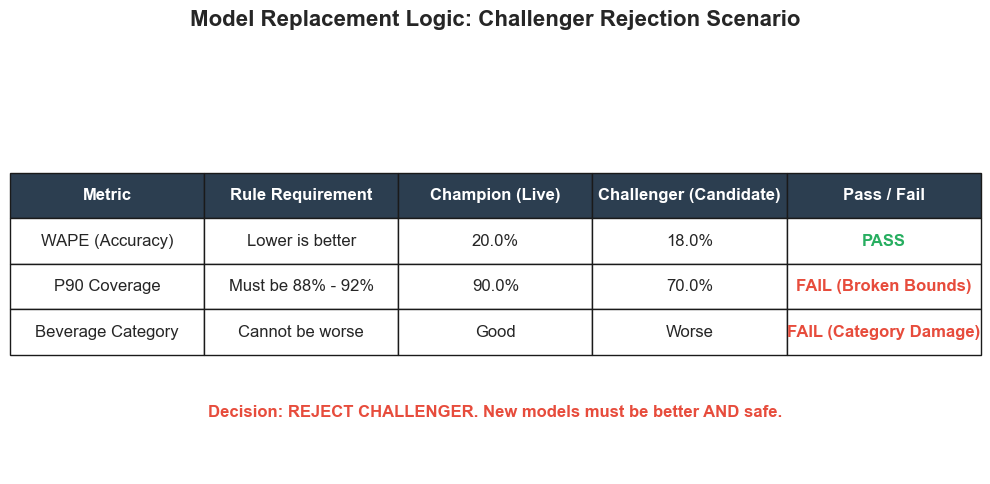

In [ ]:
import matplotlib.pyplot as plt

# 1. Set up the visual canvas
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('tight')
ax.axis('off')

# 2. Define the exact table data from the business logic
table_data = [
    ['Metric', 'Rule Requirement', 'Champion (Live)', 'Challenger (Candidate)', 'Pass / Fail'],
    ['WAPE (Accuracy)', 'Lower is better', '20.0%', '18.0%', 'PASS'],
    ['P90 Coverage', 'Must be 88% - 92%', '90.0%', '70.0%', 'FAIL (Broken Bounds)'],
    ['Beverage Category', 'Cannot be worse', 'Good', 'Worse', 'FAIL (Category Damage)']
]

# 3. Create the table
table = ax.table(cellText=table_data, 
                 loc='center', 
                 cellLoc='center')

# 4. Format the table for a professional consulting look
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2.5)

# Styling the header row
for j in range(len(table_data[0])):
    cell = table[0, j]
    cell.set_text_props(weight='bold', color='white')
    cell.set_facecolor('#2C3E50') # Dark blue header

# Highlighting the Pass/Fail column
for i in range(1, len(table_data)):
    status_cell = table[i, 4]
    status_text = status_cell.get_text().get_text()
    if 'FAIL' in status_text:
        status_cell.set_text_props(weight='bold', color='#E74C3C') # Red for fail
    else:
        status_cell.set_text_props(weight='bold', color='#27AE60') # Green for pass

# 5. Add titles
plt.title('Model Replacement Logic: Challenger Rejection Scenario', fontsize=16, fontweight='bold', pad=20)
plt.figtext(0.5, 0.15, "Decision: REJECT CHALLENGER. New models must be better AND safe.", ha="center", fontsize=12, fontweight='bold', color='#E74C3C')

# 6. Save the high-res image
plt.tight_layout()
plt.savefig('mlops_decision_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [86]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-white')
fig, ax = plt.subplots(figsize=(9, 5))

models = ['Legacy (MovingAvg30)', 'AI Model (Custom_V1)']
wape = [28.89, 24.18]
coverage = [32.70, 90.69]

x = np.arange(len(models))
width = 0.35

ax.bar(x - width/2, wape, width, label='Volume Error (WAPE %)', color='#d62728')
ax.bar(x + width/2, coverage, width, label='Safety Coverage (P90 %)', color='#2ca02c')

ax.axhline(y=90, color='black', linestyle='--', alpha=0.5, label='90% Target')
ax.set_title('Performance Leap: Legacy vs. AI Model', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig('./vis_benchmark_comparison.png', dpi=300)
plt.close()

In [87]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))

tiers = ['Premium', 'High', 'Medium', 'Low']
wape_scores = [20.57, 22.93, 26.89, 32.75]

bars = ax.bar(tiers, wape_scores, color='#1f77b4', width=0.6)
bars[0].set_color('#2ca02c') # Highlight the best performance

ax.set_title('AI Volume Error (WAPE %) by Store Tier', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('WAPE % (Lower is Better)', fontsize=12)

# Add data labels
for rect in bars:
    height = rect.get_height()
    ax.annotate(f'{height}%', xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('./vis_segment_performance.png', dpi=300)
plt.close()

In [88]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

metrics = ['Standard Evaluation\n(Based on Sales)', 'Rigorous Evaluation\n(True Demand)']
wape = [24.18, 28.19]

bars = ax.bar(metrics, wape, color=['#7f7f7f', '#d62728'], width=0.5)

ax.set_title('The Impact of True Demand on Accuracy', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('WAPE %', fontsize=12)
ax.set_ylim(0, 35)

for rect in bars:
    height = rect.get_height()
    ax.annotate(f'{height}%', xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 5), textcoords="offset points", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('./vis_true_demand.png', dpi=300)
plt.close()

In [89]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

categories = ['Beverages', 'Snacks', 'Dairy & Eggs', 'Frozen Foods', 'Personal Care']
impact_scores = [290.49, 266.40, 235.39, 219.60, 198.23]

bars = ax.barh(categories[::-1], impact_scores[::-1], color='#ff7f0e')
bars[-1].set_color('#d62728') # Highlight the highest impact

ax.set_title('Top 5 Categories by Financial Impact Score', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Impact Score (Error % × Volume Share)', fontsize=12)

plt.tight_layout()
plt.savefig('./vis_impact_prioritization.png', dpi=300)
plt.close()

In [90]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

policies = ['Old Policy\n(Flat Averages)', 'New AI Policy\n(Dynamic Safety Stock)']
stockouts = [58273, 52192]

bars = ax.bar(policies, stockouts, color=['#7f7f7f', '#1f77b4'], width=0.5)

ax.set_title('Black Friday Stockout Events by Policy', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Total Stockout Events', fontsize=12)
ax.set_ylim(0, 70000)

for rect in bars:
    height = rect.get_height()
    ax.annotate(f'{height:,}', xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 5), textcoords="offset points", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('./vis_policy_backtest.png', dpi=300)
plt.close()